# 04 · Modelos de Series Temporales — Calidad del aire en Barcelona

## Predicción temporal de NO₂, PM10 y PM2.5 mediante modelos estadísticos

Este notebook desarrolla la última etapa del bloque de modelización temporal del proyecto **Breathe Barcelona**, incorporando técnicas específicas de análisis y predicción de series temporales como complemento a los modelos de *Machine Learning* desarrollados previamente.

El análisis se centra en tres contaminantes de especial interés urbano:

- **NO₂**
- **PM10**
- **PM2.5**

La metodología se estructura en las siguientes etapas:

1. construcción y auditoría de las series temporales diarias;
2. análisis exploratorio de tendencia, estacionalidad y autocorrelación;
3. evaluación de estacionariedad;
4. construcción de modelos de referencia (*Naive* y *Seasonal Naive*);
5. modelización mediante **SARIMA**;
6. incorporación de variables explicativas mediante **SARIMAX**;
7. validación temporal sobre un periodo no utilizado durante el ajuste;
8. comparación mediante métricas homogéneas de regresión;
9. análisis de resultados y conclusiones.

La validación mantiene un enfoque estrictamente temporal, evitando la mezcla aleatoria de observaciones y preservando el orden cronológico de los datos.

> **Objetivo:** evaluar hasta qué punto la dinámica histórica de la contaminación y la incorporación de variables exógenas permiten anticipar la concentración diaria de los principales contaminantes atmosféricos de Barcelona.

## 0 · Configuración del entorno

Se importan las librerías necesarias para el tratamiento de datos, visualización, evaluación y modelización de series temporales.

Se definen asimismo los tres contaminantes objeto de estudio —**NO₂, PM10 y PM2.5**— y una semilla global para garantizar la reproducibilidad de aquellos procedimientos que puedan incorporar componentes aleatorios.

In [ ]:
# ============================================================
# 0. CONFIGURACIÓN DEL ENTORNO
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import (
    adfuller,
    acf,
    pacf
)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox


# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

SEED = 42

CONTAMINANTES = [
    "NO2",
    "PM10",
    "PM2.5"
]

print("=" * 80)
print("04 · MODELOS DE SERIES TEMPORALES")
print("=" * 80)

print("\nContaminantes analizados:")
for contaminante in CONTAMINANTES:
    print(f"  • {contaminante}")

print("\n✓ Entorno configurado correctamente.")

04 · MODELOS DE SERIES TEMPORALES

Contaminantes analizados:
  • NO2
  • PM10
  • PM2.5

✓ Entorno configurado correctamente.


### Resultado · Configuración del entorno

El entorno de trabajo se ha configurado correctamente y se han cargado las librerías necesarias para las distintas etapas del análisis.

Se establecen como variables objetivo las concentraciones diarias de:

- **NO₂**
- **PM10**
- **PM2.5**

A partir de este punto se utilizará una metodología común para los tres contaminantes, permitiendo comparar de forma homogénea el comportamiento de los modelos de referencia, SARIMA y SARIMAX.

La evaluación se realizará mediante métricas de regresión —**MAE, RMSE y R²**— sobre un periodo temporal reservado para validación, manteniendo en todo momento el orden cronológico de las observaciones.

## 1 · Carga del dataset maestro

Se parte del **dataset maestro temporal** generado en las etapas previas del proyecto, evitando repetir los procesos de extracción, limpieza e integración ya desarrollados.

Este conjunto constituye la base analítica común del bloque temporal e integra las observaciones de calidad del aire con las distintas fuentes explicativas disponibles.

En esta primera etapa se realizará una auditoría básica destinada a comprobar:

- dimensiones del conjunto;
- cobertura temporal;
- contaminantes disponibles;
- estaciones de calidad del aire representadas;
- estructura y variables disponibles.

Esta comprobación permitirá definir posteriormente las series diarias de **NO₂, PM10 y PM2.5** y seleccionar las variables candidatas para la modelización SARIMAX.

In [ ]:
# ============================================================
# 1. CARGA DEL DATASET MAESTRO
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)


# ------------------------------------------------------------
# Rutas
# ------------------------------------------------------------

RUTA_BASE = Path(
    "/content/drive/MyDrive/TFM/"
    "11_Machine_Learning_Temporal"
)

RUTA_MAESTRO = (
    RUTA_BASE
    / "INTEGRACION"
    / "06_maestro_contaminacion_meteorologia_trafico_ruido_vuelos_puerto.csv"
)


if not RUTA_MAESTRO.exists():
    raise FileNotFoundError(
        "No se encuentra el dataset maestro:\n"
        f"{RUTA_MAESTRO}"
    )


# ------------------------------------------------------------
# Carga
# ------------------------------------------------------------

df_maestro = pd.read_csv(
    RUTA_MAESTRO,
    low_memory=False
)

df_maestro["fecha"] = pd.to_datetime(
    df_maestro["fecha"],
    errors="coerce"
)


# ------------------------------------------------------------
# Auditoría general
# ------------------------------------------------------------

print("=" * 80)
print("DATASET MAESTRO · AUDITORÍA INICIAL")
print("=" * 80)

print(
    f"\nDimensiones       : "
    f"{df_maestro.shape[0]:,} filas × "
    f"{df_maestro.shape[1]} columnas"
)

print(
    f"Periodo           : "
    f"{df_maestro['fecha'].min().date()} "
    f"→ {df_maestro['fecha'].max().date()}"
)

print(
    f"Fechas únicas     : "
    f"{df_maestro['fecha'].nunique():,}"
)

print(
    f"Duplicados totales: "
    f"{df_maestro.duplicated().sum():,}"
)


# ------------------------------------------------------------
# Contaminantes
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CONTAMINANTES")
print("-" * 80)

if "contaminant" in df_maestro.columns:

    print(
        df_maestro["contaminant"]
        .value_counts(dropna=False)
        .to_string()
    )

else:
    print("⚠ No existe la columna 'contaminant'.")


# ------------------------------------------------------------
# Estaciones
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("ESTACIONES")
print("-" * 80)

if "estacion_fisica" in df_maestro.columns:

    estaciones = (
        df_maestro["estacion_fisica"]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
    )

    print(f"Número de estaciones: {len(estaciones)}")

    for estacion in estaciones:
        print(f"  • {estacion}")

else:
    print("⚠ No existe la columna 'estacion_fisica'.")


# ------------------------------------------------------------
# Variables disponibles
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("VARIABLES DISPONIBLES")
print("-" * 80)

for i, columna in enumerate(
    df_maestro.columns,
    start=1
):
    print(f"{i:02d}. {columna}")

Mounted at /content/drive
DATASET MAESTRO · AUDITORÍA INICIAL

Dimensiones       : 43,642 filas × 73 columnas
Periodo           : 2018-06-12 → 2024-12-31
Fechas únicas     : 2,249
Duplicados totales: 0

--------------------------------------------------------------------------------
CONTAMINANTES
--------------------------------------------------------------------------------
contaminant
NO2      17188
O3       12766
PM10     11954
PM2.5     1734

--------------------------------------------------------------------------------
ESTACIONES
--------------------------------------------------------------------------------
Número de estaciones: 10
  • Ciutadella
  • Eixample
  • Gràcia
  • Observ Fabra
  • Palau Reial
  • Poblenou
  • Sants_4
  • Sants_42
  • Sants_hist
  • Vall Hebron

--------------------------------------------------------------------------------
VARIABLES DISPONIBLES
--------------------------------------------------------------------------------
01. fecha
02. codi_estac

### Resultado · Auditoría del dataset maestro

El dataset maestro contiene **43.642 observaciones y 73 variables**, sin registros completamente duplicados, y presenta una cobertura temporal comprendida entre el **12 de junio de 2018 y el 31 de diciembre de 2024**.

La estructura mantiene una granularidad basada en **fecha × estación × contaminante**, incorporando tanto la concentración observada (`valor`) como información meteorológica, tráfico rodado, ruido ambiental, actividad aérea y actividad portuaria.

La disponibilidad de observaciones difiere notablemente entre contaminantes:

| Contaminante | Observaciones |
|---|---:|
| NO₂ | 17.188 |
| PM10 | 11.954 |
| PM2.5 | 1.734 |
| O₃ | 12.766 |

Para este análisis se seleccionan **NO₂, PM10 y PM2.5**. La menor disponibilidad de PM2.5 deberá tenerse en cuenta durante la construcción y evaluación de su serie temporal, evitando asumir una cobertura equivalente a la de NO₂ o PM10.

El dataset incorpora **73 variables**, incluyendo:

- variables de identificación, localización y tipología de estación;
- meteorología: temperatura, humedad, presión, precipitación, radiación solar y viento;
- tráfico rodado mediante diferentes radios e indicadores espaciales;
- contaminación acústica;
- actividad aérea;
- actividad portuaria.

Esta estructura proporciona una base adecuada tanto para la modelización **SARIMA**, basada exclusivamente en la dinámica temporal del contaminante, como para **SARIMAX**, donde podrá evaluarse la aportación de un conjunto reducido de variables exógenas.

> **Decisión metodológica:** antes de ajustar los modelos se construirá una serie diaria representativa para cada contaminante y se auditará explícitamente su continuidad y cobertura. Esta comprobación resulta especialmente relevante para PM2.5 debido a su menor número de observaciones.

## 2 · Construcción y cobertura de las series temporales

El dataset maestro presenta múltiples observaciones por fecha debido a la existencia de diferentes estaciones de monitorización. Antes de construir una serie temporal representativa para cada contaminante es necesario evaluar su **cobertura temporal y espacial**.

Este análisis previo permite evitar que cambios en el número o en la identidad de las estaciones disponibles introduzcan variaciones artificiales en las series agregadas.

Se analiza para **NO₂, PM10 y PM2.5**:

- número de observaciones por año;
- número de estaciones disponibles;
- periodo efectivo de cobertura;
- número de días con observaciones;
- número de estaciones que contribuyen diariamente a la serie.

Esta auditoría permitirá definir una estrategia de agregación diaria consistente y valorar específicamente las limitaciones de cobertura de **PM2.5**, cuya disponibilidad es inferior a la de los otros contaminantes.

In [ ]:
# ============================================================
# 2. CONSTRUCCIÓN Y COBERTURA DE LAS SERIES TEMPORALES
# ============================================================

df_ts = (
    df_maestro[
        df_maestro["contaminant"].isin(CONTAMINANTES)
    ]
    .copy()
)

df_ts["anio"] = df_ts["fecha"].dt.year


# ------------------------------------------------------------
# 2.1 Observaciones por contaminante y año
# ------------------------------------------------------------

obs_anuales = pd.crosstab(
    df_ts["anio"],
    df_ts["contaminant"]
).reindex(
    columns=CONTAMINANTES,
    fill_value=0
)

print("=" * 80)
print("OBSERVACIONES POR CONTAMINANTE Y AÑO")
print("=" * 80)
print(obs_anuales.to_string())


# ------------------------------------------------------------
# 2.2 Estaciones por contaminante y año
# ------------------------------------------------------------

estaciones_anuales = (
    df_ts
    .groupby(["anio", "contaminant"])["estacion_fisica"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=CONTAMINANTES, fill_value=0)
)

print("\n" + "=" * 80)
print("ESTACIONES POR CONTAMINANTE Y AÑO")
print("=" * 80)
print(estaciones_anuales.to_string())


# ------------------------------------------------------------
# 2.3 Estaciones disponibles por contaminante
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ESTACIONES DISPONIBLES POR CONTAMINANTE")
print("=" * 80)

for contaminante in CONTAMINANTES:

    estaciones = sorted(
        df_ts.loc[
            df_ts["contaminant"] == contaminante,
            "estacion_fisica"
        ]
        .dropna()
        .astype(str)
        .unique()
    )

    print(f"\n{contaminante} ({len(estaciones)} etiquetas):")

    for estacion in estaciones:
        print(f"  • {estacion}")


# ------------------------------------------------------------
# 2.4 Cobertura temporal global
# ------------------------------------------------------------

cobertura = (
    df_ts
    .groupby("contaminant")
    .agg(
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max"),
        dias_observados=("fecha", "nunique")
    )
    .reindex(CONTAMINANTES)
)

cobertura["dias_periodo"] = (
    cobertura["fecha_fin"] -
    cobertura["fecha_inicio"]
).dt.days + 1

cobertura["cobertura_pct"] = (
    cobertura["dias_observados"] /
    cobertura["dias_periodo"] * 100
)

print("\n" + "=" * 80)
print("COBERTURA TEMPORAL")
print("=" * 80)

print(
    cobertura.round(
        {"cobertura_pct": 2}
    ).to_string()
)


# ------------------------------------------------------------
# 2.5 Número de estaciones que contribuyen cada día
# ------------------------------------------------------------

estaciones_dia = (
    df_ts
    .groupby(["fecha", "contaminant"])["estacion_fisica"]
    .nunique()
    .rename("n_estaciones")
    .reset_index()
)

resumen_estaciones_dia = (
    estaciones_dia
    .groupby("contaminant")["n_estaciones"]
    .agg(["min", "median", "mean", "max"])
    .reindex(CONTAMINANTES)
)

print("\n" + "=" * 80)
print("ESTACIONES QUE CONTRIBUYEN DIARIAMENTE")
print("=" * 80)

print(
    resumen_estaciones_dia
    .round(2)
    .to_string()
)


# ------------------------------------------------------------
# 2.6 Días disponibles por contaminante y año
# ------------------------------------------------------------

dias_anuales = (
    df_ts
    .groupby(["anio", "contaminant"])["fecha"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=CONTAMINANTES, fill_value=0)
)

print("\n" + "=" * 80)
print("DÍAS CON OBSERVACIÓN POR AÑO")
print("=" * 80)
print(dias_anuales.to_string())

OBSERVACIONES POR CONTAMINANTE Y AÑO
contaminant   NO2  PM10  PM2.5
anio                          
2018         1184   784      0
2019         1787  1255      0
2020         2758  2044      0
2021         2842  2055     45
2022         2886  2068    339
2023         2867  2000    611
2024         2864  1748    739

ESTACIONES POR CONTAMINANTE Y AÑO
contaminant  NO2  PM10  PM2.5
anio                         
2018           8     6      0
2019          10     7      0
2020           8     6      0
2021           8     6      1
2022           8     6      1
2023           8     6      2
2024           8     6      3

ESTACIONES DISPONIBLES POR CONTAMINANTE

NO2 (10 etiquetas):
  • Ciutadella
  • Eixample
  • Gràcia
  • Observ Fabra
  • Palau Reial
  • Poblenou
  • Sants_4
  • Sants_42
  • Sants_hist
  • Vall Hebron

PM10 (7 etiquetas):
  • Eixample
  • Gràcia
  • Observ Fabra
  • Palau Reial
  • Poblenou
  • Sants_4
  • Vall Hebron

PM2.5 (3 etiquetas):
  • Eixample
  • Palau Reial
  • Va

### Resultado · Cobertura temporal y espacial de los contaminantes

La auditoría evidencia diferencias relevantes en la disponibilidad de los tres contaminantes analizados, tanto en extensión temporal como en número de estaciones de medida.

#### NO₂

El **NO₂ presenta la cobertura más amplia**, con **17.188 observaciones** distribuidas a lo largo del periodo 2018–2024. La serie dispone de datos para **2.248 días**, equivalentes al **93,86 %** del periodo potencial comprendido entre junio de 2018 y diciembre de 2024.

La cobertura espacial es igualmente elevada: en los años completos recientes contribuyen hasta **8 estaciones por día**, con una mediana diaria de **8 estaciones**. Las diez denominaciones detectadas en el conjunto completo no representan diez localizaciones simultáneas, ya que incluyen distintas identificaciones históricas asociadas a la estación de Sants.

#### PM10

El **PM10** presenta también una cobertura temporal elevada, con datos en **2.248 días (93,86 %)** del periodo analizado. Su cobertura espacial es algo inferior a la del NO₂: participan hasta **6 estaciones simultáneamente**, con una mediana de **6 estaciones por día**.

Tanto NO₂ como PM10 alcanzan una cobertura diaria prácticamente completa desde 2022, lo que proporciona series suficientemente extensas para estudiar su dinámica temporal y realizar una validación independiente sobre 2024.

#### PM2.5

La situación es diferente para **PM2.5**. Su monitorización comienza el **10 de noviembre de 2021**, por lo que no existen observaciones para 2018–2020 y únicamente se dispone de 45 días en 2021.

A partir de 2022 la cobertura temporal es elevada —**1.103 días observados sobre 1.148 posibles (96,08 %)** desde el inicio de la serie—, pero la cobertura espacial aumenta progresivamente: una estación en 2021–2022, dos en 2023 y tres en 2024. En consecuencia, la composición espacial de la serie de PM2.5 no es constante a lo largo de todo el periodo.

| Contaminante | Inicio | Días observados | Cobertura | Mediana estaciones/día | Máximo |
|---|---|---:|---:|---:|---:|
| NO₂ | 12/06/2018 | 2.248 | 93,86 % | 8 | 8 |
| PM10 | 12/06/2018 | 2.248 | 93,86 % | 6 | 6 |
| PM2.5 | 10/11/2021 | 1.103 | 96,08 % | 2 | 3 |

#### Implicación metodológica

Los resultados muestran que **no resulta adecuado imponer exactamente la misma ventana histórica a los tres contaminantes**.

Para NO₂ y PM10 puede utilizarse una serie temporal extensa, mientras que PM2.5 deberá modelizarse únicamente durante el periodo en el que existe información suficiente. Además, antes de efectuar la agregación diaria se controlará la composición de las estaciones para evitar interpretar como dinámica temporal propia del contaminante cambios derivados exclusivamente de la incorporación progresiva de nuevos puntos de medida.

Esta estrategia permite mantener los tres contaminantes en el análisis respetando la disponibilidad real de cada serie y evitando imputaciones retrospectivas de periodos para los que no existen observaciones.

## 3 · Armonización de estaciones y preparación de las series diarias

La auditoría anterior muestra que la cobertura espacial de los contaminantes no es completamente constante durante el periodo de estudio. Además, algunas estaciones presentan diferentes identificadores históricos aunque correspondan a una misma localización física.

Para evitar que estos cambios de denominación afecten a la construcción de las series, se utiliza la variable `estacion_geo`, definida durante la fase de integración para representar de forma homogénea las localizaciones de monitorización.

Antes de realizar la agregación diaria se comprueba:

- la correspondencia entre `estacion_fisica` y `estacion_geo`;
- el número efectivo de localizaciones por contaminante y año;
- la disponibilidad temporal de cada localización;
- la estabilidad de la red de medida.

Esta comprobación permitirá seleccionar una estrategia de agregación que represente la evolución temporal de la contaminación minimizando el efecto de cambios en la composición de la red de estaciones.

In [ ]:
# ============================================================
# 3. ARMONIZACIÓN Y ESTABILIDAD DE LAS ESTACIONES
# ============================================================

# ------------------------------------------------------------
# 3.1 Correspondencia entre estación histórica y geográfica
# ------------------------------------------------------------

correspondencia_estaciones = (
    df_ts[
        ["estacion_fisica", "estacion_geo"]
    ]
    .drop_duplicates()
    .sort_values(
        ["estacion_geo", "estacion_fisica"]
    )
)

print("=" * 80)
print("CORRESPONDENCIA ENTRE ESTACION_FISICA Y ESTACION_GEO")
print("=" * 80)

print(
    correspondencia_estaciones
    .to_string(index=False)
)


# ------------------------------------------------------------
# 3.2 Número de localizaciones geográficas por año
# ------------------------------------------------------------

estaciones_geo_anuales = (
    df_ts
    .groupby(
        ["anio", "contaminant"]
    )["estacion_geo"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        columns=CONTAMINANTES,
        fill_value=0
    )
)

print("\n" + "=" * 80)
print("LOCALIZACIONES GEOGRÁFICAS POR CONTAMINANTE Y AÑO")
print("=" * 80)

print(
    estaciones_geo_anuales
    .to_string()
)


# ------------------------------------------------------------
# 3.3 Cobertura de cada estación geográfica
# ------------------------------------------------------------

cobertura_estacion = (
    df_ts
    .groupby(
        ["contaminant", "estacion_geo"]
    )
    .agg(
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max"),
        dias=("fecha", "nunique"),
        observaciones=("valor", "count")
    )
    .reset_index()
    .sort_values(
        ["contaminant", "estacion_geo"]
    )
)

print("\n" + "=" * 80)
print("COBERTURA POR ESTACIÓN GEOGRÁFICA")
print("=" * 80)

for contaminante in CONTAMINANTES:

    print(
        f"\n--- {contaminante} ---"
    )

    tabla = cobertura_estacion[
        cobertura_estacion["contaminant"]
        == contaminante
    ].copy()

    print(
        tabla.to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# 3.4 Estaciones disponibles por año y contaminante
# ------------------------------------------------------------

detalle_anual = (
    df_ts
    .groupby(
        ["anio", "contaminant"]
    )["estacion_geo"]
    .apply(
        lambda x: ", ".join(
            sorted(
                x.dropna()
                .astype(str)
                .unique()
            )
        )
    )
    .reset_index(
        name="estaciones"
    )
)

print("\n" + "=" * 80)
print("COMPOSICIÓN DE LA RED POR AÑO")
print("=" * 80)

for contaminante in CONTAMINANTES:

    print(
        f"\n--- {contaminante} ---"
    )

    print(
        detalle_anual[
            detalle_anual["contaminant"]
            == contaminante
        ][
            ["anio", "estaciones"]
        ]
        .to_string(index=False)
    )

CORRESPONDENCIA ENTRE ESTACION_FISICA Y ESTACION_GEO
estacion_fisica      estacion_geo
     Ciutadella        Ciutadella
       Eixample          Eixample
         Gràcia            Gràcia
   Observ Fabra Observatori Fabra
    Palau Reial       Palau Reial
       Poblenou          Poblenou
        Sants_4             Sants
       Sants_42             Sants
     Sants_hist             Sants
    Vall Hebron     Vall d'Hebron

LOCALIZACIONES GEOGRÁFICAS POR CONTAMINANTE Y AÑO
contaminant  NO2  PM10  PM2.5
anio                         
2018           8     6      0
2019           8     7      0
2020           7     6      0
2021           7     6      1
2022           7     6      1
2023           7     6      2
2024           7     6      3

COBERTURA POR ESTACIÓN GEOGRÁFICA

--- NO2 ---
contaminant      estacion_geo fecha_inicio  fecha_fin  dias  observaciones
        NO2        Ciutadella   2018-06-12 2024-12-31  2219           2219
        NO2          Eixample   2018-06-15 2024-12-31 

### Resultado · Armonización de estaciones y estrategia de agregación

La utilización de `estacion_geo` permite armonizar correctamente las diferentes denominaciones históricas de las estaciones. En particular, `Sants_4`, `Sants_42` y `Sants_hist` quedan asociadas a una única localización geográfica, **Sants**, mientras que se normalizan también las denominaciones de Vall d'Hebron y Observatori Fabra.

La auditoría muestra, no obstante, diferencias entre los contaminantes.

#### NO₂

La red presenta una elevada estabilidad espacial. Desde 2020 se mantienen **7 localizaciones geográficas**, mientras que Observatori Fabra únicamente aporta información durante una parte de 2018–2019.

Se detecta además que Sants acumula **4.183 observaciones en 2.201 días**, como consecuencia del solapamiento temporal de diferentes identificadores históricos. Para evitar que esta localización tenga un peso superior al resto, las observaciones se consolidarán primero a nivel de **fecha × estación geográfica** antes de obtener el indicador agregado de ciudad.

#### PM10

La red presenta una estructura igualmente estable a partir de 2020, con **6 localizaciones geográficas**. Observatori Fabra únicamente aparece al comienzo del periodo, mientras que Sants se incorpora en 2019.

La agregación seguirá el mismo procedimiento que para NO₂: primero se obtendrá un único valor diario por localización geográfica y posteriormente se calculará el indicador diario agregado.

#### PM2.5

PM2.5 presenta una estructura diferente. **Palau Reial** constituye la única estación con una serie suficientemente extensa y continua, con **1.070 días de observación entre noviembre de 2021 y diciembre de 2024**. Eixample comienza a proporcionar datos en abril de 2023 y Vall d'Hebron únicamente en noviembre de 2024.

Construir una media diaria de ciudad utilizando todas las estaciones disponibles introduciría por tanto cambios en la composición espacial de la serie en 2023 y 2024. Para evitar este efecto, la modelización temporal de **PM2.5 utilizará Palau Reial como serie de referencia**, manteniendo una localización constante durante todo el periodo disponible.

#### Estrategia adoptada

Se establecen dos estrategias de construcción:

- **NO₂ y PM10:** serie diaria agregada de ciudad, consolidando previamente las observaciones por `fecha × estacion_geo` para que cada localización tenga el mismo peso.
- **PM2.5:** serie diaria de referencia correspondiente a **Palau Reial**, evitando mezclar cambios temporales del contaminante con la incorporación progresiva de nuevas estaciones.

Esta decisión prioriza la **consistencia temporal de las series** frente a la utilización indiscriminada de todas las observaciones disponibles.

## 4 · Construcción de las series diarias de modelización

A partir de la auditoría de cobertura se construyen las tres series temporales que se utilizarán en los modelos.

Para **NO₂ y PM10**, las observaciones se consolidan primero a nivel de `fecha × estacion_geo` y posteriormente se calcula la concentración media diaria entre las localizaciones disponibles. Este procedimiento evita otorgar un peso adicional a estaciones que presentan diferentes identificadores históricos.

Para **PM2.5** se utiliza exclusivamente la estación de **Palau Reial**, que proporciona la serie más extensa y estable durante el periodo disponible.

Finalmente, las series se reindexan a frecuencia diaria para identificar explícitamente los días sin observación. En esta etapa **no se realiza todavía ninguna imputación**, con el objetivo de cuantificar previamente los huecos existentes y su distribución temporal.

In [ ]:
# ============================================================
# 4. CONSTRUCCIÓN DE LAS SERIES DIARIAS
# ============================================================

series = {}

# ------------------------------------------------------------
# 4.1 NO2 y PM10
#     Paso 1: un valor por fecha × estación geográfica
#     Paso 2: media diaria entre estaciones
# ------------------------------------------------------------

for contaminante in ["NO2", "PM10"]:

    df_c = (
        df_ts[
            df_ts["contaminant"] == contaminante
        ][
            ["fecha", "estacion_geo", "valor"]
        ]
        .dropna(subset=["fecha", "estacion_geo", "valor"])
        .copy()
    )

    # Consolidación de posibles identificadores históricos
    por_estacion = (
        df_c
        .groupby(
            ["fecha", "estacion_geo"],
            as_index=False
        )["valor"]
        .mean()
    )

    # Media diaria entre localizaciones
    serie = (
        por_estacion
        .groupby("fecha")["valor"]
        .mean()
        .sort_index()
    )

    # Frecuencia diaria explícita
    indice_diario = pd.date_range(
        serie.index.min(),
        serie.index.max(),
        freq="D"
    )

    series[contaminante] = (
        serie
        .reindex(indice_diario)
        .rename(contaminante)
    )


# ------------------------------------------------------------
# 4.2 PM2.5
#     Serie estable de Palau Reial
# ------------------------------------------------------------

serie_pm25 = (
    df_ts[
        (df_ts["contaminant"] == "PM2.5")
        & (df_ts["estacion_geo"] == "Palau Reial")
    ]
    .groupby("fecha")["valor"]
    .mean()
    .sort_index()
)

indice_pm25 = pd.date_range(
    serie_pm25.index.min(),
    serie_pm25.index.max(),
    freq="D"
)

series["PM2.5"] = (
    serie_pm25
    .reindex(indice_pm25)
    .rename("PM2.5")
)


# ------------------------------------------------------------
# 4.3 Auditoría de las series resultantes
# ------------------------------------------------------------

resumen_series = []

for contaminante, serie in series.items():

    n_total = len(serie)
    n_validos = serie.notna().sum()
    n_missing = serie.isna().sum()

    resumen_series.append({
        "contaminante": contaminante,
        "inicio": serie.index.min().date(),
        "fin": serie.index.max().date(),
        "dias_totales": n_total,
        "dias_validos": n_validos,
        "dias_missing": n_missing,
        "missing_pct": 100 * n_missing / n_total,
        "media": serie.mean(),
        "mediana": serie.median(),
        "std": serie.std(),
        "min": serie.min(),
        "max": serie.max()
    })

resumen_series = pd.DataFrame(
    resumen_series
).set_index("contaminante")


print("=" * 80)
print("SERIES DIARIAS CONSTRUIDAS")
print("=" * 80)

print(
    resumen_series.round(2).to_string()
)


# ------------------------------------------------------------
# 4.4 Huecos consecutivos
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LONGITUD MÁXIMA DE HUECOS CONSECUTIVOS")
print("=" * 80)

for contaminante, serie in series.items():

    missing = serie.isna()

    grupos = (
        missing.ne(missing.shift())
        .cumsum()
    )

    huecos = (
        missing[missing]
        .groupby(grupos[missing])
        .size()
    )

    max_hueco = (
        int(huecos.max())
        if len(huecos) > 0
        else 0
    )

    print(
        f"{contaminante:<6}: "
        f"{max_hueco} días consecutivos"
    )

SERIES DIARIAS CONSTRUIDAS
                  inicio         fin  dias_totales  dias_validos  dias_missing  missing_pct  media  mediana    std   min     max
contaminante                                                                                                                    
NO2           2018-06-12  2024-12-31          2395          2248           147         6.14  25.31    23.83  10.52  5.00   80.42
PM10          2018-06-12  2024-12-31          2395          2248           147         6.14  21.55    20.35   9.19  4.89  115.08
PM2.5         2021-11-10  2024-12-31          1148          1070            78         6.79   9.49     8.17   5.75  1.00   46.17

LONGITUD MÁXIMA DE HUECOS CONSECUTIVOS
NO2   : 61 días consecutivos
PM10  : 60 días consecutivos
PM2.5 : 35 días consecutivos


### Resultado · Series diarias de modelización

La construcción de las series proporciona tres señales diarias diferenciadas tanto por extensión temporal como por nivel de concentración y disponibilidad de datos.

| Contaminante | Periodo | Días válidos | Días sin dato | Ausencia | Media | Mediana |
|---|---|---:|---:|---:|---:|---:|
| NO₂ | 12/06/2018–31/12/2024 | 2.248 | 147 | 6,14 % | 25,31 | 23,83 |
| PM10 | 12/06/2018–31/12/2024 | 2.248 | 147 | 6,14 % | 21,55 | 20,35 |
| PM2.5 | 10/11/2021–31/12/2024 | 1.070 | 78 | 6,79 % | 9,49 | 8,17 |

NO₂ y PM10 presentan una extensión temporal idéntica y un porcentaje reducido de días sin observación. PM2.5 dispone de una serie más corta, coherente con su incorporación posterior a la red de monitorización, aunque mantiene una cobertura próxima al 93 % durante su periodo efectivo.

Las concentraciones medias obtenidas son de **25,31 para NO₂**, **21,55 para PM10** y **9,49 para PM2.5**. En los tres casos la media supera a la mediana, especialmente en PM10 y PM2.5, anticipando la presencia de episodios de concentración elevada que deberán observarse en el análisis exploratorio.

La auditoría de continuidad detecta, sin embargo, huecos máximos de **61 días para NO₂**, **60 días para PM10** y **35 días para PM2.5**. Aunque el porcentaje global de datos ausentes es reducido, estos valores muestran que las ausencias no corresponden exclusivamente a días aislados.

> **Decisión metodológica:** no se realizará una interpolación indiscriminada de toda la serie, ya que rellenar bloques prolongados podría generar artificialmente la dinámica temporal que posteriormente se pretende modelizar. El tratamiento de valores ausentes se limitará a garantizar series regulares para los modelos, preservando la separación entre información observada y valores reconstruidos.

## 5 · Diagnóstico de valores ausentes y definición de la ventana temporal

La existencia de periodos prolongados sin observación requiere analizar la distribución temporal de los valores ausentes antes de aplicar cualquier procedimiento de regularización.

Se estudia:

- el número de días ausentes por año;
- la longitud y localización de los principales bloques consecutivos sin observación;
- la disponibilidad específica durante 2024, periodo candidato para la evaluación final.

El objetivo es priorizar una **ventana temporal suficientemente continua** frente a la reconstrucción artificial de bloques extensos de datos.

Siempre que la cobertura lo permita, se mantendrá **2024 como periodo de test**, proporcionando una evaluación estrictamente temporal sobre el año más reciente y facilitando la coherencia con la estrategia de validación utilizada en el resto del bloque temporal.

In [ ]:
# ============================================================
# 5. DIAGNÓSTICO DE VALORES AUSENTES
# ============================================================

def obtener_bloques_missing(serie):
    """
    Identifica bloques consecutivos de valores ausentes.
    Devuelve fecha inicial, fecha final y duración.
    """

    mask = serie.isna()

    if not mask.any():
        return pd.DataFrame(
            columns=["inicio", "fin", "dias"]
        )

    grupos = mask.ne(mask.shift()).cumsum()

    bloques = []

    for _, tramo in serie[mask].groupby(
        grupos[mask]
    ):
        bloques.append({
            "inicio": tramo.index.min(),
            "fin": tramo.index.max(),
            "dias": len(tramo)
        })

    return (
        pd.DataFrame(bloques)
        .sort_values("dias", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 5.1 Missing por año
# ------------------------------------------------------------

print("=" * 80)
print("DÍAS SIN OBSERVACIÓN POR AÑO")
print("=" * 80)

for contaminante, serie in series.items():

    resumen_anual = pd.DataFrame({
        "valor": serie
    })

    resumen_anual["anio"] = (
        resumen_anual.index.year
    )

    tabla = (
        resumen_anual
        .groupby("anio")["valor"]
        .agg(
            dias_totales="size",
            dias_validos="count"
        )
    )

    tabla["dias_missing"] = (
        tabla["dias_totales"]
        - tabla["dias_validos"]
    )

    tabla["missing_pct"] = (
        100
        * tabla["dias_missing"]
        / tabla["dias_totales"]
    )

    print(f"\n--- {contaminante} ---")

    print(
        tabla.round(2).to_string()
    )


# ------------------------------------------------------------
# 5.2 Principales bloques consecutivos
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PRINCIPALES BLOQUES CONSECUTIVOS SIN OBSERVACIÓN")
print("=" * 80)

bloques_missing = {}

for contaminante, serie in series.items():

    bloques = obtener_bloques_missing(
        serie
    )

    bloques_missing[contaminante] = bloques

    print(f"\n--- {contaminante} ---")

    if bloques.empty:
        print("Sin valores ausentes.")

    else:
        print(
            bloques
            .head(10)
            .to_string(index=False)
        )


# ------------------------------------------------------------
# 5.3 Cobertura específica del año 2024
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COBERTURA DEL CANDIDATO A TEST · 2024")
print("=" * 80)

for contaminante, serie in series.items():

    serie_2024 = serie[
        serie.index.year == 2024
    ]

    n = len(serie_2024)
    validos = serie_2024.notna().sum()
    missing = serie_2024.isna().sum()

    print(
        f"{contaminante:<6} | "
        f"Total: {n:3d} | "
        f"Válidos: {validos:3d} | "
        f"Missing: {missing:3d} | "
        f"Cobertura: "
        f"{100 * validos / n:6.2f}%"
    )

DÍAS SIN OBSERVACIÓN POR AÑO

--- NO2 ---
      dias_totales  dias_validos  dias_missing  missing_pct
anio                                                       
2018           203           183            20         9.85
2019           365           255           110        30.14
2020           366           355            11         3.01
2021           365           359             6         1.64
2022           365           365             0         0.00
2023           365           365             0         0.00
2024           366           366             0         0.00

--- PM10 ---
      dias_totales  dias_validos  dias_missing  missing_pct
anio                                                       
2018           203           182            21        10.34
2019           365           256           109        29.86
2020           366           355            11         3.01
2021           365           359             6         1.64
2022           365           365            

### Resultado · Distribución temporal de los valores ausentes

El análisis muestra que los valores ausentes no se distribuyen uniformemente a lo largo del periodo, sino que se concentran en intervalos concretos.

#### NO₂ y PM10

Ambos contaminantes presentan un patrón prácticamente idéntico. La mayor discontinuidad se localiza en **2019**, año en el que aproximadamente el 30 % de los días carece de observación. Los principales bloques corresponden a:

- aproximadamente dos meses entre febrero y abril de 2019;
- el mes de octubre de 2019;
- un intervalo de 12 días durante julio de 2018.

A partir de 2020 la disponibilidad mejora sustancialmente: los valores ausentes representan únicamente el **3,01 % en 2020** y el **1,64 % en 2021**, mientras que **2022, 2023 y 2024 presentan cobertura diaria completa**.

Este patrón aconseja no reconstruir artificialmente los extensos huecos de 2019. Para la fase principal de modelización se priorizará el periodo de mayor continuidad temporal.

#### PM2.5

PM2.5 presenta una serie más corta y una estructura diferente. En 2022 falta el 7,12 % de los días y en 2023 únicamente el 2,74 %. En 2024 la cobertura alcanza el **90,44 %**, aunque existe un único bloque continuo de **35 días entre el 9 de mayo y el 12 de junio**.

Este intervalo no se interpolará de forma lineal como si correspondiera a observaciones reales, ya que su extensión podría alterar artificialmente la estructura temporal de la serie y las métricas de evaluación.

#### Definición del periodo de evaluación

El año **2024 se mantiene como periodo de evaluación final**, siguiendo una partición estrictamente cronológica y reservando el periodo más reciente para comprobar la capacidad predictiva fuera de muestra.

Para **NO₂ y PM10**, 2024 dispone de cobertura completa, por lo que constituye un conjunto de test especialmente adecuado.

Para **PM2.5**, la evaluación sobre 2024 se realizará exclusivamente sobre las fechas con observación real disponible, manteniendo identificado el intervalo sin mediciones y evitando que valores imputados sean utilizados para calcular las métricas finales.

> **Criterio general:** los valores reconstruidos que puedan ser necesarios para mantener la regularidad matemática de los modelos nunca se considerarán observaciones reales ni se utilizarán para evaluar su rendimiento.

## 6 · Análisis exploratorio de la evolución temporal

Antes de ajustar los modelos se examina la evolución de las concentraciones para identificar tendencias, episodios extremos y cambios de comportamiento a lo largo del periodo.

Para facilitar la interpretación se representan conjuntamente:

- la concentración diaria observada;
- una media móvil de **30 días**, que suaviza la variabilidad de corto plazo y permite visualizar la evolución subyacente;
- el periodo asociado a las principales restricciones de movilidad por COVID-19, utilizado como referencia contextual y no como evidencia causal.

Para **NO₂ y PM10** se centra el análisis de modelización en **2020–2024**, periodo con una cobertura sustancialmente más homogénea que 2018–2019. PM2.5 se analiza desde el inicio de su serie disponible.

Esta visualización constituye además un resultado directamente reutilizable en la síntesis gráfica del proyecto y en el dashboard final.

VENTANAS TEMPORALES DE MODELIZACIÓN
NO2    | 2020-01-01 → 2024-12-31 | 1810 observaciones |  17 missing
PM10   | 2020-01-01 → 2024-12-31 | 1810 observaciones |  17 missing
PM2.5  | 2021-11-10 → 2024-12-31 | 1070 observaciones |  78 missing


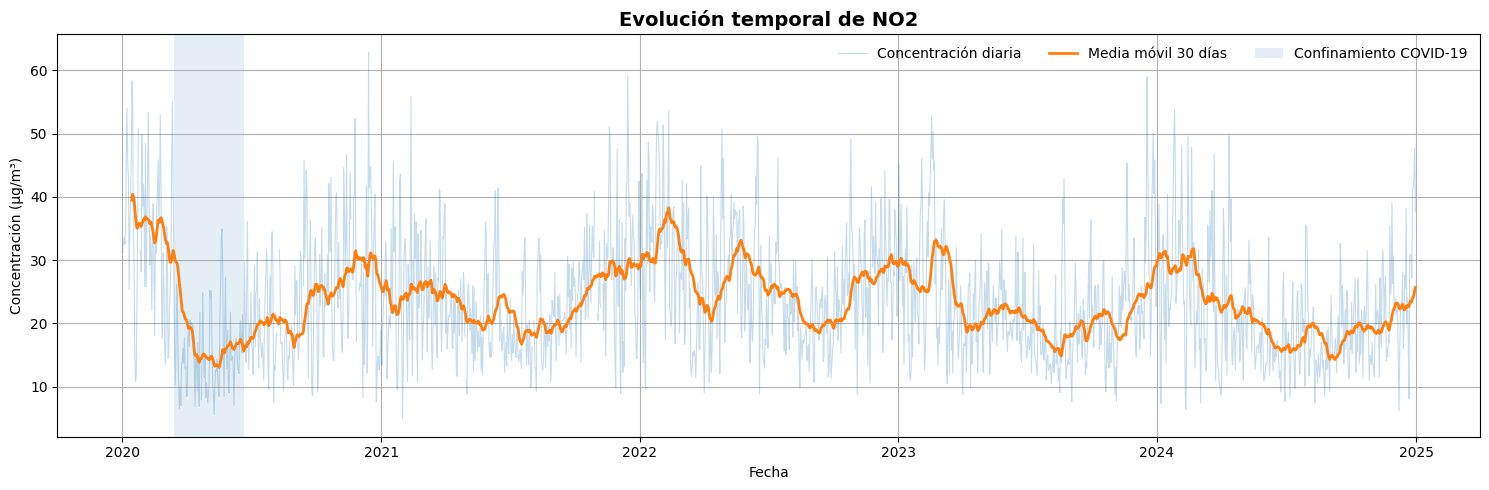

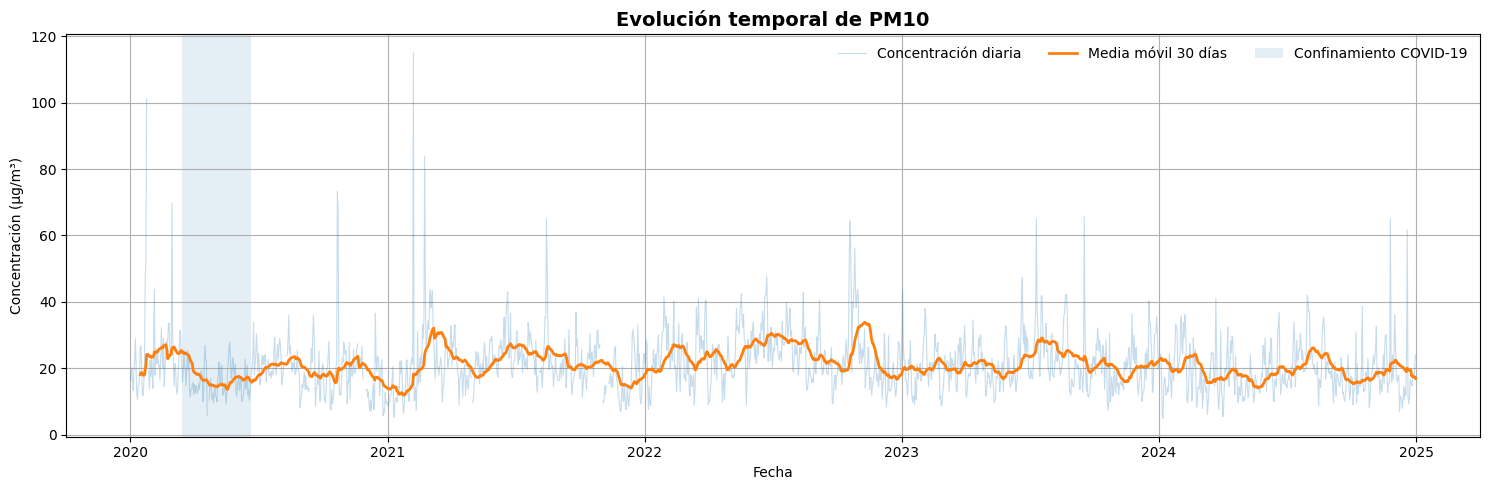

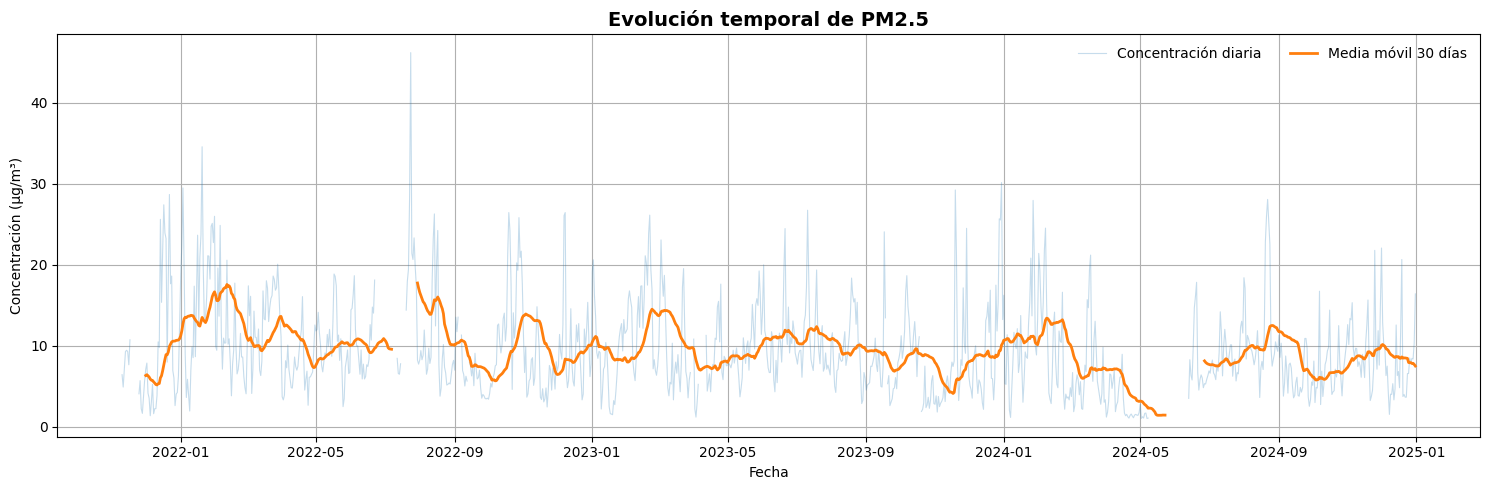

In [ ]:
# ============================================================
# 6. EVOLUCIÓN TEMPORAL DE LOS CONTAMINANTES
# ============================================================

# Ventanas principales de análisis
series_modelado = {
    "NO2": series["NO2"].loc["2020-01-01":"2024-12-31"].copy(),
    "PM10": series["PM10"].loc["2020-01-01":"2024-12-31"].copy(),
    "PM2.5": series["PM2.5"].copy()
}


# ------------------------------------------------------------
# Resumen de las ventanas seleccionadas
# ------------------------------------------------------------

print("=" * 80)
print("VENTANAS TEMPORALES DE MODELIZACIÓN")
print("=" * 80)

for contaminante, serie in series_modelado.items():

    print(
        f"{contaminante:<6} | "
        f"{serie.index.min().date()} → "
        f"{serie.index.max().date()} | "
        f"{serie.notna().sum():4d} observaciones | "
        f"{serie.isna().sum():3d} missing"
    )


# ------------------------------------------------------------
# Evolución diaria + media móvil de 30 días
# ------------------------------------------------------------

for contaminante, serie in series_modelado.items():

    media_movil = serie.rolling(
        window=30,
        min_periods=15
    ).mean()

    fig, ax = plt.subplots(
        figsize=(15, 5)
    )

    # Serie diaria
    ax.plot(
        serie.index,
        serie.values,
        alpha=0.25,
        linewidth=0.8,
        label="Concentración diaria"
    )

    # Tendencia suavizada
    ax.plot(
        media_movil.index,
        media_movil.values,
        linewidth=2,
        label="Media móvil 30 días"
    )

    # Referencia contextual COVID
    if serie.index.min() <= pd.Timestamp("2020-03-14"):

        ax.axvspan(
            pd.Timestamp("2020-03-14"),
            pd.Timestamp("2020-06-21"),
            alpha=0.12,
            label="Confinamiento COVID-19"
        )

    ax.set_title(
        f"Evolución temporal de {contaminante}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Fecha")
    ax.set_ylabel("Concentración (µg/m³)")

    ax.legend(
        frameon=False,
        ncol=3
    )

    plt.tight_layout()
    plt.show()

### Resultado · Evolución temporal de los contaminantes

La representación de las concentraciones diarias y de su media móvil de 30 días muestra una dinámica temporal diferenciada entre los tres contaminantes, así como una importante variabilidad de corto plazo.

#### NO₂

El NO₂ presenta la señal temporal más estructurada. Al comienzo de 2020 se observan concentraciones relativamente elevadas, seguidas de una **caída muy acusada coincidente temporalmente con el periodo de confinamiento por COVID-19**. Tras este episodio las concentraciones se recuperan progresivamente, aunque con oscilaciones interanuales relevantes.

La media móvil muestra además fluctuaciones recurrentes a lo largo de los distintos años, compatibles con la existencia de componentes estacionales. No se aprecia, sin embargo, un retorno permanente a los niveles observados al comienzo de 2020.

Esta evolución resulta coherente con la sensibilidad del NO₂ a cambios en la movilidad y actividad urbana observada en otros bloques del proyecto. La coincidencia temporal con el confinamiento se interpreta aquí de forma descriptiva y no como una estimación causal.

#### PM10

PM10 presenta una evolución menos marcada por el confinamiento que NO₂. La serie mantiene una concentración central relativamente estable, aunque aparecen **episodios puntuales de valores muy elevados**, claramente superiores al comportamiento habitual.

La media móvil revela oscilaciones temporales y determinados periodos de incremento, pero una tendencia de largo plazo menos pronunciada que en NO₂. La existencia de picos extremos indica además que las métricas basadas en errores cuadráticos podrán ser especialmente sensibles a determinados episodios.

#### PM2.5

La serie de PM2.5, disponible desde noviembre de 2021 para la estación de referencia de Palau Reial, muestra también variabilidad estacional y episodios puntuales de concentración elevada.

Durante 2022 se observan algunos de los máximos de la serie, mientras que 2023–2024 presentan oscilaciones generalmente dentro de un rango inferior. El intervalo sin datos comprendido entre mayo y junio de 2024 queda claramente identificado como una **ausencia de observaciones**, por lo que no se interpreta como una disminución real de la concentración.

#### Ventanas de modelización

Tras excluir el periodo de mayor discontinuidad de 2018–2019, las series de NO₂ y PM10 correspondientes a **2020–2024 contienen 1.810 observaciones válidas y únicamente 17 días ausentes**.

PM2.5 conserva su periodo disponible completo, con **1.070 observaciones válidas**, aunque presenta 78 días sin medición.

En conjunto, el análisis visual sugiere la presencia de **dependencia temporal, oscilaciones recurrentes y episodios extremos**, justificando el estudio posterior de estacionariedad y autocorrelación antes de especificar los modelos SARIMA.

## 7 · Estacionalidad mensual y semanal

La inspección visual sugiere la existencia de oscilaciones recurrentes en las concentraciones. Para caracterizar esta estructura se analizan dos escalas temporales relevantes:

- **estacionalidad mensual**, asociada a cambios meteorológicos y de actividad a lo largo del año;
- **estacionalidad semanal**, potencialmente relacionada con los ciclos de movilidad y actividad urbana.

El objetivo no es únicamente describir estos patrones, sino utilizarlos para orientar posteriormente la especificación de los modelos SARIMA.

En particular, la existencia de dependencia semanal respaldaría la utilización de un periodo estacional de **7 días**, computacionalmente adecuado para series diarias y directamente interpretable en términos de actividad urbana.

CONCENTRACIÓN MEDIA POR MES

--- NO2 ---
      mean  median  count
Ene  29.50   29.26    153
Feb  30.56   30.90    142
Mar  22.97   21.88    155
Abr  21.01   19.58    148
May  21.84   21.30    155
Jun  20.23   17.79    150
Jul  20.26   18.54    155
Ago  17.66   16.62    151
Sep  21.22   20.49    149
Oct  23.80   23.45    154
Nov  26.00   25.75    143
Dic  27.72   26.49    155

--- PM10 ---
      mean  median  count
Ene  19.52   18.29    153
Feb  24.23   22.99    142
Mar  21.55   20.49    155
Abr  18.70   18.17    148
May  19.88   18.78    155
Jun  23.42   22.32    150
Jul  24.89   24.00    155
Ago  22.86   20.81    151
Sep  19.22   18.49    149
Oct  22.33   20.35    154
Nov  19.75   18.96    143
Dic  17.78   16.17    155

--- PM2.5 ---
      mean  median  count
Ene  11.87    9.88     93
Feb  11.42   10.33     85
Mar  10.10    8.88     91
Abr   6.02    6.08     84
May   9.01    8.92     70
Jun  10.09    9.48     70
Jul  11.16    8.95     78
Ago  10.60    8.96     93
Sep   6.72    6.15  

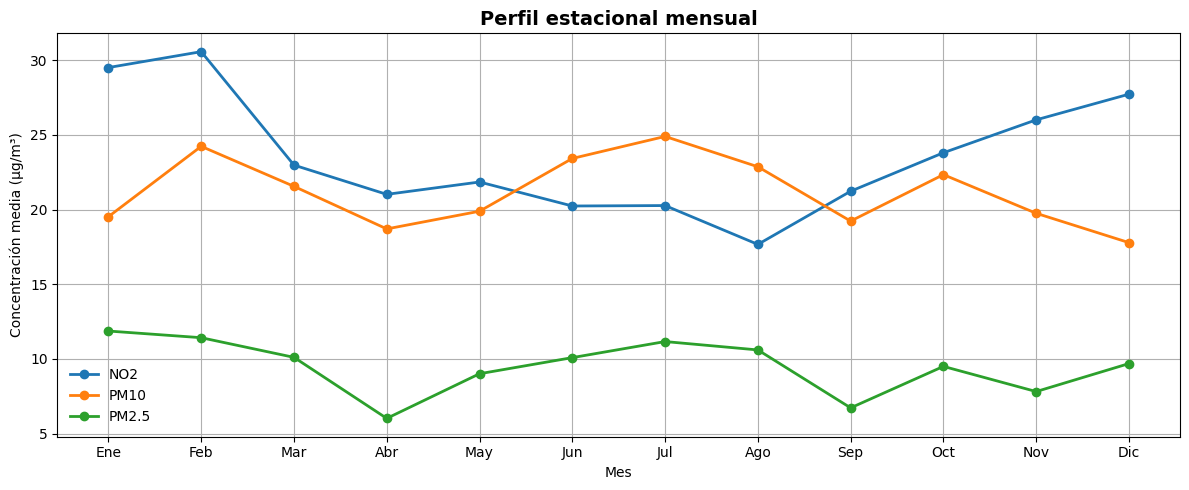

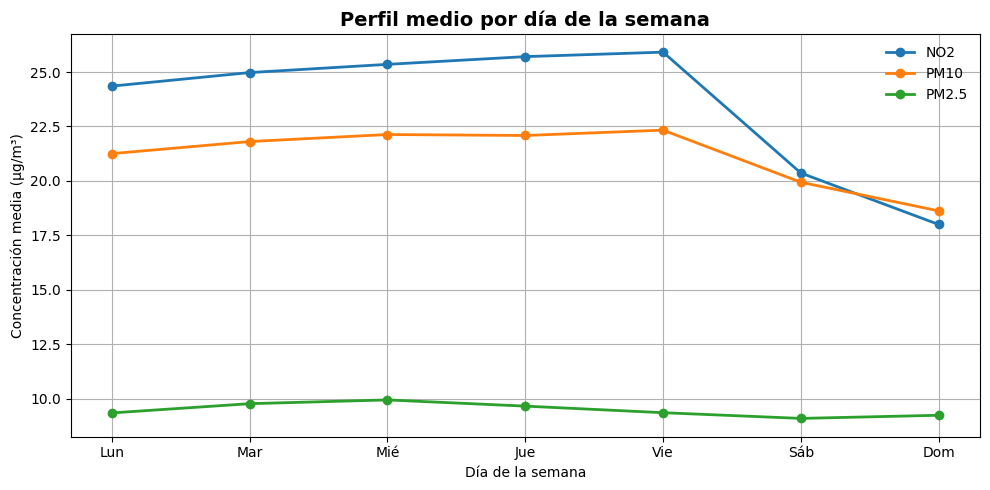

In [ ]:
# ============================================================
# 7. ESTACIONALIDAD MENSUAL Y SEMANAL
# ============================================================

MESES = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

DIAS = [
    "Lun", "Mar", "Mié", "Jue",
    "Vie", "Sáb", "Dom"
]


# ------------------------------------------------------------
# 7.1 Perfil mensual
# ------------------------------------------------------------

perfil_mensual = {}

print("=" * 80)
print("CONCENTRACIÓN MEDIA POR MES")
print("=" * 80)

for contaminante, serie in series_modelado.items():

    df_aux = pd.DataFrame({
        "valor": serie.dropna()
    })

    df_aux["mes"] = df_aux.index.month

    mensual = (
        df_aux
        .groupby("mes")["valor"]
        .agg(["mean", "median", "count"])
        .reindex(range(1, 13))
    )

    mensual.index = MESES

    perfil_mensual[contaminante] = mensual

    print(f"\n--- {contaminante} ---")
    print(mensual.round(2).to_string())


# ------------------------------------------------------------
# 7.2 Perfil semanal
# ------------------------------------------------------------

perfil_semanal = {}

print("\n" + "=" * 80)
print("CONCENTRACIÓN MEDIA POR DÍA DE LA SEMANA")
print("=" * 80)

for contaminante, serie in series_modelado.items():

    df_aux = pd.DataFrame({
        "valor": serie.dropna()
    })

    df_aux["dia_semana"] = df_aux.index.dayofweek

    semanal = (
        df_aux
        .groupby("dia_semana")["valor"]
        .agg(["mean", "median", "count"])
        .reindex(range(7))
    )

    semanal.index = DIAS

    perfil_semanal[contaminante] = semanal

    print(f"\n--- {contaminante} ---")
    print(semanal.round(2).to_string())


# ------------------------------------------------------------
# 7.3 Visualización mensual
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

for contaminante in CONTAMINANTES:

    datos = perfil_mensual[contaminante]

    ax.plot(
        MESES,
        datos["mean"],
        marker="o",
        linewidth=2,
        label=contaminante
    )

ax.set_title(
    "Perfil estacional mensual",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Mes")
ax.set_ylabel("Concentración media (µg/m³)")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7.4 Visualización semanal
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

for contaminante in CONTAMINANTES:

    datos = perfil_semanal[contaminante]

    ax.plot(
        DIAS,
        datos["mean"],
        marker="o",
        linewidth=2,
        label=contaminante
    )

ax.set_title(
    "Perfil medio por día de la semana",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Día de la semana")
ax.set_ylabel("Concentración media (µg/m³)")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Resultado · Patrones estacionales mensuales y semanales

El análisis confirma que los contaminantes presentan estructuras temporales diferenciadas tanto a escala mensual como semanal.

#### Patrón mensual

El **NO₂ muestra el ciclo anual más definido**. Las concentraciones medias alcanzan sus valores más elevados durante los meses de invierno, con máximos en enero y febrero (**29,50 y 30,56 µg/m³**), y disminuyen progresivamente hacia el verano, alcanzando el mínimo en agosto (**17,66 µg/m³**). A partir de septiembre se observa nuevamente un incremento hasta diciembre.

Este comportamiento sugiere una componente estacional anual relevante, compatible con la influencia conjunta de condiciones meteorológicas, dispersión atmosférica y cambios estacionales en la actividad urbana.

El **PM10 presenta un patrón mensual diferente y menos monotónico**. Destacan concentraciones relativamente elevadas en febrero y durante junio-julio, con un máximo mensual de **24,89 µg/m³ en julio**. La presencia de episodios extremos observada previamente puede contribuir a una mayor irregularidad de este perfil.

En **PM2.5**, cuya serie es más corta y corresponde a una única estación de referencia, las concentraciones medias mensuales oscilan entre aproximadamente **6 y 12 µg/m³**. Los valores más elevados aparecen en enero-febrero y julio-agosto, mientras que abril y septiembre presentan los niveles medios más bajos. Debido a la menor longitud de la serie, este patrón debe interpretarse con mayor cautela.

#### Patrón semanal

El ciclo semanal resulta especialmente marcado para **NO₂**. Las concentraciones aumentan desde el lunes hasta alcanzar su máximo medio el viernes (**25,91 µg/m³**) y posteriormente disminuyen de forma acusada durante el fin de semana:

- viernes: **25,91 µg/m³**;
- sábado: **20,36 µg/m³**;
- domingo: **18,00 µg/m³**.

La concentración media dominical resulta así aproximadamente un **30 % inferior a la del viernes**, mostrando una asociación clara entre el ciclo semanal de actividad urbana y los niveles de NO₂.

El **PM10 reproduce parcialmente este comportamiento**, aunque de forma menos intensa: pasa de **22,33 µg/m³ el viernes a 18,63 µg/m³ el domingo**, una reducción aproximada del **17 %**.

Por el contrario, **PM2.5 presenta un perfil semanal mucho más estable**, con diferencias reducidas entre los distintos días de la semana.

#### Implicación para la modelización

La existencia de un patrón semanal claramente reconocible, especialmente en NO₂ y PM10, respalda la incorporación de una **periodicidad estacional de 7 días (`m = 7`)** en los modelos SARIMA/SARIMAX.

El patrón mensual evidencia adicionalmente una dinámica de mayor escala, aunque no se incorporará directamente mediante una estacionalidad SARIMA anual de 365 días debido a su mayor complejidad computacional y a la longitud limitada de las series. Su influencia podrá quedar parcialmente representada mediante la dinámica temporal y las variables meteorológicas incorporadas posteriormente en SARIMAX.

> **Resultado destacado:** NO₂ presenta el ciclo semanal más acusado de los tres contaminantes, con concentraciones aproximadamente un 30 % inferiores el domingo respecto al viernes. Este comportamiento refuerza su relación con los ciclos de movilidad y actividad urbana.

## 8 · Estacionariedad y estructura de autocorrelación

La especificación de modelos ARIMA/SARIMA requiere analizar previamente las propiedades estadísticas de las series y su dependencia respecto a observaciones pasadas.

Se realizan dos diagnósticos complementarios:

1. **Test aumentado de Dickey-Fuller (ADF)**, cuya hipótesis nula establece la presencia de una raíz unitaria. Un valor `p < 0,05` permite rechazar dicha hipótesis y proporciona evidencia a favor de la estacionariedad de la serie.

2. **Funciones de autocorrelación (ACF) y autocorrelación parcial (PACF)**, utilizadas para identificar la persistencia temporal de las concentraciones y orientar los órdenes autorregresivos y de media móvil de los modelos.

Se examinan hasta **35 retardos**, permitiendo observar tanto la dependencia de corto plazo como posibles señales asociadas a múltiplos del ciclo semanal de 7 días.

Estos diagnósticos se utilizarán como orientación para definir un conjunto reducido de especificaciones SARIMA, evitando una búsqueda exhaustiva de hiperparámetros.

TEST AUMENTADO DE DICKEY-FULLER (ADF)

--- NO2 ---
Estadístico ADF : -4.9341
p-value         : 0.000030
Retardos        : 22
Observaciones   : 1787
Conclusión      : Estacionaria (se rechaza H0)

--- PM10 ---
Estadístico ADF : -6.6066
p-value         : 0.000000
Retardos        : 20
Observaciones   : 1789
Conclusión      : Estacionaria (se rechaza H0)

--- PM2.5 ---
Estadístico ADF : -8.7021
p-value         : 0.000000
Retardos        : 6
Observaciones   : 1063
Conclusión      : Estacionaria (se rechaza H0)


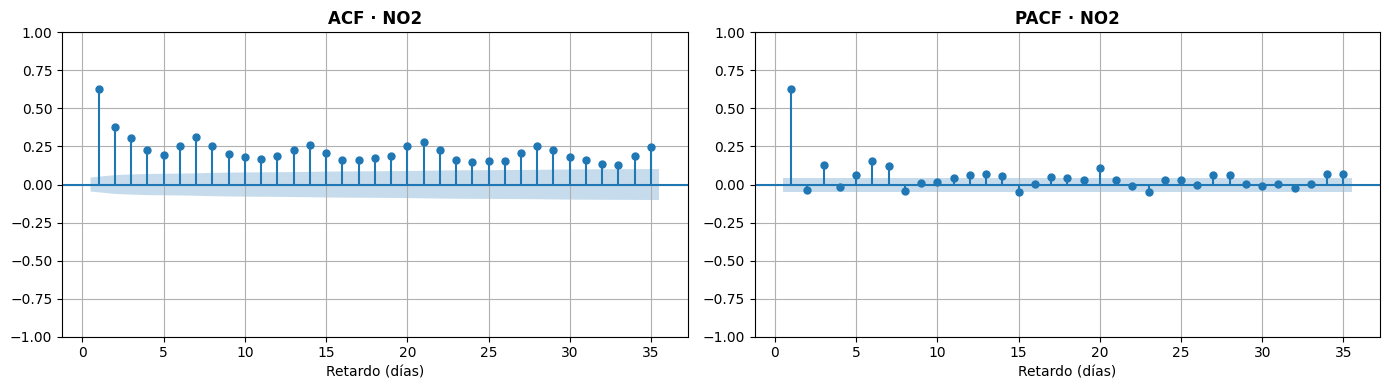

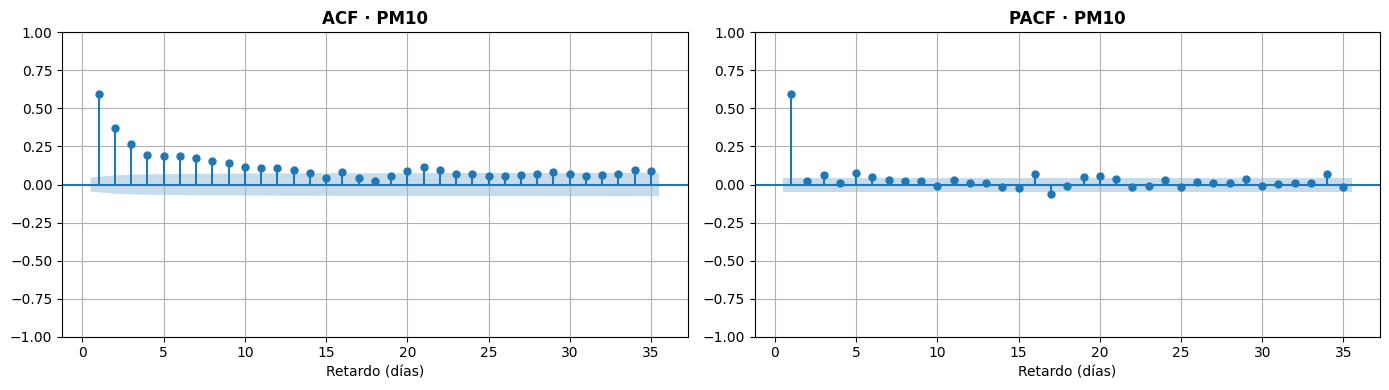

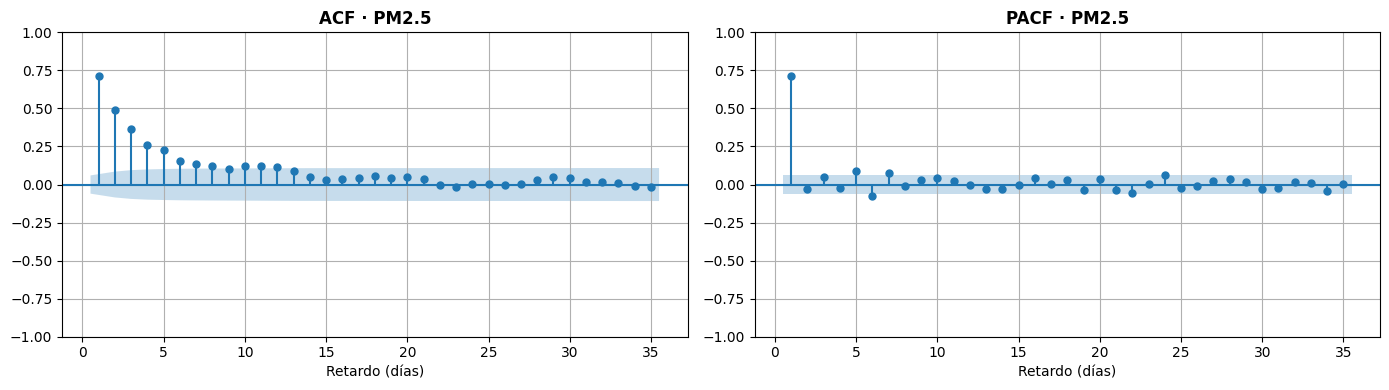

In [ ]:
# ============================================================
# 8. ESTACIONARIEDAD Y AUTOCORRELACIÓN
# ============================================================

resultados_adf = []


# ------------------------------------------------------------
# 8.1 Test ADF
# ------------------------------------------------------------

print("=" * 80)
print("TEST AUMENTADO DE DICKEY-FULLER (ADF)")
print("=" * 80)

for contaminante, serie in series_modelado.items():

    serie_valida = serie.dropna()

    resultado = adfuller(
        serie_valida,
        autolag="AIC"
    )

    estadistico = resultado[0]
    p_value = resultado[1]
    lags = resultado[2]
    n_obs = resultado[3]

    estacionaria = p_value < 0.05

    resultados_adf.append({
        "contaminante": contaminante,
        "ADF": estadistico,
        "p_value": p_value,
        "lags": lags,
        "n_obs": n_obs,
        "estacionaria_5pct": estacionaria
    })

    print(f"\n--- {contaminante} ---")
    print(f"Estadístico ADF : {estadistico:.4f}")
    print(f"p-value         : {p_value:.6f}")
    print(f"Retardos        : {lags}")
    print(f"Observaciones   : {n_obs}")
    print(
        "Conclusión      : "
        + (
            "Estacionaria (se rechaza H0)"
            if estacionaria
            else "No estacionaria (no se rechaza H0)"
        )
    )


resultados_adf = (
    pd.DataFrame(resultados_adf)
    .set_index("contaminante")
)


# ------------------------------------------------------------
# 8.2 ACF y PACF
# ------------------------------------------------------------

for contaminante, serie in series_modelado.items():

    serie_valida = serie.dropna()

    # Centrado para facilitar lectura
    serie_centrada = (
        serie_valida - serie_valida.mean()
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4)
    )

    plot_acf(
        serie_centrada,
        lags=35,
        ax=axes[0],
        zero=False
    )

    axes[0].set_title(
        f"ACF · {contaminante}",
        fontweight="bold"
    )

    axes[0].set_xlabel("Retardo (días)")


    plot_pacf(
        serie_centrada,
        lags=35,
        ax=axes[1],
        zero=False,
        method="ywm"
    )

    axes[1].set_title(
        f"PACF · {contaminante}",
        fontweight="bold"
    )

    axes[1].set_xlabel("Retardo (días)")

    plt.tight_layout()
    plt.show()

### Resultado · Estacionariedad y estructura de dependencia temporal

El test aumentado de Dickey-Fuller permite rechazar con claridad la hipótesis nula de raíz unitaria para los tres contaminantes.

| Contaminante | Estadístico ADF | p-value | Resultado |
|---|---:|---:|---|
| NO₂ | -4,9341 | 0,000030 | Estacionaria |
| PM10 | -6,6066 | < 0,000001 | Estacionaria |
| PM2.5 | -8,7021 | < 0,000001 | Estacionaria |

Por tanto, las tres series proporcionan evidencia estadística de **estacionariedad en sentido ADF**, por lo que no resulta necesario introducir automáticamente una diferenciación regular de primer orden (`d = 1`). Se partirá de especificaciones con **`d = 0`**, favoreciendo modelos más parsimoniosos.

#### NO₂

La función de autocorrelación muestra una dependencia temporal elevada en el primer retardo, con una correlación próxima a **0,6**, seguida de una disminución progresiva pero con persistencia positiva durante numerosos retardos.

La PACF presenta un primer retardo claramente dominante y contribuciones posteriores de menor magnitud. Se observan asimismo repuntes de autocorrelación próximos a múltiplos de siete días, coherentes con el patrón semanal identificado previamente.

#### PM10

PM10 reproduce una estructura similar, aunque con una pérdida de memoria algo más rápida. La ACF presenta una autocorrelación próxima a **0,6 en el primer retardo**, disminuyendo gradualmente a medida que aumenta la separación temporal.

La PACF vuelve a estar dominada por el primer retardo, lo que sugiere que una estructura autorregresiva de bajo orden puede capturar una parte importante de la dependencia de corto plazo.

#### PM2.5

PM2.5 presenta la mayor autocorrelación inmediata, próxima a **0,7 en el primer retardo**. La ACF disminuye progresivamente hasta aproximarse a cero en retardos superiores, mientras que la PACF vuelve a mostrar un primer retardo claramente predominante.

Aunque la serie es más corta, este comportamiento confirma igualmente la existencia de información predictiva en los valores inmediatamente anteriores.

#### Implicación para SARIMA

Los resultados justifican explorar **modelos de bajo orden**, evitando una búsqueda exhaustiva de combinaciones.

Se partirá de:

- diferenciación regular `d = 0`;
- términos AR/MA de orden reducido;
- periodicidad semanal `m = 7`;
- componente estacional igualmente parsimoniosa.

La selección final se realizará combinando criterios de información y, principalmente, **rendimiento fuera de muestra**, evitando aumentar la complejidad del modelo cuando no produzca una mejora predictiva relevante.

> En conjunto, las tres series presentan dependencia temporal suficiente para justificar modelos autorregresivos, mientras que el ciclo semanal observado previamente respalda la incorporación de una componente estacional de 7 días.

## 9 · Modelos de referencia y partición temporal

Antes de ajustar modelos SARIMA se establecen modelos de referencia (*baselines*) que permiten determinar si la mayor complejidad estadística produce una mejora predictiva real.

Se consideran dos estrategias simples:

- **Naive (`t−1`)**: utiliza como predicción la última concentración diaria disponible;
- **Seasonal Naive (`t−7`)**: utiliza como predicción la concentración observada siete días antes, incorporando de forma directa el ciclo semanal identificado en el análisis exploratorio.

La evaluación mantiene una partición estrictamente cronológica:

- **entrenamiento:** observaciones anteriores a 2024;
- **test:** año 2024.

Para NO₂ y PM10, 2024 presenta cobertura completa. En PM2.5 las métricas se calculan exclusivamente sobre fechas con concentración real observada y para las que el valor requerido por el baseline también está disponible.

Los modelos se comparan mediante:

- **MAE**, error absoluto medio;
- **RMSE**, que penaliza especialmente los errores elevados;
- **R²**, como medida complementaria de capacidad explicativa fuera de muestra.

Estos resultados constituirán el umbral mínimo que deberán superar posteriormente los modelos SARIMA y SARIMAX.

In [ ]:
# ============================================================
# 9. BASELINES Y PARTICIÓN TEMPORAL
# ============================================================

def metricas_regresion(y_true, y_pred):
    """
    Calcula métricas únicamente sobre pares
    observado-predicho válidos.
    """

    validos = (
        y_true.notna()
        & y_pred.notna()
    )

    yt = y_true.loc[validos]
    yp = y_pred.loc[validos]

    return {
        "n_test": len(yt),
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": np.sqrt(
            mean_squared_error(yt, yp)
        ),
        "R2": r2_score(yt, yp)
    }


# ------------------------------------------------------------
# 9.1 Partición temporal
# ------------------------------------------------------------

train_test = {}

print("=" * 80)
print("PARTICIÓN TEMPORAL")
print("=" * 80)

for contaminante, serie in series_modelado.items():

    train = serie[
        serie.index < "2024-01-01"
    ].copy()

    test = serie[
        (serie.index >= "2024-01-01")
        & (serie.index <= "2024-12-31")
    ].copy()

    train_test[contaminante] = {
        "train": train,
        "test": test
    }

    print(
        f"\n{contaminante}"
        f"\n  TRAIN: {train.index.min().date()} → "
        f"{train.index.max().date()} "
        f"| válidos = {train.notna().sum()}"
        f"\n  TEST : {test.index.min().date()} → "
        f"{test.index.max().date()} "
        f"| válidos = {test.notna().sum()}"
    )


# ------------------------------------------------------------
# 9.2 Naive t-1 y Seasonal Naive t-7
# ------------------------------------------------------------

resultados_baseline = []
predicciones_baseline = {}

for contaminante, serie in series_modelado.items():

    test = train_test[contaminante]["test"]

    # Las predicciones se generan desplazando la serie
    # original regular, sin utilizar información futura.
    pred_naive = serie.shift(1).reindex(
        test.index
    )

    pred_seasonal = serie.shift(7).reindex(
        test.index
    )

    predicciones_baseline[contaminante] = {
        "Naive_t1": pred_naive,
        "SeasonalNaive_t7": pred_seasonal
    }

    # Naive t-1
    met = metricas_regresion(
        test,
        pred_naive
    )

    resultados_baseline.append({
        "contaminante": contaminante,
        "modelo": "Naive t-1",
        **met
    })

    # Seasonal Naive t-7
    met = metricas_regresion(
        test,
        pred_seasonal
    )

    resultados_baseline.append({
        "contaminante": contaminante,
        "modelo": "Seasonal Naive t-7",
        **met
    })


# ------------------------------------------------------------
# 9.3 Tabla comparativa
# ------------------------------------------------------------

resultados_baseline = pd.DataFrame(
    resultados_baseline
)

print("\n" + "=" * 80)
print("RESULTADOS DE LOS MODELOS BASELINE · TEST 2024")
print("=" * 80)

print(
    resultados_baseline
    .round({
        "MAE": 3,
        "RMSE": 3,
        "R2": 3
    })
    .to_string(index=False)
)

PARTICIÓN TEMPORAL

NO2
  TRAIN: 2020-01-01 → 2023-12-31 | válidos = 1444
  TEST : 2024-01-01 → 2024-12-31 | válidos = 366

PM10
  TRAIN: 2020-01-01 → 2023-12-31 | válidos = 1444
  TEST : 2024-01-01 → 2024-12-31 | válidos = 366

PM2.5
  TRAIN: 2021-11-10 → 2023-12-31 | válidos = 739
  TEST : 2024-01-01 → 2024-12-31 | válidos = 331

RESULTADOS DE LOS MODELOS BASELINE · TEST 2024
contaminante             modelo  n_test   MAE   RMSE     R2
         NO2          Naive t-1     366 5.849  7.816  0.213
         NO2 Seasonal Naive t-7     366 8.040 10.720 -0.481
        PM10          Naive t-1     366 4.876  7.565  0.028
        PM10 Seasonal Naive t-7     366 7.322 10.065 -0.721
       PM2.5          Naive t-1     330 2.703  3.973  0.391
       PM2.5 Seasonal Naive t-7     324 4.748  6.731 -0.741


### Resultado · Modelos de referencia

Los modelos de referencia permiten establecer el nivel mínimo de rendimiento que deberán superar los modelos estadísticos posteriores.

| Contaminante | Modelo | n test | MAE | RMSE | R² |
|---|---|---:|---:|---:|---:|
| NO₂ | Naive t−1 | 366 | 5,849 | 7,816 | 0,213 |
| NO₂ | Seasonal Naive t−7 | 366 | 8,040 | 10,720 | -0,481 |
| PM10 | Naive t−1 | 366 | 4,876 | 7,565 | 0,028 |
| PM10 | Seasonal Naive t−7 | 366 | 7,322 | 10,065 | -0,721 |
| PM2.5 | Naive t−1 | 330 | 2,703 | 3,973 | 0,391 |
| PM2.5 | Seasonal Naive t−7 | 324 | 4,748 | 6,731 | -0,741 |

#### Persistencia de corto plazo

El modelo **Naive t−1 obtiene el mejor resultado de referencia en los tres contaminantes**, confirmando la elevada persistencia de corto plazo detectada previamente mediante las funciones ACF y PACF.

El comportamiento resulta especialmente destacable en **PM2.5**, donde la simple utilización de la concentración del día anterior alcanza un **R² de 0,391**. En NO₂ obtiene un R² de **0,213**, mientras que en PM10 la capacidad explicativa es más reducida (**R² = 0,028**).

#### Estacionalidad semanal

El modelo Seasonal Naive t−7 presenta un rendimiento claramente inferior y obtiene **R² negativo en los tres contaminantes**. Por tanto, conocer únicamente la concentración del mismo día de la semana anterior no resulta suficiente para generar predicciones competitivas.

Este resultado no contradice la existencia del patrón semanal observada en el análisis descriptivo. El perfil semanal refleja diferencias sistemáticas entre días laborables y fin de semana a escala agregada, mientras que la predicción diaria depende fuertemente de las condiciones inmediatamente anteriores y de otros factores variables, entre ellos las condiciones meteorológicas.

#### Implicación para la modelización

Los resultados establecen al modelo **Naive t−1 como baseline principal** para evaluar SARIMA y SARIMAX.

La modelización posterior deberá demostrar que la incorporación conjunta de dependencia autorregresiva, estructura estacional y variables exógenas permite reducir el error respecto a esta referencia simple.

> **Criterio de mejora:** se considerará especialmente relevante una reducción del MAE y RMSE respecto a Naive t−1 acompañada de una mejora del R² sobre el test temporal de 2024.

## 10 · Modelización SARIMA

Una vez establecidos los modelos de referencia se evalúa la capacidad predictiva de modelos SARIMA, diseñados específicamente para representar dependencia temporal y componentes estacionales.

Los diagnósticos previos permiten restringir la búsqueda a modelos parsimoniosos:

- el test ADF proporciona evidencia de estacionariedad, por lo que se adopta inicialmente **`d = 0`**;
- la PACF está dominada por el primer retardo, justificando estructuras autorregresivas de bajo orden;
- el análisis semanal respalda la exploración de una componente estacional de **7 días**.

En lugar de realizar una búsqueda exhaustiva de hiperparámetros, se comparará un conjunto reducido de especificaciones plausibles. Esta estrategia favorece la interpretabilidad y reduce el riesgo de seleccionar modelos excesivamente complejos.

Los valores ausentes del periodo de entrenamiento se mantienen como tales. La formulación en espacio de estados utilizada por `SARIMAX` permite su tratamiento durante la estimación sin necesidad de reconstruir artificialmente las concentraciones.

La selección se realizará considerando conjuntamente:

1. **AIC**, como criterio de ajuste penalizado por complejidad;
2. **MAE, RMSE y R² sobre el test temporal de 2024**;
3. comparación directa con el baseline **Naive t−1**.

La capacidad predictiva fuera de muestra tendrá prioridad sobre una mejora exclusivamente observada en el ajuste del modelo.

In [ ]:
# ============================================================
# 10. MODELOS SARIMA
# ============================================================

# ------------------------------------------------------------
# 10.1 Especificaciones candidatas
# ------------------------------------------------------------

CANDIDATOS_SARIMA = {
    "AR1": {
        "order": (1, 0, 0),
        "seasonal_order": (0, 0, 0, 0)
    },

    "ARMA11": {
        "order": (1, 0, 1),
        "seasonal_order": (0, 0, 0, 0)
    },

    "SARIMA_AR1_SAR1": {
        "order": (1, 0, 0),
        "seasonal_order": (1, 0, 0, 7)
    },

    "SARIMA_ARMA_SAR": {
        "order": (1, 0, 1),
        "seasonal_order": (1, 0, 0, 7)
    }
}


# ------------------------------------------------------------
# 10.2 Ajuste y evaluación
# ------------------------------------------------------------

resultados_sarima = []
modelos_sarima = {}
predicciones_sarima = {}

print("=" * 80)
print("AJUSTE Y EVALUACIÓN DE MODELOS SARIMA")
print("=" * 80)


for contaminante in CONTAMINANTES:

    print(f"\n{'=' * 80}")
    print(f"{contaminante}")
    print("=" * 80)

    train = train_test[contaminante]["train"]
    test = train_test[contaminante]["test"]

    modelos_sarima[contaminante] = {}
    predicciones_sarima[contaminante] = {}

    for nombre, config in CANDIDATOS_SARIMA.items():

        print(f"\n→ {nombre}")

        try:

            modelo = SARIMAX(
                train,
                order=config["order"],
                seasonal_order=config["seasonal_order"],
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            ajuste = modelo.fit(
                disp=False,
                maxiter=200
            )

            # Forecast completo de 2024
            forecast = ajuste.get_forecast(
                steps=len(test)
            )

            pred = pd.Series(
                forecast.predicted_mean.values,
                index=test.index,
                name=nombre
            )

            met = metricas_regresion(
                test,
                pred
            )

            resultados_sarima.append({
                "contaminante": contaminante,
                "modelo": nombre,
                "order": str(config["order"]),
                "seasonal_order": str(
                    config["seasonal_order"]
                ),
                "AIC": ajuste.aic,
                **met
            })

            modelos_sarima[contaminante][
                nombre
            ] = ajuste

            predicciones_sarima[contaminante][
                nombre
            ] = pred

            print(
                f"   AIC  = {ajuste.aic:.2f}"
                f"\n   MAE  = {met['MAE']:.3f}"
                f"\n   RMSE = {met['RMSE']:.3f}"
                f"\n   R²   = {met['R2']:.3f}"
            )

        except Exception as e:

            print(
                f"   ⚠ Error durante el ajuste: {e}"
            )


# ------------------------------------------------------------
# 10.3 Tabla comparativa
# ------------------------------------------------------------

resultados_sarima = pd.DataFrame(
    resultados_sarima
)

print("\n" + "=" * 80)
print("COMPARACIÓN GLOBAL · SARIMA")
print("=" * 80)

print(
    resultados_sarima
    .sort_values(
        ["contaminante", "RMSE"]
    )
    .round({
        "AIC": 2,
        "MAE": 3,
        "RMSE": 3,
        "R2": 3
    })
    .to_string(index=False)
)

AJUSTE Y EVALUACIÓN DE MODELOS SARIMA

NO2

→ AR1
   AIC  = 9942.30
   MAE  = 7.652
   RMSE = 9.264
   R²   = -0.106

→ ARMA11
   AIC  = 9935.41
   MAE  = 7.647
   RMSE = 9.260
   R²   = -0.105

→ SARIMA_AR1_SAR1
   AIC  = 9819.40
   MAE  = 7.551
   RMSE = 9.200
   R²   = -0.091

→ SARIMA_ARMA_SAR
   AIC  = 9818.74
   MAE  = 7.557
   RMSE = 9.203
   R²   = -0.092

PM10

→ AR1
   AIC  = 9771.67
   MAE  = 6.579
   RMSE = 8.144
   R²   = -0.127

→ ARMA11
   AIC  = 9767.22
   MAE  = 6.578
   RMSE = 8.144
   R²   = -0.127

→ SARIMA_AR1_SAR1
   AIC  = 9728.85
   MAE  = 6.575
   RMSE = 8.144
   R²   = -0.127

→ SARIMA_ARMA_SAR
   AIC  = 9730.35
   MAE  = 6.574
   RMSE = 8.144
   R²   = -0.127

PM2.5

→ AR1
   AIC  = 4210.08
   MAE  = 4.515
   RMSE = 5.519
   R²   = -0.176

→ ARMA11
   AIC  = 4206.05
   MAE  = 4.518
   RMSE = 5.519
   R²   = -0.176

→ SARIMA_AR1_SAR1
   AIC  = 4178.18
   MAE  = 4.517
   RMSE = 5.520
   R²   = -0.176

→ SARIMA_ARMA_SAR
   AIC  = 4179.25
   MAE  = 4.515
   RMSE 

### Resultado · Modelos SARIMA

Los modelos SARIMA muestran un comportamiento consistente entre los tres contaminantes, aunque su capacidad de predicción a largo horizonte resulta inferior a la obtenida por el baseline Naive t−1.

#### NO₂

La mejor especificación según el error fuera de muestra es **SARIMA(1,0,0)(1,0,0)₇**, con:

- MAE = **7,551 µg/m³**
- RMSE = **9,200 µg/m³**
- R² = **−0,091**
- AIC = **9.819,40**

La incorporación de la componente estacional semanal reduce sustancialmente el AIC respecto al modelo AR(1), aunque la mejora predictiva sobre 2024 es limitada.

#### PM10

Las cuatro especificaciones presentan un rendimiento prácticamente equivalente. El menor AIC corresponde a **SARIMA(1,0,0)(1,0,0)₇** (AIC = 9.728,85), mientras que las diferencias de MAE y RMSE entre modelos son mínimas.

El rendimiento fuera de muestra se sitúa aproximadamente en:

- MAE ≈ **6,57 µg/m³**
- RMSE ≈ **8,14 µg/m³**
- R² ≈ **−0,13**

Por tanto, aumentar la complejidad del componente ARMA no genera una mejora predictiva relevante.

#### PM2.5

El comportamiento vuelve a ser muy homogéneo entre especificaciones. El menor AIC corresponde a **SARIMA(1,0,0)(1,0,0)₇**, aunque el menor RMSE se obtiene, por una diferencia mínima, mediante SARIMA(1,0,1)(1,0,0)₇.

Los resultados se sitúan aproximadamente en:

- MAE ≈ **4,52 µg/m³**
- RMSE ≈ **5,52 µg/m³**
- R² ≈ **−0,18**

#### Comparación con los modelos de referencia

Ninguna de las especificaciones SARIMA supera al baseline **Naive t−1** en el test de 2024.

| Contaminante | Naive t−1 RMSE | Mejor SARIMA RMSE |
|---|---:|---:|
| NO₂ | 7,816 | 9,200 |
| PM10 | 7,565 | 8,144 |
| PM2.5 | 3,973 | 5,517 |

Este resultado debe interpretarse teniendo en cuenta el horizonte utilizado. Los modelos SARIMA generan aquí un **forecast recursivo de todo el año 2024 desde el final del periodo de entrenamiento**, sin actualizarse con las concentraciones reales observadas durante el año. Por el contrario, el baseline Naive t−1 utiliza en cada fecha la observación real inmediatamente anterior.

Por tanto, los resultados muestran principalmente la dificultad de mantener capacidad predictiva durante un horizonte de hasta 366 días utilizando exclusivamente la dinámica histórica de la propia concentración.

La reducción del AIC obtenida al introducir la componente semanal indica que esta estructura contribuye al ajuste interno de las series, especialmente en NO₂. Sin embargo, dicha mejora no se traduce por sí sola en una mayor precisión durante un forecast anual de largo horizonte.

> **Conclusión:** la información contenida exclusivamente en la historia del contaminante resulta insuficiente para mantener predicciones precisas a largo horizonte. Este resultado justifica evaluar a continuación modelos **SARIMAX**, incorporando variables exógenas capaces de representar cambios meteorológicos y de actividad urbana durante el periodo de predicción.

## 11 · Preparación de variables exógenas para SARIMAX

Los modelos SARIMA muestran que la dinámica histórica del contaminante permite representar parte de su estructura temporal, pero resulta insuficiente para mantener una predicción precisa durante un horizonte anual completo.

Se evalúa por tanto una segunda aproximación mediante **SARIMAX**, incorporando información externa potencialmente relacionada con la variación diaria de la calidad del aire.

Para mantener un modelo parsimonioso y evitar reproducir la elevada dimensionalidad utilizada en los modelos de Machine Learning, se selecciona inicialmente un conjunto reducido de variables representativas de dos bloques:

- **meteorología**, mediante temperatura, humedad, precipitación y velocidad del viento;
- **movilidad urbana**, mediante un indicador de intensidad de tráfico próximo a las estaciones.

La selección responde tanto a su interpretabilidad física como a su disponibilidad en el dataset maestro.

Antes del ajuste se auditará la cobertura temporal de estas variables y se construirá una serie exógena coherente con la misma unidad temporal y espacial utilizada para cada contaminante.

> El objetivo de SARIMAX no es reproducir el modelo multivariable de Machine Learning, sino evaluar si la incorporación de un pequeño conjunto de factores externos mejora la capacidad predictiva de los modelos estadísticos de series temporales.

In [ ]:
# ============================================================
# 11. AUDITORÍA DE VARIABLES EXÓGENAS CANDIDATAS
# ============================================================

EXOG_CANDIDATAS = [
    "TM",                    # temperatura media
    "HRM",                   # humedad relativa media
    "PPT",                   # precipitación
    "VVM10",                 # velocidad media del viento
    "trafico_idw_500m"       # tráfico próximo
]


# ------------------------------------------------------------
# 11.1 Cobertura global
# ------------------------------------------------------------

print("=" * 80)
print("COBERTURA DE VARIABLES EXÓGENAS CANDIDATAS")
print("=" * 80)

auditoria_exog = []

for variable in EXOG_CANDIDATAS:

    n_validos = df_maestro[variable].notna().sum()
    n_total = len(df_maestro)

    auditoria_exog.append({
        "variable": variable,
        "validos": n_validos,
        "missing": n_total - n_validos,
        "cobertura_pct": 100 * n_validos / n_total,
        "media": df_maestro[variable].mean(),
        "std": df_maestro[variable].std()
    })

auditoria_exog = pd.DataFrame(
    auditoria_exog
)

print(
    auditoria_exog
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 11.2 Cobertura anual por variable
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COBERTURA ANUAL (%)")
print("=" * 80)

for variable in EXOG_CANDIDATAS:

    tabla = (
        df_maestro
        .assign(anio=df_maestro["fecha"].dt.year)
        .groupby("anio")[variable]
        .apply(
            lambda x: 100 * x.notna().mean()
        )
    )

    print(f"\n--- {variable} ---")
    print(
        tabla.round(2).to_string()
    )


# ------------------------------------------------------------
# 11.3 Variabilidad de las candidatas
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RANGO DE VARIABLES EXÓGENAS")
print("=" * 80)

for variable in EXOG_CANDIDATAS:

    print(
        f"{variable:<20} | "
        f"min = {df_maestro[variable].min():8.2f} | "
        f"max = {df_maestro[variable].max():8.2f} | "
        f"únicos = {df_maestro[variable].nunique():6d}"
    )

COBERTURA DE VARIABLES EXÓGENAS CANDIDATAS
        variable  validos  missing  cobertura_pct    media      std
              TM    43215      427          99.02    17.93     6.01
             HRM    43215      427          99.02    67.78    11.98
             PPT    33539    10103          76.85     1.41     6.13
           VVM10    33539    10103          76.85     2.48     1.29
trafico_idw_500m    43202      440          98.99 17029.19 21211.66

COBERTURA ANUAL (%)

--- TM ---
anio
2018    100.00
2019    100.00
2020    100.00
2021    100.00
2022    100.00
2023    100.00
2024     94.29

--- HRM ---
anio
2018    100.00
2019    100.00
2020    100.00
2021    100.00
2022    100.00
2023    100.00
2024     94.29

--- PPT ---
anio
2018    75.72
2019    84.85
2020    75.22
2021    75.00
2022    76.08
2023    76.77
2024    76.75

--- VVM10 ---
anio
2018    75.72
2019    84.85
2020    75.22
2021    75.00
2022    76.08
2023    76.77
2024    76.75

--- trafico_idw_500m ---
anio
2018     87.46
201

### Resultado · Disponibilidad de variables exógenas

La auditoría muestra diferencias importantes en la cobertura de las variables candidatas para SARIMAX.

| Variable | Interpretación | Cobertura |
|---|---|---:|
| TM | Temperatura media | 99,02 % |
| HRM | Humedad relativa media | 99,02 % |
| PPT | Precipitación | 76,85 % |
| VVM10 | Velocidad media del viento | 76,85 % |
| trafico_idw_500m | Intensidad de tráfico próxima | 98,99 % |

La **temperatura media (TM)** y la **humedad relativa media (HRM)** presentan cobertura completa entre 2018 y 2023 y mantienen una disponibilidad elevada en 2024. El indicador de **tráfico ponderado por distancia (`trafico_idw_500m`)** presenta asimismo una cobertura prácticamente completa y alcanza el 100 % durante 2020–2024.

Por el contrario, precipitación y velocidad media del viento presentan aproximadamente un **23 % de valores ausentes**, con una cobertura anual situada generalmente alrededor del 75–77 %. Incorporarlas requeriría una reconstrucción considerable de información exógena, aumentando la complejidad metodológica y la dependencia respecto a valores imputados.

#### Selección inicial

Se seleccionan por tanto tres variables exógenas:

- **TM**, como indicador de las condiciones térmicas;
- **HRM**, como indicador de humedad atmosférica;
- **trafico_idw_500m**, como indicador de intensidad de movilidad próxima a las estaciones.

La selección combina **interpretabilidad, complementariedad y elevada cobertura**, manteniendo deliberadamente un SARIMAX parsimonioso.

Precipitación y velocidad del viento se excluyen de la especificación principal debido a su menor disponibilidad. Esta decisión prioriza la utilización de información observada frente al incremento del número de variables mediante una imputación extensa.

Antes del ajuste se comprobará la disponibilidad diaria efectiva de TM y HRM durante 2024 y se aplicará un tratamiento conservador únicamente si resulta necesario.

## 12 · Construcción de las series exógenas

Para mantener la coherencia entre la variable objetivo y las variables explicativas, las covariables de SARIMAX se construyen utilizando la misma referencia espacial empleada en cada serie de contaminación.

Para **NO₂ y PM10**, las variables exógenas se agregan diariamente a partir de las localizaciones que contribuyen a la construcción de la concentración de cada contaminante. Se consolida primero la información a nivel de `fecha × estacion_geo`, evitando nuevamente ponderaciones múltiples derivadas de identificadores históricos.

Para **PM2.5**, las variables exógenas corresponden exclusivamente a **Palau Reial**, manteniendo la misma localización utilizada como serie objetivo.

Se seleccionan tres covariables:

- temperatura media (`TM`);
- humedad relativa media (`HRM`);
- intensidad de tráfico ponderada por distancia (`trafico_idw_500m`).

Antes del ajuste se audita su continuidad diaria y se comprueba específicamente su disponibilidad durante el periodo de test de 2024.

In [ ]:
# ============================================================
# 12. CONSTRUCCIÓN DE SERIES EXÓGENAS
# ============================================================

EXOG_SELECCIONADAS = [
    "TM",
    "HRM",
    "trafico_idw_500m"
]

exog_series = {}


# ------------------------------------------------------------
# 12.1 NO2 y PM10
# ------------------------------------------------------------

for contaminante in ["NO2", "PM10"]:

    df_c = (
        df_maestro[
            df_maestro["contaminant"] == contaminante
        ][
            ["fecha", "estacion_geo"]
            + EXOG_SELECCIONADAS
        ]
        .copy()
    )

    # Un único valor por fecha × localización
    # para evitar duplicidad histórica
    por_estacion = (
        df_c
        .groupby(
            ["fecha", "estacion_geo"],
            as_index=False
        )[EXOG_SELECCIONADAS]
        .mean()
    )

    # Media entre las localizaciones disponibles
    exog_diaria = (
        por_estacion
        .groupby("fecha")[
            EXOG_SELECCIONADAS
        ]
        .mean()
        .sort_index()
    )

    # Exactamente el mismo índice de la serie objetivo
    exog_series[contaminante] = (
        exog_diaria
        .reindex(
            series_modelado[contaminante].index
        )
    )


# ------------------------------------------------------------
# 12.2 PM2.5 · Palau Reial
# ------------------------------------------------------------

df_pm25_exog = (
    df_maestro[
        (df_maestro["contaminant"] == "PM2.5")
        & (df_maestro["estacion_geo"] == "Palau Reial")
    ][
        ["fecha"] + EXOG_SELECCIONADAS
    ]
    .copy()
)

exog_pm25 = (
    df_pm25_exog
    .groupby("fecha")[
        EXOG_SELECCIONADAS
    ]
    .mean()
    .sort_index()
)

exog_series["PM2.5"] = (
    exog_pm25
    .reindex(
        series_modelado["PM2.5"].index
    )
)


# ------------------------------------------------------------
# 12.3 Auditoría general
# ------------------------------------------------------------

print("=" * 80)
print("COBERTURA DE SERIES EXÓGENAS")
print("=" * 80)

for contaminante in CONTAMINANTES:

    exog = exog_series[contaminante]

    print(f"\n--- {contaminante} ---")

    tabla = pd.DataFrame({
        "validos": exog.notna().sum(),
        "missing": exog.isna().sum(),
        "missing_pct": (
            100 * exog.isna().mean()
        )
    })

    print(
        tabla.round(2).to_string()
    )


# ------------------------------------------------------------
# 12.4 Auditoría específica TRAIN / TEST
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COBERTURA EXÓGENA · TRAIN / TEST")
print("=" * 80)

for contaminante in CONTAMINANTES:

    exog = exog_series[contaminante]

    exog_train = exog[
        exog.index < "2024-01-01"
    ]

    exog_test = exog[
        exog.index >= "2024-01-01"
    ]

    print(f"\n--- {contaminante} ---")

    for variable in EXOG_SELECCIONADAS:

        print(
            f"{variable:<20} | "
            f"TRAIN missing = "
            f"{exog_train[variable].isna().sum():3d} | "
            f"TEST missing = "
            f"{exog_test[variable].isna().sum():3d}"
        )


# ------------------------------------------------------------
# 12.5 Bloques missing en TEST 2024
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BLOQUES SIN EXÓGENAS EN TEST 2024")
print("=" * 80)

for contaminante in CONTAMINANTES:

    print(f"\n--- {contaminante} ---")

    exog_test = exog_series[
        contaminante
    ].loc["2024"]

    for variable in EXOG_SELECCIONADAS:

        serie_var = exog_test[variable]

        bloques = obtener_bloques_missing(
            serie_var
        )

        if bloques.empty:

            print(
                f"{variable:<20}: "
                "sin huecos"
            )

        else:

            max_hueco = int(
                bloques["dias"].max()
            )

            print(
                f"{variable:<20}: "
                f"{serie_var.isna().sum()} missing | "
                f"máx. hueco = {max_hueco} días"
            )

            print(
                bloques.head(3).to_string(
                    index=False
                )
            )

COBERTURA DE SERIES EXÓGENAS

--- NO2 ---
                  validos  missing  missing_pct
TM                   1810       17         0.93
HRM                  1810       17         0.93
trafico_idw_500m     1810       17         0.93

--- PM10 ---
                  validos  missing  missing_pct
TM                   1810       17         0.93
HRM                  1810       17         0.93
trafico_idw_500m     1810       17         0.93

--- PM2.5 ---
                  validos  missing  missing_pct
TM                   1070       78         6.79
HRM                  1070       78         6.79
trafico_idw_500m     1070       78         6.79

COBERTURA EXÓGENA · TRAIN / TEST

--- NO2 ---
TM                   | TRAIN missing =  17 | TEST missing =   0
HRM                  | TRAIN missing =  17 | TEST missing =   0
trafico_idw_500m     | TRAIN missing =  17 | TEST missing =   0

--- PM10 ---
TM                   | TRAIN missing =  17 | TEST missing =   0
HRM                  | TRAIN missing

### Resultado · Series exógenas

La construcción de las variables exógenas mantiene una correspondencia directa con la disponibilidad de las series objetivo.

Para **NO₂ y PM10**, temperatura, humedad y tráfico presentan únicamente **17 días ausentes durante 2020–2023**, coincidentes con las discontinuidades ya identificadas en las respectivas series de contaminación. El periodo de test de **2024 dispone de cobertura completa en las tres covariables**.

En **PM2.5**, las variables exógenas presentan 78 días sin información. Durante 2024, los **35 días ausentes corresponden exactamente al intervalo comprendido entre el 9 de mayo y el 12 de junio**, periodo en el que tampoco existe concentración observada de PM2.5 en Palau Reial.

Por tanto, no es necesario reconstruir mediante interpolación el bloque de 2024 para calcular las métricas finales, ya que no existe una observación real del contaminante contra la que evaluar una predicción.

#### Estrategia adoptada

- **NO₂ y PM10:** SARIMAX puede evaluarse sobre los 366 días de 2024 utilizando covariables observadas completas.
- **PM2.5:** el ajuste y la evaluación se realizarán únicamente sobre fechas con información disponible, manteniendo explícitamente identificado el bloque sin observaciones.
- Los valores ausentes de entrenamiento se tratarán de forma conservadora para garantizar la matriz exógena requerida por el modelo, sin incorporar información procedente del periodo futuro.

La coincidencia entre las ausencias de las variables objetivo y exógenas indica que los huecos proceden fundamentalmente de la disponibilidad de las observaciones integradas y no de pérdidas independientes en cada covariable.

## 13 · Modelización SARIMAX

Se evalúa finalmente la extensión SARIMAX, incorporando variables exógenas a la estructura temporal seleccionada previamente.

Para los tres contaminantes se adopta como estructura común y parsimoniosa:

**SARIMA(1,0,0)(1,0,0)₇**

Esta elección permite mantener constante la componente temporal y evaluar específicamente el efecto de incorporar información externa.

Se comparan tres configuraciones:

1. **Meteorología:** temperatura media y humedad relativa.
2. **Tráfico:** intensidad de tráfico ponderada por distancia.
3. **Meteorología + tráfico:** combinación de los dos bloques anteriores.

Esta comparación permite cuantificar si la mejora predictiva procede principalmente de las condiciones atmosféricas, de la actividad urbana o de su combinación.

Las variables exógenas del periodo de test corresponden a valores observados durante 2024. En consecuencia, el experimento se interpreta como una **predicción condicional a covariables conocidas**, y no como un pronóstico realizado a finales de 2023 disponiendo anticipadamente de las condiciones meteorológicas y de tráfico de todo 2024.

La evaluación mantiene las métricas MAE, RMSE y R² y se compara con los resultados obtenidos previamente mediante Naive t−1 y SARIMA.

In [ ]:
# ============================================================
# 13. MODELOS SARIMAX
# ============================================================

CONFIG_EXOG = {
    "Meteorologia": [
        "TM",
        "HRM"
    ],

    "Trafico": [
        "trafico_idw_500m"
    ],

    "Meteo_Trafico": [
        "TM",
        "HRM",
        "trafico_idw_500m"
    ]
}

ORDER_BASE = (1, 0, 0)
SEASONAL_BASE = (1, 0, 0, 7)

resultados_sarimax = []
modelos_sarimax = {}
predicciones_sarimax = {}


# ------------------------------------------------------------
# 13.1 Función conservadora para preparar exógenas
# ------------------------------------------------------------

def preparar_exog_train(df):
    """
    Completa únicamente pequeños huecos internos de las
    covariables del TRAIN.

    No utiliza información del periodo TEST.
    """

    df = df.copy()

    df = df.interpolate(
        method="time",
        limit_direction="both"
    )

    return df


# ------------------------------------------------------------
# 13.2 Ajuste por contaminante
# ------------------------------------------------------------

print("=" * 80)
print("AJUSTE Y EVALUACIÓN DE MODELOS SARIMAX")
print("=" * 80)


for contaminante in CONTAMINANTES:

    print(f"\n{'=' * 80}")
    print(contaminante)
    print("=" * 80)

    y_train = train_test[
        contaminante
    ]["train"]

    y_test = train_test[
        contaminante
    ]["test"]

    exog = exog_series[
        contaminante
    ]

    X_train_base = exog[
        exog.index < "2024-01-01"
    ].copy()

    X_test_base = exog[
        exog.index >= "2024-01-01"
    ].copy()

    modelos_sarimax[
        contaminante
    ] = {}

    predicciones_sarimax[
        contaminante
    ] = {}


    for nombre, variables in CONFIG_EXOG.items():

        print(f"\n→ SARIMAX · {nombre}")

        X_train = (
            X_train_base[variables]
            .copy()
        )

        X_test = (
            X_test_base[variables]
            .copy()
        )

        # -----------------------------------------------
        # TRAIN
        # -----------------------------------------------

        X_train = preparar_exog_train(
            X_train
        )

        # -----------------------------------------------
        # TEST
        #
        # NO2 / PM10: completo.
        # PM2.5: se ajustan/evalúan únicamente fechas
        # donde existen exógenas.
        # -----------------------------------------------

        fechas_test_validas = (
            y_test.notna()
            & X_test.notna().all(axis=1)
        )

        X_test_valido = X_test.loc[
            fechas_test_validas
        ]

        y_test_valido = y_test.loc[
            fechas_test_validas
        ]

        try:

            modelo = SARIMAX(
                y_train,
                exog=X_train,
                order=ORDER_BASE,
                seasonal_order=SEASONAL_BASE,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            ajuste = modelo.fit(
                disp=False,
                maxiter=200
            )

            # -------------------------------------------
            # Forecast
            # -------------------------------------------

            if contaminante != "PM2.5":

                forecast = ajuste.get_forecast(
                    steps=len(X_test),
                    exog=X_test
                )

                pred = pd.Series(
                    forecast.predicted_mean.values,
                    index=X_test.index,
                    name=nombre
                )

            else:
                # PM2.5 contiene un bloque sin exógenas.
                # Para mantener el índice temporal regular,
                # las exógenas de ese bloque se interpolan
                # SOLO para permitir la propagación del estado.
                # Esos días NO entrarán en las métricas.

                X_test_modelo = X_test.interpolate(
                    method="time",
                    limit_direction="both"
                )

                forecast = ajuste.get_forecast(
                    steps=len(X_test_modelo),
                    exog=X_test_modelo
                )

                pred = pd.Series(
                    forecast.predicted_mean.values,
                    index=X_test_modelo.index,
                    name=nombre
                )

            # -------------------------------------------
            # Métricas solo sobre observaciones reales
            # -------------------------------------------

            met = metricas_regresion(
                y_test,
                pred
            )

            resultados_sarimax.append({
                "contaminante": contaminante,
                "modelo": nombre,
                "variables": " + ".join(variables),
                "AIC": ajuste.aic,
                **met
            })

            modelos_sarimax[
                contaminante
            ][nombre] = ajuste

            predicciones_sarimax[
                contaminante
            ][nombre] = pred

            print(
                f"   AIC  = {ajuste.aic:.2f}"
                f"\n   MAE  = {met['MAE']:.3f}"
                f"\n   RMSE = {met['RMSE']:.3f}"
                f"\n   R²   = {met['R2']:.3f}"
                f"\n   n    = {met['n_test']}"
            )

        except Exception as e:

            print(
                f"   ⚠ Error durante el ajuste: {e}"
            )


# ------------------------------------------------------------
# 13.3 Tabla final SARIMAX
# ------------------------------------------------------------

resultados_sarimax = pd.DataFrame(
    resultados_sarimax
)

print("\n" + "=" * 80)
print("COMPARACIÓN GLOBAL · SARIMAX")
print("=" * 80)

print(
    resultados_sarimax
    .sort_values(
        ["contaminante", "RMSE"]
    )
    .round({
        "AIC": 2,
        "MAE": 3,
        "RMSE": 3,
        "R2": 3
    })
    .to_string(index=False)
)

AJUSTE Y EVALUACIÓN DE MODELOS SARIMAX

NO2

→ SARIMAX · Meteorologia
   AIC  = 9806.51
   MAE  = 7.697
   RMSE = 9.344
   R²   = -0.125
   n    = 366

→ SARIMAX · Trafico
   AIC  = 9690.47
   MAE  = 6.832
   RMSE = 8.740
   R²   = 0.015
   n    = 366

→ SARIMAX · Meteo_Trafico
   AIC  = 9641.74
   MAE  = 7.262
   RMSE = 9.041
   R²   = -0.053
   n    = 366

PM10

→ SARIMAX · Meteorologia
   AIC  = 9635.18
   MAE  = 6.566
   RMSE = 8.030
   R²   = -0.096
   n    = 366

→ SARIMAX · Trafico
   AIC  = 9972.48
   MAE  = 7.453
   RMSE = 10.006
   R²   = -0.701
   n    = 366

→ SARIMAX · Meteo_Trafico
   AIC  = 9657.23
   MAE  = 6.414
   RMSE = 8.023
   R²   = -0.093
   n    = 366

PM2.5

→ SARIMAX · Meteorologia
   AIC  = 4065.12
   MAE  = 4.561
   RMSE = 5.451
   R²   = -0.147
   n    = 331

→ SARIMAX · Trafico
   AIC  = 4269.66
   MAE  = 5.983
   RMSE = 7.749
   R²   = -1.318
   n    = 331

→ SARIMAX · Meteo_Trafico
   AIC  = 4087.82
   MAE  = 4.439
   RMSE = 5.468
   R²   = -0.154
   n  

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Resultado · Modelos SARIMAX

La incorporación de variables exógenas produce efectos diferentes según el contaminante, confirmando que la contribución de meteorología y tráfico no es homogénea.

#### NO₂

El mejor rendimiento fuera de muestra corresponde al modelo **SARIMAX con tráfico**, con:

- MAE = **6,832 µg/m³**
- RMSE = **8,740 µg/m³**
- R² = **0,015**
- AIC = **9.690,47**

Respecto al SARIMA seleccionado (RMSE = 9,200), la incorporación del tráfico reduce el RMSE aproximadamente un **5 %** y recupera un R² ligeramente positivo.

La incorporación exclusiva de temperatura y humedad no mejora el modelo temporal, mientras que la combinación de meteorología y tráfico presenta un rendimiento intermedio.

Este resultado indica que, dentro de las variables analizadas, el indicador de tráfico contiene información adicional especialmente relevante para explicar la variabilidad temporal del NO₂.

#### PM10

En PM10 las diferencias entre SARIMA y las configuraciones con meteorología son reducidas. El menor RMSE corresponde a **SARIMAX con meteorología y tráfico (8,023 µg/m³)**, prácticamente equivalente al modelo exclusivamente meteorológico (8,030 µg/m³).

Por el contrario, el modelo basado únicamente en tráfico empeora notablemente el rendimiento (RMSE = 10,006; R² = −0,701).

Los resultados sugieren que la variabilidad temporal de PM10 no queda adecuadamente representada mediante el indicador de tráfico aislado y que las condiciones meteorológicas aportan una mejora limitada sobre la dinámica temporal del propio contaminante.

#### PM2.5

Para PM2.5, el menor RMSE corresponde a **SARIMAX con meteorología (5,451 µg/m³)**, ligeramente inferior al obtenido mediante SARIMA (5,517 µg/m³).

La combinación de meteorología y tráfico reduce ligeramente el MAE hasta **4,439 µg/m³**, pero no mejora el RMSE. El tráfico utilizado de forma aislada presenta nuevamente un comportamiento claramente desfavorable.

Debido a que PM2.5 se modeliza mediante una única estación de referencia y dispone de una serie temporal más corta, estos resultados deben interpretarse con mayor cautela.

#### Comparación con SARIMA

La incorporación de covariables mejora parcialmente los modelos estadísticos:

- en **NO₂**, el mayor beneficio procede del tráfico;
- en **PM10**, la meteorología proporciona una mejora pequeña;
- en **PM2.5**, la meteorología reduce ligeramente el RMSE.

Sin embargo, ninguna configuración SARIMAX supera al baseline **Naive t−1** bajo el escenario de forecast anual utilizado.

Este comportamiento confirma la elevada persistencia diaria de las concentraciones y evidencia la dificultad de realizar predicciones recursivas a muy largo horizonte sin actualizar el modelo con nuevas observaciones del contaminante.

#### Alcance de la evaluación

Las covariables utilizadas durante 2024 corresponden a valores observados, por lo que los resultados SARIMAX deben interpretarse como **predicciones condicionadas a información exógena conocida**.

Además, durante el proceso de estimación se detectó al menos una advertencia de convergencia del optimizador. Antes de seleccionar los modelos definitivos se verificará explícitamente el estado de convergencia de cada ajuste, evitando considerar como modelo final una especificación cuya estimación no haya alcanzado una solución estable.

## 14 · Verificación de convergencia de los modelos SARIMAX

La estimación mediante máxima verosimilitud generó una advertencia de convergencia en al menos una de las especificaciones ajustadas.

Antes de realizar la comparación definitiva se comprueba explícitamente el estado del optimizador para cada modelo. La convergencia constituye un criterio adicional de validez: una especificación con métricas aparentemente favorables no debe seleccionarse como modelo final si sus parámetros no han alcanzado una solución numéricamente estable.

Esta comprobación permite diferenciar entre:

- modelos correctamente convergidos;
- especificaciones que requieren cautela o deben descartarse;
- posibles problemas asociados a la escala de las variables exógenas.

In [ ]:
# ============================================================
# 14. VERIFICACIÓN DE CONVERGENCIA
# ============================================================

convergencia = []

print("=" * 80)
print("CONVERGENCIA DE LOS MODELOS SARIMAX")
print("=" * 80)

for contaminante in CONTAMINANTES:

    for nombre, ajuste in modelos_sarimax[
        contaminante
    ].items():

        mle = ajuste.mle_retvals

        converged = mle.get(
            "converged",
            None
        )

        iterations = mle.get(
            "iterations",
            None
        )

        convergencia.append({
            "contaminante": contaminante,
            "modelo": nombre,
            "converged": converged,
            "iterations": iterations,
            "AIC": ajuste.aic
        })


df_convergencia = pd.DataFrame(
    convergencia
)

print(
    df_convergencia
    .round({"AIC": 2})
    .to_string(index=False)
)


# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMEN")
print("=" * 80)

n_total = len(df_convergencia)

n_ok = (
    df_convergencia["converged"]
    == True
).sum()

n_fail = (
    df_convergencia["converged"]
    == False
).sum()

print(f"Modelos ajustados   : {n_total}")
print(f"Convergencia correcta: {n_ok}")
print(f"Sin convergencia     : {n_fail}")

if n_fail > 0:

    print(
        "\n⚠ Modelos que requieren revisión:"
    )

    print(
        df_convergencia.loc[
            df_convergencia["converged"]
            == False,
            [
                "contaminante",
                "modelo",
                "iterations",
                "AIC"
            ]
        ].to_string(index=False)
    )

else:

    print(
        "\n✓ Todos los modelos SARIMAX "
        "han convergido correctamente."
    )

CONVERGENCIA DE LOS MODELOS SARIMAX
contaminante        modelo  converged  iterations     AIC
         NO2  Meteorologia       True          32 9806.51
         NO2       Trafico       True           2 9690.47
         NO2 Meteo_Trafico       True           2 9641.74
        PM10  Meteorologia       True          38 9635.18
        PM10       Trafico       True           2 9972.48
        PM10 Meteo_Trafico       True           2 9657.23
       PM2.5  Meteorologia       True          30 4065.12
       PM2.5       Trafico       True           2 4269.66
       PM2.5 Meteo_Trafico      False           1 4087.82

RESUMEN
Modelos ajustados   : 9
Convergencia correcta: 8
Sin convergencia     : 1

⚠ Modelos que requieren revisión:
contaminante        modelo  iterations         AIC
       PM2.5 Meteo_Trafico           1 4087.816195


### Resultado · Verificación de convergencia

La comprobación del proceso de máxima verosimilitud confirma una estimación numéricamente estable en **8 de los 9 modelos SARIMAX** evaluados.

Todos los modelos correspondientes a **NO₂ y PM10** convergen correctamente, al igual que las especificaciones de PM2.5 basadas exclusivamente en meteorología o tráfico.

La única excepción corresponde a **PM2.5 · Meteorología + tráfico**, cuyo optimizador se detiene tras una iteración sin alcanzar convergencia.

| Contaminante | Configuración | Convergencia |
|---|---|---|
| NO₂ | Meteorología | Sí |
| NO₂ | Tráfico | Sí |
| NO₂ | Meteorología + tráfico | Sí |
| PM10 | Meteorología | Sí |
| PM10 | Tráfico | Sí |
| PM10 | Meteorología + tráfico | Sí |
| PM2.5 | Meteorología | Sí |
| PM2.5 | Tráfico | Sí |
| PM2.5 | Meteorología + tráfico | **No** |

#### Decisión metodológica

La especificación **PM2.5 · Meteorología + tráfico se excluye de la selección final**, independientemente de sus métricas aparentes, al no disponer de una estimación convergida.

No se considera necesario aumentar la complejidad del proceso de optimización para recuperar esta especificación, ya que el modelo convergido basado exclusivamente en meteorología presenta además un RMSE ligeramente inferior.

En consecuencia, todos los modelos considerados en la comparación final dispondrán de una estimación convergida y numéricamente estable.

## 15 · Comparación final de modelos

La fase final de evaluación compara las tres aproximaciones desarrolladas para cada contaminante:

1. **Naive t−1**, como referencia basada exclusivamente en persistencia diaria;
2. **SARIMA**, como modelo estadístico basado en la dinámica interna de la serie;
3. **SARIMAX**, incorporando además información meteorológica o de tráfico.

Para garantizar una comparación metodológicamente válida, únicamente se consideran modelos SARIMAX cuya estimación haya convergido correctamente.

La selección del mejor modelo dentro de cada familia se realiza principalmente mediante **RMSE sobre el test temporal de 2024**, utilizando MAE y R² como métricas complementarias.

Se calcula asimismo la variación porcentual del RMSE respecto al baseline Naive t−1. Un valor positivo de mejora indica una reducción del error respecto al baseline, mientras que un valor negativo indica un rendimiento inferior.

Esta comparación permite determinar no solo qué modelo obtiene el menor error, sino también si el incremento de complejidad de SARIMA/SARIMAX se traduce realmente en una mejora predictiva fuera de muestra.

In [ ]:
# ============================================================
# 15. COMPARACIÓN FINAL DE MODELOS
# ============================================================

comparacion_final = []


for contaminante in CONTAMINANTES:

    # --------------------------------------------------------
    # BASELINE · Naive t-1
    # --------------------------------------------------------

    fila_naive = resultados_baseline[
        (resultados_baseline["contaminante"] == contaminante)
        & (resultados_baseline["modelo"] == "Naive t-1")
    ].iloc[0]

    rmse_naive = fila_naive["RMSE"]

    comparacion_final.append({
        "contaminante": contaminante,
        "familia": "Baseline",
        "modelo": "Naive t-1",
        "MAE": fila_naive["MAE"],
        "RMSE": fila_naive["RMSE"],
        "R2": fila_naive["R2"],
        "mejora_RMSE_vs_naive_pct": 0.0
    })


    # --------------------------------------------------------
    # MEJOR SARIMA POR RMSE
    # --------------------------------------------------------

    candidatos_sarima = resultados_sarima[
        resultados_sarima["contaminante"]
        == contaminante
    ]

    mejor_sarima = candidatos_sarima.loc[
        candidatos_sarima["RMSE"].idxmin()
    ]

    mejora_sarima = (
        100
        * (rmse_naive - mejor_sarima["RMSE"])
        / rmse_naive
    )

    comparacion_final.append({
        "contaminante": contaminante,
        "familia": "SARIMA",
        "modelo": mejor_sarima["modelo"],
        "MAE": mejor_sarima["MAE"],
        "RMSE": mejor_sarima["RMSE"],
        "R2": mejor_sarima["R2"],
        "mejora_RMSE_vs_naive_pct": mejora_sarima
    })


    # --------------------------------------------------------
    # MEJOR SARIMAX CONVERGIDO POR RMSE
    # --------------------------------------------------------

    modelos_ok = df_convergencia[
        (df_convergencia["contaminante"] == contaminante)
        & (df_convergencia["converged"] == True)
    ]["modelo"]

    candidatos_sarimax = resultados_sarimax[
        (resultados_sarimax["contaminante"] == contaminante)
        & (resultados_sarimax["modelo"].isin(modelos_ok))
    ]

    mejor_sarimax = candidatos_sarimax.loc[
        candidatos_sarimax["RMSE"].idxmin()
    ]

    mejora_sarimax = (
        100
        * (rmse_naive - mejor_sarimax["RMSE"])
        / rmse_naive
    )

    comparacion_final.append({
        "contaminante": contaminante,
        "familia": "SARIMAX",
        "modelo": mejor_sarimax["modelo"],
        "MAE": mejor_sarimax["MAE"],
        "RMSE": mejor_sarimax["RMSE"],
        "R2": mejor_sarimax["R2"],
        "mejora_RMSE_vs_naive_pct": mejora_sarimax
    })


# ------------------------------------------------------------
# Tabla
# ------------------------------------------------------------

comparacion_final = pd.DataFrame(
    comparacion_final
)


print("=" * 80)
print("COMPARACIÓN FINAL · TEST 2024")
print("=" * 80)

print(
    comparacion_final
    .round({
        "MAE": 3,
        "RMSE": 3,
        "R2": 3,
        "mejora_RMSE_vs_naive_pct": 2
    })
    .to_string(index=False)
)


# ------------------------------------------------------------
# Ganador absoluto por contaminante
# ------------------------------------------------------------

ganadores = (
    comparacion_final
    .loc[
        comparacion_final
        .groupby("contaminante")["RMSE"]
        .idxmin()
    ]
    .sort_values("contaminante")
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("MEJOR MODELO POR CONTAMINANTE")
print("=" * 80)

print(
    ganadores[
        [
            "contaminante",
            "familia",
            "modelo",
            "MAE",
            "RMSE",
            "R2"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

COMPARACIÓN FINAL · TEST 2024
contaminante  familia          modelo   MAE  RMSE     R2  mejora_RMSE_vs_naive_pct
         NO2 Baseline       Naive t-1 5.849 7.816  0.213                      0.00
         NO2   SARIMA SARIMA_AR1_SAR1 7.551 9.200 -0.091                    -17.71
         NO2  SARIMAX         Trafico 6.832 8.740  0.015                    -11.82
        PM10 Baseline       Naive t-1 4.876 7.565  0.028                      0.00
        PM10   SARIMA          ARMA11 6.578 8.144 -0.127                     -7.65
        PM10  SARIMAX   Meteo_Trafico 6.414 8.023 -0.093                     -6.05
       PM2.5 Baseline       Naive t-1 2.703 3.973  0.391                      0.00
       PM2.5   SARIMA SARIMA_ARMA_SAR 4.515 5.517 -0.175                    -38.88
       PM2.5  SARIMAX    Meteorologia 4.561 5.451 -0.147                    -37.21

MEJOR MODELO POR CONTAMINANTE
contaminante  familia    modelo   MAE  RMSE    R2
         NO2 Baseline Naive t-1 5.849 7.816 0.213
        P

### Resultado · Comparación final de modelos

La comparación sobre el periodo de test de 2024 muestra un resultado consistente para los tres contaminantes: el modelo más simple, **Naive t−1**, obtiene el menor error predictivo.

| Contaminante | Familia | Mejor modelo | MAE | RMSE | R² | Δ RMSE vs. Naive |
|---|---|---|---:|---:|---:|---:|
| NO₂ | Baseline | Naive t−1 | 5,849 | 7,816 | 0,213 | — |
|  | SARIMA | SARIMA(1,0,0)(1,0,0)₇ | 7,551 | 9,200 | −0,091 | −17,71 % |
|  | SARIMAX | Tráfico | 6,832 | 8,740 | 0,015 | −11,82 % |
| PM10 | Baseline | Naive t−1 | 4,876 | 7,565 | 0,028 | — |
|  | SARIMA | ARMA(1,1) | 6,578 | 8,144 | −0,127 | −7,65 % |
|  | SARIMAX | Meteorología + tráfico | 6,414 | 8,023 | −0,093 | −6,05 % |
| PM2.5 | Baseline | Naive t−1 | 2,703 | 3,973 | 0,391 | — |
|  | SARIMA | SARIMA(1,0,1)(1,0,0)₇ | 4,515 | 5,517 | −0,175 | −38,88 % |
|  | SARIMAX | Meteorología | 4,561 | 5,451 | −0,147 | −37,21 % |

#### Persistencia como principal referencia predictiva

El baseline **Naive t−1 resulta ganador en NO₂, PM10 y PM2.5**. El resultado confirma que, a escala diaria, la concentración inmediatamente anterior contiene una cantidad de información predictiva muy elevada.

La ventaja es especialmente clara en PM2.5, donde Naive t−1 alcanza **R² = 0,391**, frente a valores negativos en los modelos estadísticos de forecast anual.

#### Aportación de las variables exógenas

Aunque SARIMAX no supera al baseline, la incorporación de información externa sí mejora generalmente el rendimiento respecto al modelo basado exclusivamente en la dinámica histórica.

En **NO₂**, el tráfico reduce el RMSE de **9,200 a 8,740 µg/m³**, una mejora aproximada del **5,0 % respecto al SARIMA**.

En **PM10**, meteorología + tráfico reduce el RMSE de **8,144 a 8,023 µg/m³**, una mejora más limitada, próxima al **1,5 %**.

En **PM2.5**, la meteorología reduce el RMSE de **5,517 a 5,451 µg/m³**, aproximadamente un **1,2 %**.

Por tanto, el efecto de las covariables es heterogéneo: **el tráfico aporta la señal externa más relevante para NO₂**, mientras que en PM10 y PM2.5 la contribución adicional es menor y está más vinculada a las condiciones meteorológicas.

#### Interpretación del horizonte predictivo

La superioridad del baseline debe interpretarse considerando el diseño del experimento.

Naive t−1 utiliza en cada predicción la concentración realmente observada el día anterior. Por el contrario, SARIMA y SARIMAX generan un **forecast recursivo de todo 2024 a partir del final del periodo de entrenamiento**, de modo que no actualizan su estado utilizando las nuevas concentraciones observadas durante el año.

A medida que aumenta el horizonte, los modelos estadísticos pierden progresivamente información sobre el estado reciente de la contaminación y sus predicciones tienden hacia la dinámica media estimada.

En consecuencia, el resultado no implica que los modelos de series temporales carezcan de capacidad explicativa, sino que evidencia que **la actualización con información reciente resulta crítica para la predicción diaria de la calidad del aire**.

#### Conclusión

El análisis muestra que una mayor complejidad estadística no garantiza automáticamente una mayor precisión fuera de muestra.

Los modelos SARIMA permiten representar formalmente la autocorrelación y la estacionalidad de las series, mientras que SARIMAX demuestra que determinadas variables externas —especialmente el tráfico en NO₂— contienen información adicional. Sin embargo, para un horizonte recursivo de un año completo, la persistencia diaria constituye la referencia predictiva más competitiva.

> **Resultado principal:** en la predicción diaria de contaminación, disponer de información reciente sobre el estado de la atmósfera resulta más determinante que incrementar por sí sola la complejidad del modelo.

## 16 · Validación complementaria a un día vista

La evaluación anterior utiliza un horizonte recursivo de hasta un año para SARIMA/SARIMAX, mientras que el baseline Naive t−1 dispone en cada fecha de la concentración observada el día anterior.

Para complementar esta evaluación se plantea un escenario más próximo a una aplicación operativa de predicción diaria: **pronóstico a un día vista con actualización de la información disponible**.

Esta validación no sustituye al test anual anterior, sino que responde a una pregunta diferente:

> ¿Qué rendimiento presenta el modelo cuando se utiliza de forma secuencial y dispone de información reciente antes de generar la predicción del día siguiente?

La comparación de ambos escenarios permite distinguir entre:

- capacidad de forecast autónomo a largo horizonte;
- capacidad de predicción diaria cuando el sistema se actualiza regularmente.

Se mantienen las especificaciones ya seleccionadas, sin realizar una nueva búsqueda de hiperparámetros.

In [ ]:
# ============================================================
# 16. VALIDACIÓN ROLLING ONE-STEP-AHEAD
# ============================================================


# ============================================================
# 16.1 FUNCIÓN ROLLING SARIMA
# ============================================================

def rolling_forecast_sarima(
    ajuste_inicial,
    y_test
):
    """
    Forecast one-step-ahead secuencial.

    El modelo NO se reentrena.
    Los parámetros permanecen fijos y únicamente se
    actualiza el estado con cada nueva observación real.
    """

    predicciones = []
    ajuste_actual = ajuste_inicial

    # Nombre exacto del endog utilizado por statsmodels
    nombre_endog = ajuste_actual.model.endog_names

    for fecha, y_real in y_test.items():

        # ----------------------------------------------------
        # Predicción a un día
        # ----------------------------------------------------

        forecast = ajuste_actual.get_forecast(
            steps=1
        )

        pred = float(
            np.asarray(
                forecast.predicted_mean
            ).ravel()[0]
        )

        predicciones.append(pred)

        # ----------------------------------------------------
        # Nueva observación con la misma estructura
        # que el endog original
        # ----------------------------------------------------

        nueva_obs = pd.DataFrame(
            {
                nombre_endog: [y_real]
            },
            index=pd.DatetimeIndex([fecha])
        )

        # ----------------------------------------------------
        # Actualización del estado sin reestimación
        # ----------------------------------------------------

        ajuste_actual = ajuste_actual.append(
            endog=nueva_obs,
            refit=False
        )

    return pd.Series(
        predicciones,
        index=y_test.index,
        name="SARIMA_rolling"
    )


# ============================================================
# 16.2 FUNCIÓN ROLLING SARIMAX
# ============================================================

def rolling_forecast_sarimax(
    ajuste_inicial,
    y_test,
    X_test
):
    """
    Forecast one-step-ahead secuencial para SARIMAX.

    En cada fecha:
    1. se predice utilizando las covariables del día;
    2. se incorpora la concentración observada;
    3. se actualiza el estado sin reestimar parámetros.
    """

    predicciones = []
    ajuste_actual = ajuste_inicial

    nombre_endog = ajuste_actual.model.endog_names

    for fecha in y_test.index:

        y_real = y_test.loc[fecha]

        # Mantener estructura DataFrame de una fila
        x_fecha = X_test.loc[[fecha]].copy()

        # ----------------------------------------------------
        # Predicción a un día
        # ----------------------------------------------------

        forecast = ajuste_actual.get_forecast(
            steps=1,
            exog=x_fecha
        )

        pred = float(
            np.asarray(
                forecast.predicted_mean
            ).ravel()[0]
        )

        predicciones.append(pred)

        # ----------------------------------------------------
        # Nueva observación real
        # ----------------------------------------------------

        nueva_obs = pd.DataFrame(
            {
                nombre_endog: [y_real]
            },
            index=pd.DatetimeIndex([fecha])
        )

        # ----------------------------------------------------
        # Actualización del estado sin reentrenar
        # ----------------------------------------------------

        ajuste_actual = ajuste_actual.append(
            endog=nueva_obs,
            exog=x_fecha,
            refit=False
        )

    return pd.Series(
        predicciones,
        index=y_test.index,
        name="SARIMAX_rolling"
    )


# ============================================================
# 16.3 MODELOS SELECCIONADOS
# ============================================================

# Mejor SARIMA según RMSE del forecast anual
MEJOR_SARIMA = {
    "NO2": "SARIMA_AR1_SAR1",
    "PM10": "ARMA11",
    "PM2.5": "SARIMA_ARMA_SAR"
}


# Mejor SARIMAX convergido
MEJOR_SARIMAX = {
    "NO2": "Trafico",
    "PM10": "Meteo_Trafico",
    "PM2.5": "Meteorologia"
}


# Variables exógenas correspondientes
VARIABLES_MEJOR_SARIMAX = {

    "NO2": [
        "trafico_idw_500m"
    ],

    "PM10": [
        "TM",
        "HRM",
        "trafico_idw_500m"
    ],

    "PM2.5": [
        "TM",
        "HRM"
    ]
}


# ============================================================
# 16.4 EJECUCIÓN ROLLING
# ============================================================

resultados_rolling = []
predicciones_rolling = {}


print("=" * 80)
print("VALIDACIÓN ROLLING ONE-STEP-AHEAD · TEST 2024")
print("=" * 80)


for contaminante in CONTAMINANTES:

    print(f"\n{'=' * 80}")
    print(contaminante)
    print("=" * 80)

    y_test = (
        train_test[
            contaminante
        ]["test"]
        .copy()
    )

    predicciones_rolling[
        contaminante
    ] = {}


    # ========================================================
    # A. BASELINE · NAIVE t-1
    # ========================================================

    pred_naive = (
        series_modelado[
            contaminante
        ]
        .shift(1)
        .reindex(
            y_test.index
        )
    )

    met_naive = metricas_regresion(
        y_test,
        pred_naive
    )

    resultados_rolling.append({
        "contaminante": contaminante,
        "familia": "Baseline",
        "modelo": "Naive t-1",
        **met_naive
    })

    predicciones_rolling[
        contaminante
    ]["Naive t-1"] = pred_naive


    print(
        f"\nNaive t-1"
        f"\n  MAE  = {met_naive['MAE']:.3f}"
        f"\n  RMSE = {met_naive['RMSE']:.3f}"
        f"\n  R²   = {met_naive['R2']:.3f}"
        f"\n  n    = {met_naive['n_test']}"
    )


    # ========================================================
    # B. SARIMA · ROLLING
    # ========================================================

    nombre_sarima = (
        MEJOR_SARIMA[
            contaminante
        ]
    )

    ajuste_sarima = (
        modelos_sarima[
            contaminante
        ][nombre_sarima]
    )

    pred_sarima = rolling_forecast_sarima(
        ajuste_sarima,
        y_test
    )

    met_sarima = metricas_regresion(
        y_test,
        pred_sarima
    )

    resultados_rolling.append({
        "contaminante": contaminante,
        "familia": "SARIMA",
        "modelo": nombre_sarima,
        **met_sarima
    })

    predicciones_rolling[
        contaminante
    ]["SARIMA"] = pred_sarima


    print(
        f"\nSARIMA · {nombre_sarima}"
        f"\n  MAE  = {met_sarima['MAE']:.3f}"
        f"\n  RMSE = {met_sarima['RMSE']:.3f}"
        f"\n  R²   = {met_sarima['R2']:.3f}"
        f"\n  n    = {met_sarima['n_test']}"
    )


    # ========================================================
    # C. SARIMAX · ROLLING
    # ========================================================

    nombre_sarimax = (
        MEJOR_SARIMAX[
            contaminante
        ]
    )

    ajuste_sarimax = (
        modelos_sarimax[
            contaminante
        ][nombre_sarimax]
    )

    variables = (
        VARIABLES_MEJOR_SARIMAX[
            contaminante
        ]
    )

    X_test = (
        exog_series[
            contaminante
        ]
        .loc[
            y_test.index,
            variables
        ]
        .copy()
    )


    # --------------------------------------------------------
    # PM2.5 contiene un bloque sin exógenas.
    #
    # Se completan solo para mantener continuidad temporal
    # del filtro de estados.
    #
    # Los días sin concentración real NO entran en métricas.
    # --------------------------------------------------------

    if X_test.isna().any().any():

        X_test = (
            X_test
            .interpolate(
                method="time",
                limit_direction="both"
            )
        )


    pred_sarimax = rolling_forecast_sarimax(
        ajuste_sarimax,
        y_test,
        X_test
    )

    met_sarimax = metricas_regresion(
        y_test,
        pred_sarimax
    )

    resultados_rolling.append({
        "contaminante": contaminante,
        "familia": "SARIMAX",
        "modelo": nombre_sarimax,
        **met_sarimax
    })

    predicciones_rolling[
        contaminante
    ]["SARIMAX"] = pred_sarimax


    print(
        f"\nSARIMAX · {nombre_sarimax}"
        f"\n  MAE  = {met_sarimax['MAE']:.3f}"
        f"\n  RMSE = {met_sarimax['RMSE']:.3f}"
        f"\n  R²   = {met_sarimax['R2']:.3f}"
        f"\n  n    = {met_sarimax['n_test']}"
    )


# ============================================================
# 16.5 TABLA COMPARATIVA
# ============================================================

resultados_rolling = pd.DataFrame(
    resultados_rolling
)


print("\n" + "=" * 80)
print("COMPARACIÓN ROLLING · ONE-STEP-AHEAD")
print("=" * 80)


print(
    resultados_rolling
    .round({
        "MAE": 3,
        "RMSE": 3,
        "R2": 3
    })
    .to_string(
        index=False
    )
)


# ============================================================
# 16.6 MEJOR MODELO ROLLING POR CONTAMINANTE
# ============================================================

ganadores_rolling = (
    resultados_rolling
    .loc[
        resultados_rolling
        .groupby(
            "contaminante"
        )["RMSE"]
        .idxmin()
    ]
    .sort_values(
        "contaminante"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 80)
print("MEJOR MODELO ROLLING POR CONTAMINANTE")
print("=" * 80)


print(
    ganadores_rolling[
        [
            "contaminante",
            "familia",
            "modelo",
            "n_test",
            "MAE",
            "RMSE",
            "R2"
        ]
    ]
    .round({
        "MAE": 3,
        "RMSE": 3,
        "R2": 3
    })
    .to_string(
        index=False
    )
)

VALIDACIÓN ROLLING ONE-STEP-AHEAD · TEST 2024

NO2

Naive t-1
  MAE  = 5.849
  RMSE = 7.816
  R²   = 0.213
  n    = 366

SARIMA · SARIMA_AR1_SAR1
  MAE  = 5.321
  RMSE = 6.959
  R²   = 0.376
  n    = 366

SARIMAX · Trafico
  MAE  = 5.239
  RMSE = 6.843
  R²   = 0.396
  n    = 366

PM10

Naive t-1
  MAE  = 4.876
  RMSE = 7.565
  R²   = 0.028
  n    = 366

SARIMA · ARMA11
  MAE  = 4.632
  RMSE = 6.718
  R²   = 0.233
  n    = 366

SARIMAX · Meteo_Trafico
  MAE  = 4.537
  RMSE = 6.501
  R²   = 0.282
  n    = 366

PM2.5

Naive t-1
  MAE  = 2.703
  RMSE = 3.973
  R²   = 0.391
  n    = 330

SARIMA · SARIMA_ARMA_SAR
  MAE  = 2.739
  RMSE = 3.728
  R²   = 0.463
  n    = 331

SARIMAX · Meteorologia
  MAE  = 2.573
  RMSE = 3.485
  R²   = 0.531
  n    = 331

COMPARACIÓN ROLLING · ONE-STEP-AHEAD
contaminante  familia          modelo  n_test   MAE  RMSE    R2
         NO2 Baseline       Naive t-1     366 5.849 7.816 0.213
         NO2   SARIMA SARIMA_AR1_SAR1     366 5.321 6.959 0.376
         NO2  

### Resultado · Validación rolling one-step-ahead

La evaluación a un día vista modifica sustancialmente los resultados obtenidos mediante el forecast recursivo anual.

Cuando los modelos actualizan secuencialmente su estado con las nuevas concentraciones observadas, **SARIMA supera al baseline Naive t−1 en los tres contaminantes y SARIMAX obtiene el mejor rendimiento global**.

| Contaminante | Modelo | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| NO₂ | Naive t−1 | 5,849 | 7,816 | 0,213 |
| NO₂ | SARIMA | 5,321 | 6,959 | 0,376 |
| NO₂ | **SARIMAX · Tráfico** | **5,239** | **6,843** | **0,396** |
| PM10 | Naive t−1 | 4,876 | 7,565 | 0,028 |
| PM10 | SARIMA | 4,632 | 6,718 | 0,233 |
| PM10 | **SARIMAX · Meteo + tráfico** | **4,537** | **6,501** | **0,282** |
| PM2.5 | Naive t−1 | 2,703 | 3,973 | 0,391 |
| PM2.5 | SARIMA | 2,739 | 3,728 | 0,463 |
| PM2.5 | **SARIMAX · Meteorología** | **2,573** | **3,485** | **0,531** |

#### NO₂

El modelo **SARIMAX con tráfico** obtiene el mejor resultado, con RMSE = **6,843 µg/m³** y R² = **0,396**.

Respecto al baseline Naive t−1, el RMSE disminuye aproximadamente un **12,4 %**, mientras que el R² aumenta desde 0,213 hasta 0,396.

SARIMA ya mejora al baseline, pero la incorporación del indicador de tráfico proporciona una mejora adicional. El resultado refuerza la relevancia de la movilidad urbana en la variabilidad diaria del NO₂.

#### PM10

El mejor modelo es **SARIMAX con meteorología y tráfico**, con RMSE = **6,501 µg/m³** y R² = **0,282**.

La reducción del RMSE respecto al baseline es aproximadamente del **14,1 %**.

El incremento del R² es especialmente relevante: pasa de **0,028 en Naive t−1 a 0,282 en SARIMAX**, mostrando que la combinación de dinámica temporal y factores externos permite representar una proporción mayor de la variabilidad diaria de PM10.

#### PM2.5

El mejor rendimiento corresponde a **SARIMAX con meteorología**, con:

- MAE = **2,573 µg/m³**
- RMSE = **3,485 µg/m³**
- R² = **0,531**

El RMSE se reduce aproximadamente un **12,3 %** respecto al baseline, mientras que R² aumenta desde 0,391 hasta **0,531**, el mayor valor obtenido entre los tres modelos estadísticos finales.

En este contaminante, las variables meteorológicas aportan mayor capacidad predictiva que el indicador de tráfico considerado.

#### Efecto del horizonte de predicción

La comparación entre el forecast anual y la validación rolling evidencia la importancia del horizonte predictivo.

En el **forecast recursivo de todo 2024**, los modelos estadísticos pierden progresivamente información sobre el estado reciente de la contaminación y no consiguen superar a la persistencia diaria.

En cambio, cuando se plantea un escenario **one-step-ahead**, actualizando el estado del modelo con las observaciones disponibles, SARIMA supera al baseline y SARIMAX obtiene los mejores resultados para los tres contaminantes.

Por tanto, los modelos presentan una mayor utilidad en un escenario operativo de **predicción diaria actualizada** que en un forecast autónomo de muy largo horizonte.

> **Resultado principal:** la combinación de memoria temporal e información exógena mejora la predicción diaria de los tres contaminantes, aunque la naturaleza de las variables relevantes difiere entre ellos: tráfico para NO₂, meteorología y tráfico para PM10, y meteorología para PM2.5.

## 17 · Comparación final sobre fechas comunes

La validación rolling muestra que SARIMAX obtiene el mejor rendimiento para los tres contaminantes. No obstante, en PM2.5 el modelo Naive t−1 dispone de una observación evaluable menos que SARIMA y SARIMAX debido a la existencia de discontinuidades en la serie.

Para garantizar una comparación estrictamente homogénea, las métricas finales se recalculan utilizando únicamente aquellas fechas de 2024 para las que:

- existe una concentración real observada;
- existe predicción Naive t−1;
- existe predicción SARIMA;
- existe predicción SARIMAX.

De esta forma, los tres modelos se evalúan exactamente sobre las mismas observaciones.

Adicionalmente, se calcula la reducción porcentual del MAE y RMSE respecto al baseline Naive t−1, permitiendo cuantificar directamente la mejora aportada por los modelos de series temporales.

In [ ]:
# ============================================================
# 17. COMPARACIÓN ESTRICTA SOBRE FECHAS COMUNES
# ============================================================

resultados_comunes = []
predicciones_comunes = {}


for contaminante in CONTAMINANTES:

    # --------------------------------------------------------
    # Serie observada
    # --------------------------------------------------------

    y_real = (
        train_test[
            contaminante
        ]["test"]
        .copy()
    )


    # --------------------------------------------------------
    # Predicciones rolling
    # --------------------------------------------------------

    pred_naive = (
        predicciones_rolling[
            contaminante
        ]["Naive t-1"]
        .copy()
    )

    pred_sarima = (
        predicciones_rolling[
            contaminante
        ]["SARIMA"]
        .copy()
    )

    pred_sarimax = (
        predicciones_rolling[
            contaminante
        ]["SARIMAX"]
        .copy()
    )


    # --------------------------------------------------------
    # DataFrame común
    # --------------------------------------------------------

    df_comun = pd.DataFrame({
        "observado": y_real,
        "Naive_t1": pred_naive,
        "SARIMA": pred_sarima,
        "SARIMAX": pred_sarimax
    })


    # Únicamente fechas completamente comparables
    df_comun = df_comun.dropna(
        subset=[
            "observado",
            "Naive_t1",
            "SARIMA",
            "SARIMAX"
        ]
    )


    predicciones_comunes[
        contaminante
    ] = df_comun.copy()


    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    for familia, columna in [
        ("Baseline", "Naive_t1"),
        ("SARIMA", "SARIMA"),
        ("SARIMAX", "SARIMAX")
    ]:

        y_true = df_comun["observado"]
        y_pred = df_comun[columna]

        resultados_comunes.append({
            "contaminante": contaminante,
            "familia": familia,
            "n_test": len(df_comun),
            "MAE": mean_absolute_error(
                y_true,
                y_pred
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),
            "R2": r2_score(
                y_true,
                y_pred
            )
        })


# ============================================================
# 17.1 TABLA DE MÉTRICAS
# ============================================================

resultados_comunes = pd.DataFrame(
    resultados_comunes
)


# ------------------------------------------------------------
# Mejoras respecto a Naive
# ------------------------------------------------------------

resultados_comunes[
    "mejora_MAE_vs_naive_pct"
] = np.nan

resultados_comunes[
    "mejora_RMSE_vs_naive_pct"
] = np.nan


for contaminante in CONTAMINANTES:

    mask = (
        resultados_comunes[
            "contaminante"
        ] == contaminante
    )

    referencia = (
        resultados_comunes[
            mask
            & (
                resultados_comunes[
                    "familia"
                ] == "Baseline"
            )
        ]
        .iloc[0]
    )

    mae_ref = referencia["MAE"]
    rmse_ref = referencia["RMSE"]


    resultados_comunes.loc[
        mask,
        "mejora_MAE_vs_naive_pct"
    ] = (
        100
        * (
            mae_ref
            - resultados_comunes.loc[
                mask,
                "MAE"
            ]
        )
        / mae_ref
    )


    resultados_comunes.loc[
        mask,
        "mejora_RMSE_vs_naive_pct"
    ] = (
        100
        * (
            rmse_ref
            - resultados_comunes.loc[
                mask,
                "RMSE"
            ]
        )
        / rmse_ref
    )


# ============================================================
# 17.2 RESULTADOS
# ============================================================

print("=" * 90)
print("COMPARACIÓN ESTRICTA · FECHAS COMUNES · TEST 2024")
print("=" * 90)

print(
    resultados_comunes
    .round({
        "MAE": 3,
        "RMSE": 3,
        "R2": 3,
        "mejora_MAE_vs_naive_pct": 2,
        "mejora_RMSE_vs_naive_pct": 2
    })
    .to_string(
        index=False
    )
)


# ============================================================
# 17.3 RESUMEN DE SARIMAX
# ============================================================

resumen_sarimax = (
    resultados_comunes[
        resultados_comunes[
            "familia"
        ] == "SARIMAX"
    ]
    .copy()
)


print("\n" + "=" * 90)
print("MEJORA FINAL SARIMAX RESPECTO A NAIVE t-1")
print("=" * 90)

print(
    resumen_sarimax[
        [
            "contaminante",
            "n_test",
            "MAE",
            "RMSE",
            "R2",
            "mejora_MAE_vs_naive_pct",
            "mejora_RMSE_vs_naive_pct"
        ]
    ]
    .round({
        "MAE": 3,
        "RMSE": 3,
        "R2": 3,
        "mejora_MAE_vs_naive_pct": 2,
        "mejora_RMSE_vs_naive_pct": 2
    })
    .to_string(
        index=False
    )
)

COMPARACIÓN ESTRICTA · FECHAS COMUNES · TEST 2024
contaminante  familia  n_test   MAE  RMSE    R2  mejora_MAE_vs_naive_pct  mejora_RMSE_vs_naive_pct
         NO2 Baseline     366 5.849 7.816 0.213                     0.00                      0.00
         NO2   SARIMA     366 5.321 6.959 0.376                     9.02                     10.97
         NO2  SARIMAX     366 5.239 6.843 0.396                    10.42                     12.46
        PM10 Baseline     366 4.876 7.565 0.028                     0.00                      0.00
        PM10   SARIMA     366 4.632 6.718 0.233                     5.00                     11.19
        PM10  SARIMAX     366 4.537 6.501 0.282                     6.95                     14.06
       PM2.5 Baseline     330 2.703 3.973 0.391                     0.00                      0.00
       PM2.5   SARIMA     330 2.727 3.716 0.467                    -0.85                      6.47
       PM2.5  SARIMAX     330 2.558 3.465 0.537            

### Resultado · Comparación sobre fechas comunes

La evaluación sobre fechas estrictamente comunes confirma la superioridad de los modelos SARIMAX en el escenario de predicción diaria *one-step-ahead*.

| Contaminante | Modelo | n | MAE | RMSE | R² | Mejora RMSE vs. Naive |
|---|---|---:|---:|---:|---:|---:|
| NO₂ | Naive t−1 | 366 | 5,849 | 7,816 | 0,213 | — |
| NO₂ | SARIMA | 366 | 5,321 | 6,959 | 0,376 | 10,97 % |
| NO₂ | **SARIMAX** | 366 | **5,239** | **6,843** | **0,396** | **12,46 %** |
| PM10 | Naive t−1 | 366 | 4,876 | 7,565 | 0,028 | — |
| PM10 | SARIMA | 366 | 4,632 | 6,718 | 0,233 | 11,19 % |
| PM10 | **SARIMAX** | 366 | **4,537** | **6,501** | **0,282** | **14,06 %** |
| PM2.5 | Naive t−1 | 330 | 2,703 | 3,973 | 0,391 | — |
| PM2.5 | SARIMA | 330 | 2,727 | 3,716 | 0,467 | 6,47 % |
| PM2.5 | **SARIMAX** | 330 | **2,558** | **3,465** | **0,537** | **12,78 %** |

#### Mejora respecto al modelo de persistencia

SARIMAX obtiene el menor RMSE y el mayor R² para los tres contaminantes.

En **NO₂**, el modelo SARIMAX basado en tráfico reduce el MAE un **10,42 %** y el RMSE un **12,46 %** respecto a Naive t−1, aumentando el R² desde 0,213 hasta **0,396**.

En **PM10**, SARIMAX con meteorología y tráfico obtiene la mayor reducción relativa del RMSE, un **14,06 %**, y reduce el MAE un **6,95 %**. El R² aumenta desde apenas 0,028 en el baseline hasta **0,282**.

En **PM2.5**, SARIMAX con meteorología reduce el MAE un **5,39 %** y el RMSE un **12,78 %**, alcanzando además el mayor R² de los tres contaminantes, **0,537**.

#### Aportación de SARIMA y SARIMAX

Los resultados permiten diferenciar dos niveles de mejora.

En primer lugar, **SARIMA mejora el RMSE del baseline en los tres contaminantes**, mostrando que la estructura autorregresiva aporta información adicional respecto a utilizar exclusivamente la observación del día anterior.

En PM2.5 se observa un matiz: SARIMA reduce el RMSE un 6,47 % y aumenta el R² hasta 0,467, aunque su MAE empeora ligeramente (−0,85 %). Esto indica una reducción de los errores de mayor magnitud sin una mejora equivalente del error absoluto medio.

En segundo lugar, **SARIMAX mejora nuevamente los resultados al incorporar información externa**, obteniendo finalmente el mejor rendimiento global para NO₂, PM10 y PM2.5.

La naturaleza de las covariables relevantes no es idéntica:

- **NO₂:** tráfico;
- **PM10:** meteorología + tráfico;
- **PM2.5:** meteorología.

Esto evidencia que los factores asociados a la evolución diaria de la contaminación dependen del contaminante considerado.

#### Conclusión

La comparación homogénea confirma que, en un escenario operativo de predicción a un día vista, la combinación de **dependencia temporal + variables exógenas** mejora sistemáticamente la capacidad predictiva frente a un modelo simple de persistencia.

Las reducciones del RMSE obtenidas por SARIMAX se sitúan entre aproximadamente el **12 % y el 14 %**, mostrando una mejora consistente en los tres contaminantes.

> **Resultado principal:** SARIMAX constituye la mejor aproximación estadística para la predicción diaria actualizada, aunque la información exógena relevante varía según el contaminante.

## 18 · Comparación visual de las predicciones

Las métricas agregadas se complementan mediante la representación gráfica de las concentraciones observadas y las predicciones generadas durante 2024.

Para cada contaminante se comparan:

- concentración observada;
- baseline Naive t−1;
- mejor modelo SARIMA;
- mejor modelo SARIMAX.

Se incluyen dos representaciones complementarias:

1. **Serie diaria**, para observar el ajuste frente a la variabilidad de corto plazo y los episodios extremos.
2. **Media móvil de 14 días**, para facilitar la comparación de las tendencias generales.

En PM2.5 existe un intervalo sin observaciones reales entre mayo y junio de 2024. Para evitar una representación engañosa, dicho intervalo se mantiene explícitamente como discontinuidad en las figuras y no se unen gráficamente los extremos del periodo sin datos.

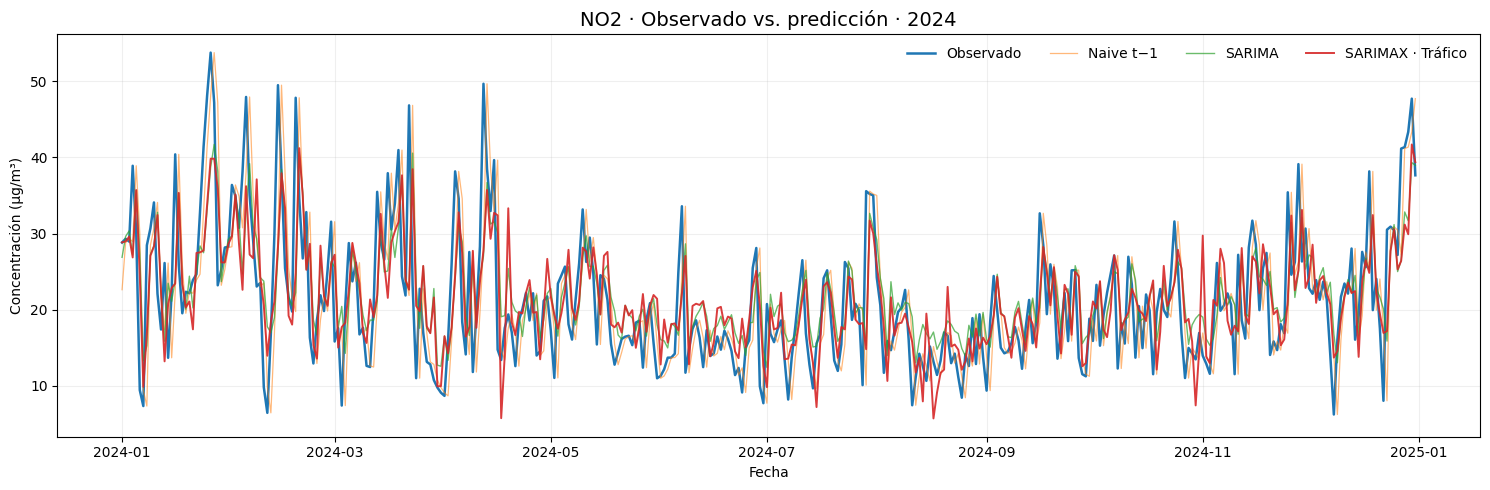

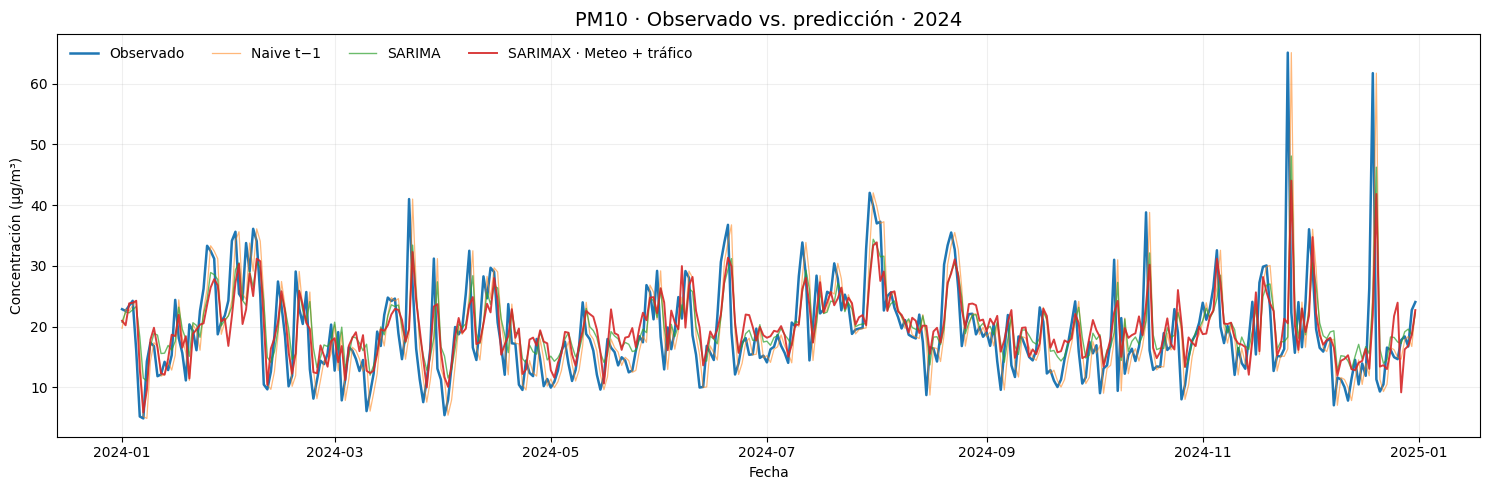

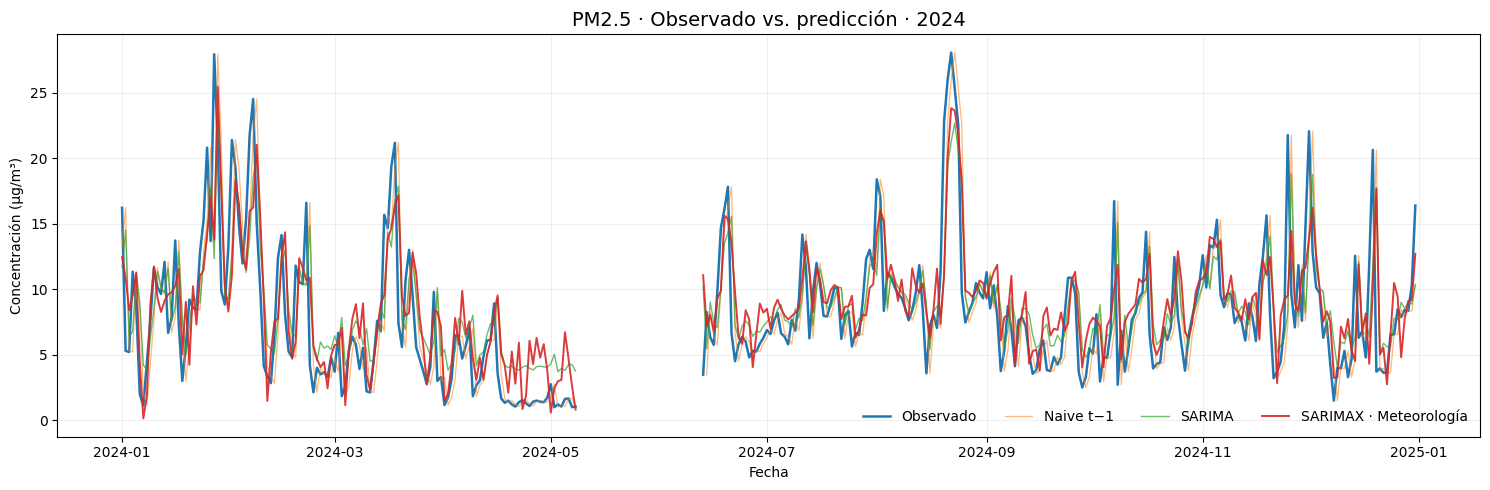

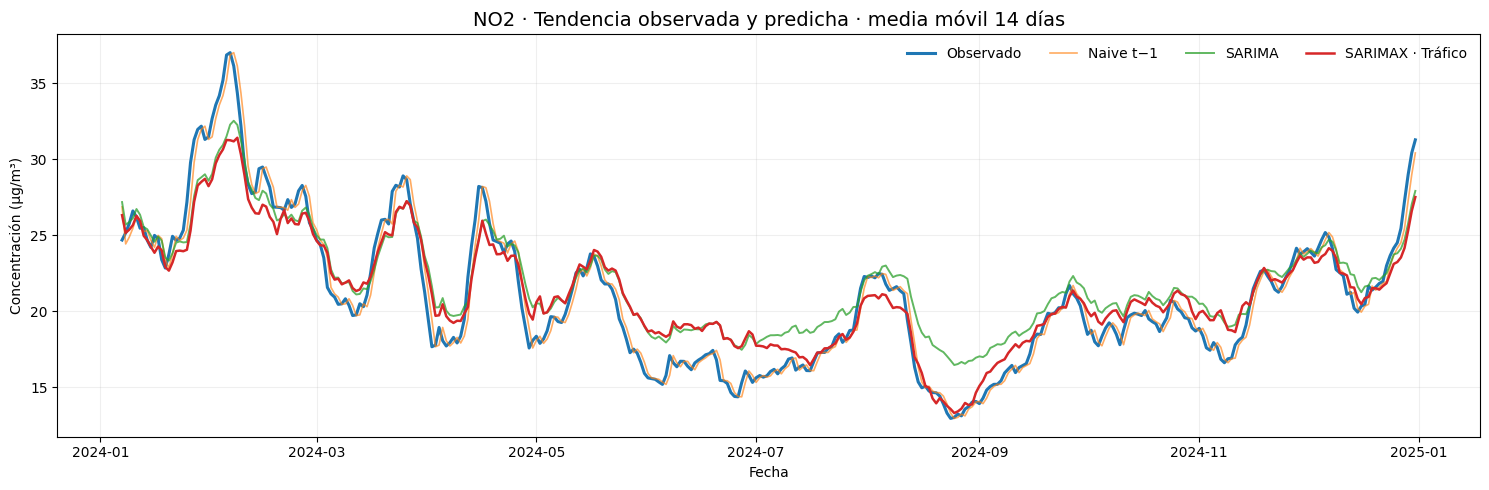

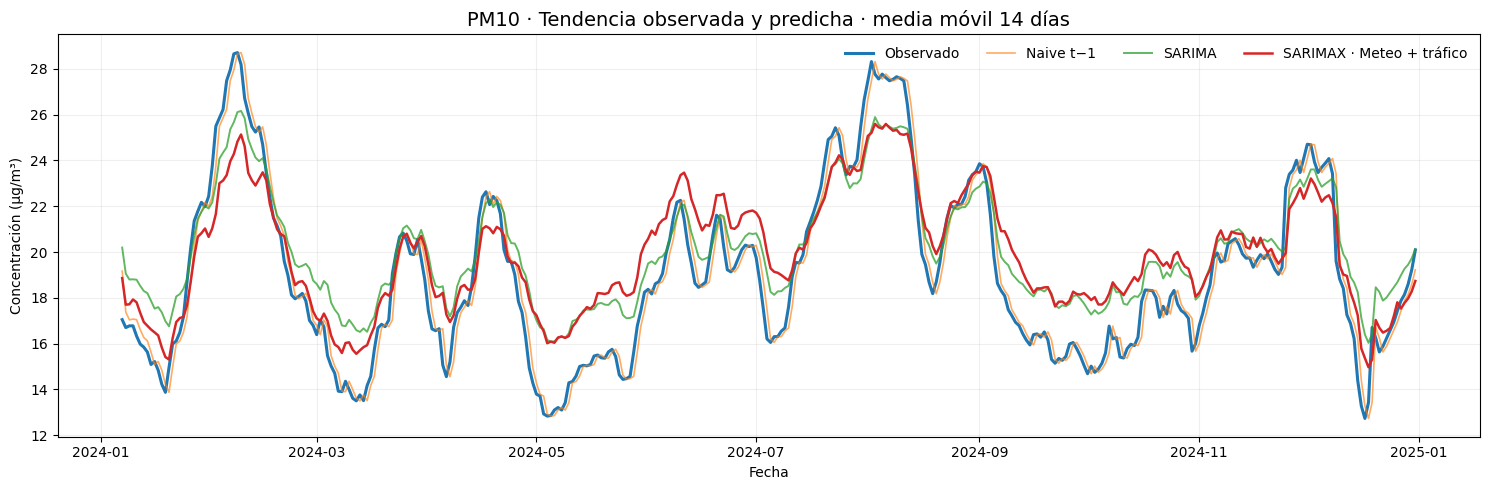

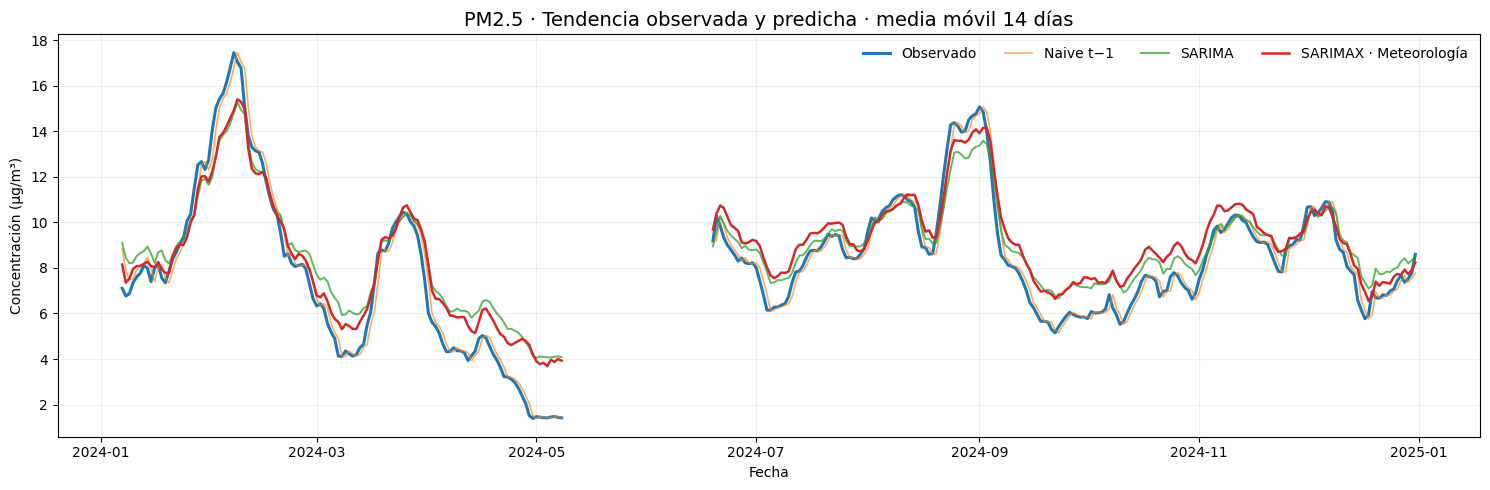

In [ ]:
# ============================================================
# 18. COMPARACIÓN VISUAL · OBSERVADO VS PREDICHO
# ============================================================


# ============================================================
# 18.1 CONFIGURACIÓN
# ============================================================

NOMBRES_SARIMAX = {
    "NO2": "SARIMAX · Tráfico",
    "PM10": "SARIMAX · Meteo + tráfico",
    "PM2.5": "SARIMAX · Meteorología"
}


# ============================================================
# 18.2 PREPARACIÓN DE SERIES PARA VISUALIZACIÓN
# ============================================================

series_plot = {}


for contaminante in CONTAMINANTES:

    # --------------------------------------------------------
    # Serie observada completa del test 2024
    # --------------------------------------------------------

    y_real = (
        train_test[
            contaminante
        ]["test"]
        .copy()
    )


    # --------------------------------------------------------
    # Predicciones rolling
    # --------------------------------------------------------

    pred_naive = (
        predicciones_rolling[
            contaminante
        ]["Naive t-1"]
        .copy()
    )

    pred_sarima = (
        predicciones_rolling[
            contaminante
        ]["SARIMA"]
        .copy()
    )

    pred_sarimax = (
        predicciones_rolling[
            contaminante
        ]["SARIMAX"]
        .copy()
    )


    # --------------------------------------------------------
    # DataFrame conjunto
    # --------------------------------------------------------

    df_plot = pd.DataFrame({
        "observado": y_real,
        "Naive_t1": pred_naive,
        "SARIMA": pred_sarima,
        "SARIMAX": pred_sarimax
    })


    # --------------------------------------------------------
    # Evitar unir visualmente periodos sin observación real
    #
    # Especialmente importante para PM2.5.
    # Las predicciones pueden existir para mantener el estado
    # del modelo, pero no deben representarse como si hubiese
    # concentración observada en esos días.
    # --------------------------------------------------------

    mask_sin_observacion = (
        df_plot[
            "observado"
        ].isna()
    )

    df_plot.loc[
        mask_sin_observacion,
        [
            "Naive_t1",
            "SARIMA",
            "SARIMAX"
        ]
    ] = np.nan


    series_plot[
        contaminante
    ] = df_plot


# ============================================================
# 18.3 SERIES DIARIAS · OBSERVADO VS PREDICHO
# ============================================================

for contaminante in CONTAMINANTES:

    df_plot = (
        series_plot[
            contaminante
        ]
        .copy()
    )


    fig, ax = plt.subplots(
        figsize=(15, 5)
    )


    # --------------------------------------------------------
    # Observado
    # --------------------------------------------------------

    ax.plot(
        df_plot.index,
        df_plot["observado"],
        linewidth=1.8,
        label="Observado"
    )


    # --------------------------------------------------------
    # Naive t-1
    # --------------------------------------------------------

    ax.plot(
        df_plot.index,
        df_plot["Naive_t1"],
        linewidth=0.9,
        alpha=0.55,
        label="Naive t−1"
    )


    # --------------------------------------------------------
    # SARIMA
    # --------------------------------------------------------

    ax.plot(
        df_plot.index,
        df_plot["SARIMA"],
        linewidth=1.0,
        alpha=0.70,
        label="SARIMA"
    )


    # --------------------------------------------------------
    # SARIMAX
    # --------------------------------------------------------

    ax.plot(
        df_plot.index,
        df_plot["SARIMAX"],
        linewidth=1.4,
        alpha=0.90,
        label=NOMBRES_SARIMAX[
            contaminante
        ]
    )


    # --------------------------------------------------------
    # Formato
    # --------------------------------------------------------

    ax.set_title(
        f"{contaminante} · Observado vs. predicción · 2024",
        fontsize=14
    )

    ax.set_xlabel(
        "Fecha"
    )

    ax.set_ylabel(
        "Concentración (µg/m³)"
    )

    ax.legend(
        frameon=False,
        ncol=4
    )

    ax.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 18.4 MEDIA MÓVIL DE 14 DÍAS
# ============================================================

for contaminante in CONTAMINANTES:

    df_plot = (
        series_plot[
            contaminante
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Media móvil
    # --------------------------------------------------------

    df_suave = (
        df_plot
        .rolling(
            window=14,
            min_periods=7
        )
        .mean()
    )


    # --------------------------------------------------------
    # Mantener discontinuidades donde no existe observación
    # real para evitar puentes artificiales.
    # --------------------------------------------------------

    mask_sin_observacion = (
        df_plot[
            "observado"
        ].isna()
    )

    df_suave.loc[
        mask_sin_observacion,
        :
    ] = np.nan


    # --------------------------------------------------------
    # Figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(15, 5)
    )


    # Observado
    ax.plot(
        df_suave.index,
        df_suave["observado"],
        linewidth=2.2,
        label="Observado"
    )


    # Naive
    ax.plot(
        df_suave.index,
        df_suave["Naive_t1"],
        linewidth=1.2,
        alpha=0.65,
        label="Naive t−1"
    )


    # SARIMA
    ax.plot(
        df_suave.index,
        df_suave["SARIMA"],
        linewidth=1.4,
        alpha=0.75,
        label="SARIMA"
    )


    # SARIMAX
    ax.plot(
        df_suave.index,
        df_suave["SARIMAX"],
        linewidth=1.8,
        label=NOMBRES_SARIMAX[
            contaminante
        ]
    )


    # --------------------------------------------------------
    # Formato
    # --------------------------------------------------------

    ax.set_title(
        f"{contaminante} · Tendencia observada y predicha · "
        "media móvil 14 días",
        fontsize=14
    )

    ax.set_xlabel(
        "Fecha"
    )

    ax.set_ylabel(
        "Concentración (µg/m³)"
    )

    ax.legend(
        frameon=False,
        ncol=4
    )

    ax.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.show()

### Resultado · Comparación visual de las predicciones

La comparación gráfica confirma los resultados obtenidos mediante las métricas de evaluación y permite identificar algunas características adicionales del comportamiento de los modelos.

#### NO₂

La serie de NO₂ presenta una elevada variabilidad diaria y numerosos cambios bruscos de concentración. Los modelos SARIMA y SARIMAX reproducen adecuadamente buena parte de esta dinámica, aunque tienden a amortiguar algunos de los episodios de mayor intensidad.

El modelo **SARIMAX con tráfico** mantiene una trayectoria próxima a las observaciones durante la mayor parte de 2024. La representación mediante media móvil de 14 días muestra además una buena reproducción de los principales cambios de tendencia, incluyendo el descenso hacia los meses estivales y el incremento observado hacia el final del año.

La dificultad para reproducir completamente algunos máximos diarios constituye una limitación del modelo, pero no impide que SARIMAX mejore de forma consistente al baseline en la evaluación cuantitativa.

#### PM10

En PM10 se observa igualmente una elevada correspondencia entre la evolución observada y las predicciones. Los mayores errores se concentran principalmente en episodios puntuales de concentración elevada, cuyos máximos son generalmente infraestimados por los modelos estadísticos.

La representación suavizada permite comprobar que **SARIMAX con meteorología y tráfico** reproduce satisfactoriamente la estructura temporal general, aunque presenta cierta tendencia al suavizado de máximos y mínimos.

Este comportamiento es coherente con la reducción del RMSE obtenida respecto al modelo de persistencia.

#### PM2.5

En PM2.5, el modelo **SARIMAX con meteorología** reproduce adecuadamente la evolución observada durante los periodos con información disponible y presenta una buena correspondencia con numerosos episodios de incremento y descenso de concentración.

Entre mayo y junio de 2024 existe un bloque sin observaciones. Este intervalo se representa explícitamente como una discontinuidad y no interviene en la evaluación de los modelos.

Fuera de dicho intervalo, la correspondencia entre las tendencias observada y predicha resulta especialmente clara, en consonancia con el mayor R² obtenido por SARIMAX entre los tres contaminantes analizados (R² = 0,537).

#### Interpretación conjunta

Los gráficos muestran que los modelos estadísticos capturan satisfactoriamente la dinámica temporal general de los tres contaminantes, aunque presentan mayores dificultades ante variaciones diarias abruptas y episodios extremos.

La combinación de dependencia temporal y variables exógenas mediante SARIMAX proporciona el mejor comportamiento global. No obstante, los resultados también evidencian que una mejora del error medio no implica una reproducción exacta de todos los máximos de contaminación.

En conjunto, la evidencia gráfica resulta coherente con las métricas obtenidas y respalda el uso de SARIMAX como modelo estadístico final para la predicción diaria actualizada.

## 19 · Diagnóstico de residuos de los modelos SARIMAX finales

Como comprobación final se analiza el comportamiento de los errores de predicción de los modelos SARIMAX seleccionados.

El diagnóstico se realiza sobre las predicciones *rolling one-step-ahead* de 2024 y comprende:

- distribución y magnitud de los residuos;
- inspección gráfica de su evolución temporal;
- función de autocorrelación (ACF);
- prueba de Ljung–Box en los retardos 7 y 14.

Los residuos se definen como la diferencia entre la concentración observada y la predicha:

\[
e_t = y_t - \hat{y}_t
\]

Un residuo medio próximo a cero indicaría ausencia de un sesgo sistemático importante. Por su parte, la prueba de Ljung–Box permite comprobar si permanece autocorrelación temporal significativa en los errores.

Este análisis se plantea como diagnóstico del modelo y no como una nueva etapa de selección o ajuste.

ESTADÍSTICOS DE LOS RESIDUOS · SARIMAX ROLLING
contaminante   n  media_residuo  mediana_residuo  std_residuo  MAE_residuo  RMSE_residuo
         NO2 366         -0.196           -0.733        6.849        5.239         6.843
        PM10 366         -0.855           -1.376        6.454        4.537         6.501
       PM2.5 330         -0.664           -0.898        3.406        2.558         3.465

PRUEBA DE LJUNG-BOX
contaminante  lag  LB_stat  p_value  autocorrelacion_significativa_5pct
         NO2    7   30.202   0.0001                                True
         NO2   14   38.520   0.0004                                True
        PM10    7   14.830   0.0382                                True
        PM10   14   18.595   0.1810                               False
       PM2.5    7    8.770   0.2696                               False
       PM2.5   14   16.314   0.2945                               False


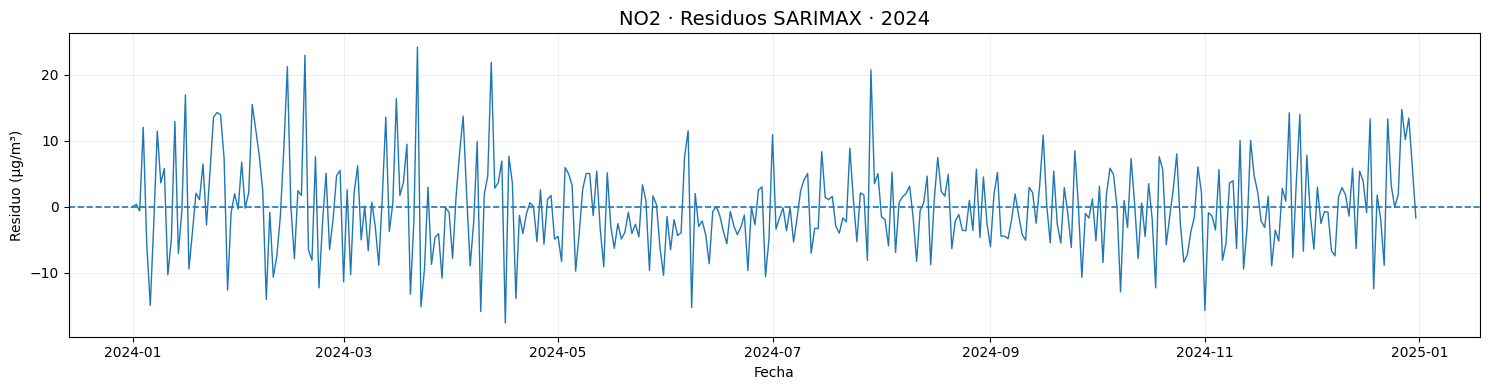

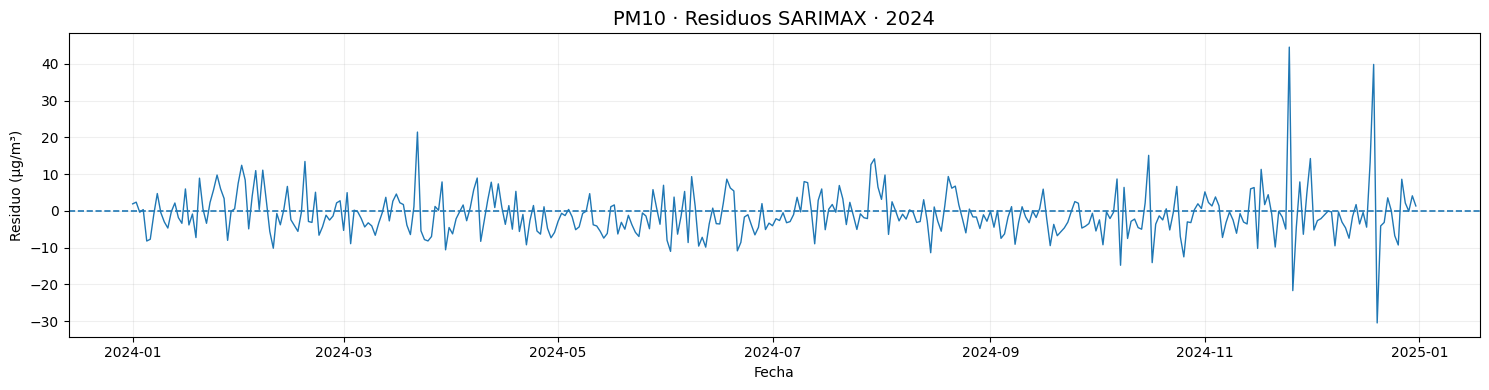

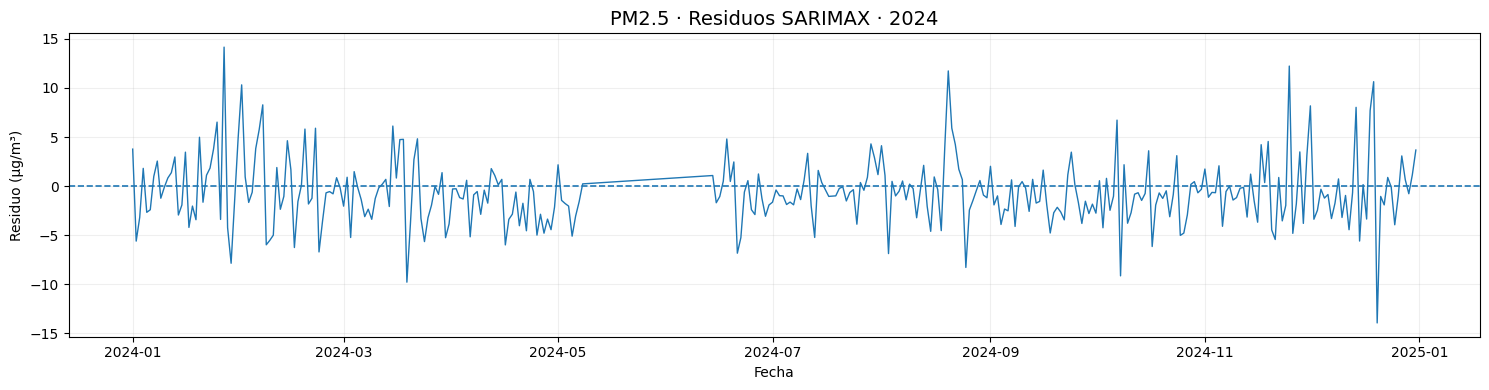

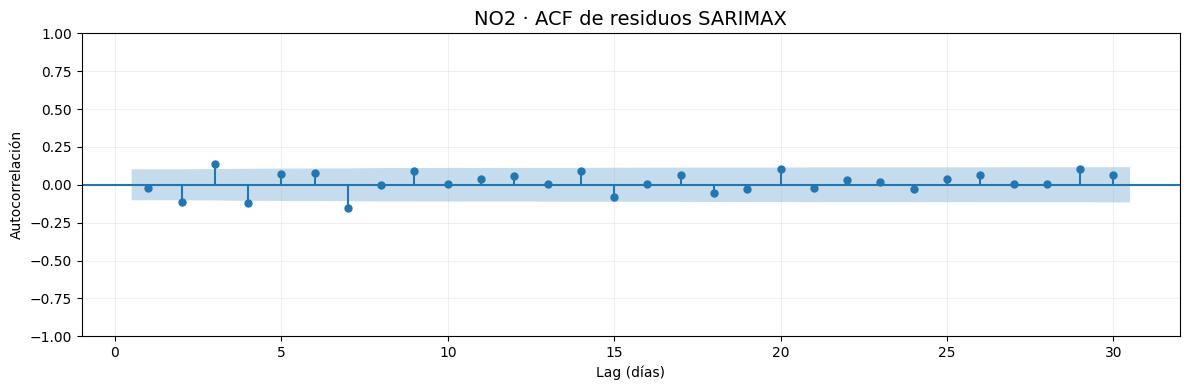

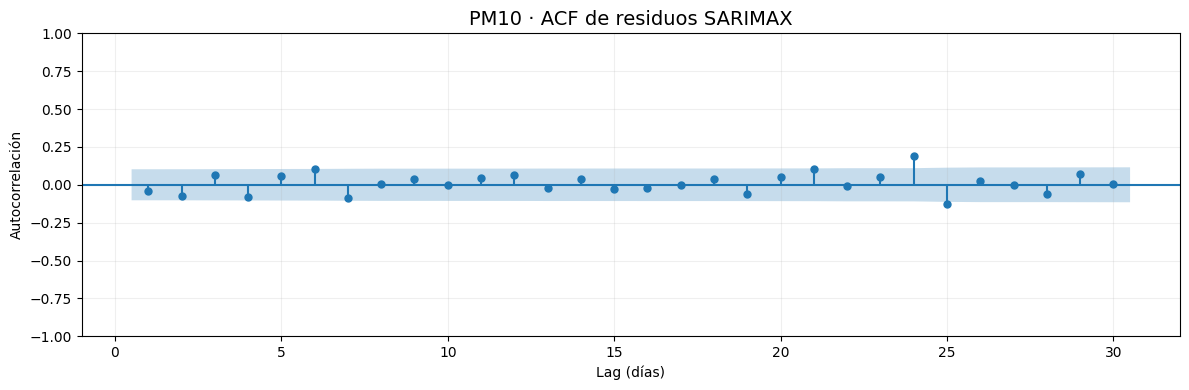

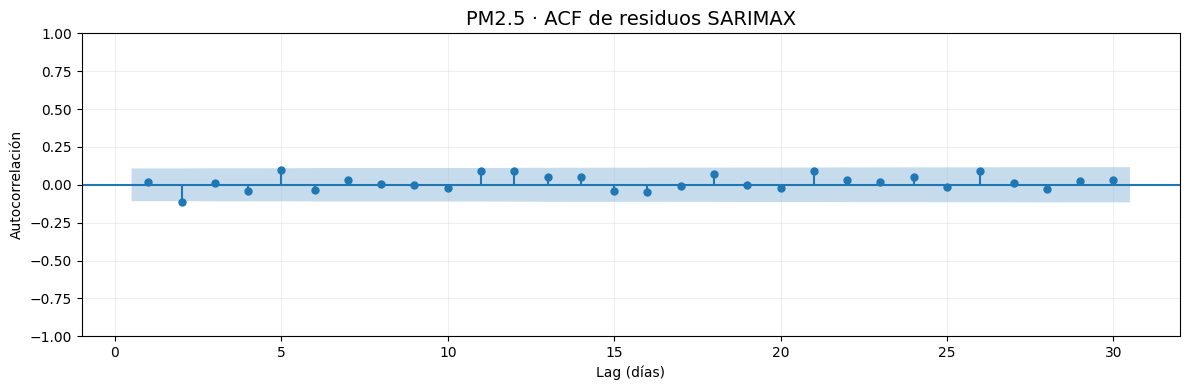


RESUMEN DEL DIAGNÓSTICO

NO2
  Media residuo = -0.196
  Desv. estándar = 6.849
  Ljung-Box lag 7: p = 0.0001 → autocorrelación residual significativa
  Ljung-Box lag 14: p = 0.0004 → autocorrelación residual significativa

PM10
  Media residuo = -0.855
  Desv. estándar = 6.454
  Ljung-Box lag 7: p = 0.0382 → autocorrelación residual significativa
  Ljung-Box lag 14: p = 0.1810 → sin evidencia de autocorrelación residual significativa

PM2.5
  Media residuo = -0.664
  Desv. estándar = 3.406
  Ljung-Box lag 7: p = 0.2696 → sin evidencia de autocorrelación residual significativa
  Ljung-Box lag 14: p = 0.2945 → sin evidencia de autocorrelación residual significativa


In [ ]:
# ============================================================
# 19. DIAGNÓSTICO DE RESIDUOS · SARIMAX FINALES
# ============================================================

resultados_residuos = []
residuos_sarimax = {}


# ============================================================
# 19.1 CÁLCULO DE RESIDUOS
# ============================================================

for contaminante in CONTAMINANTES:

    # Utilizamos exactamente las fechas comunes
    # empleadas en la comparación final
    df = (
        predicciones_comunes[
            contaminante
        ]
        .copy()
    )

    # Residuo = observado - predicho
    residuos = (
        df["observado"]
        - df["SARIMAX"]
    ).dropna()

    residuos_sarimax[
        contaminante
    ] = residuos


    # --------------------------------------------------------
    # Estadísticos descriptivos
    # --------------------------------------------------------

    resultados_residuos.append({

        "contaminante": contaminante,

        "n": len(residuos),

        "media_residuo":
            residuos.mean(),

        "mediana_residuo":
            residuos.median(),

        "std_residuo":
            residuos.std(),

        "MAE_residuo":
            residuos.abs().mean(),

        "RMSE_residuo":
            np.sqrt(
                np.mean(
                    residuos ** 2
                )
            )
    })


resultados_residuos = pd.DataFrame(
    resultados_residuos
)


print("=" * 90)
print("ESTADÍSTICOS DE LOS RESIDUOS · SARIMAX ROLLING")
print("=" * 90)

print(
    resultados_residuos
    .round({
        "media_residuo": 3,
        "mediana_residuo": 3,
        "std_residuo": 3,
        "MAE_residuo": 3,
        "RMSE_residuo": 3
    })
    .to_string(
        index=False
    )
)


# ============================================================
# 19.2 PRUEBA DE LJUNG-BOX
# ============================================================

resultados_ljungbox = []


for contaminante in CONTAMINANTES:

    residuos = (
        residuos_sarimax[
            contaminante
        ]
        .dropna()
    )


    lb = acorr_ljungbox(
        residuos,
        lags=[7, 14],
        return_df=True
    )


    for lag in [7, 14]:

        resultados_ljungbox.append({

            "contaminante":
                contaminante,

            "lag":
                lag,

            "LB_stat":
                lb.loc[
                    lag,
                    "lb_stat"
                ],

            "p_value":
                lb.loc[
                    lag,
                    "lb_pvalue"
                ],

            "autocorrelacion_significativa_5pct":
                (
                    lb.loc[
                        lag,
                        "lb_pvalue"
                    ] < 0.05
                )
        })


resultados_ljungbox = pd.DataFrame(
    resultados_ljungbox
)


print("\n" + "=" * 90)
print("PRUEBA DE LJUNG-BOX")
print("=" * 90)

print(
    resultados_ljungbox
    .round({
        "LB_stat": 3,
        "p_value": 4
    })
    .to_string(
        index=False
    )
)


# ============================================================
# 19.3 EVOLUCIÓN TEMPORAL DE LOS RESIDUOS
# ============================================================

for contaminante in CONTAMINANTES:

    residuos = (
        residuos_sarimax[
            contaminante
        ]
    )


    fig, ax = plt.subplots(
        figsize=(15, 4)
    )


    ax.plot(
        residuos.index,
        residuos.values,
        linewidth=1.0
    )


    # Línea de referencia = error cero
    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=1.2
    )


    ax.set_title(
        f"{contaminante} · Residuos SARIMAX · 2024",
        fontsize=14
    )

    ax.set_xlabel(
        "Fecha"
    )

    ax.set_ylabel(
        "Residuo (µg/m³)"
    )

    ax.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 19.4 AUTOCORRELACIÓN DE LOS RESIDUOS
# ============================================================

for contaminante in CONTAMINANTES:

    residuos = (
        residuos_sarimax[
            contaminante
        ]
        .dropna()
    )


    fig, ax = plt.subplots(
        figsize=(12, 4)
    )


    plot_acf(
        residuos,
        lags=30,
        zero=False,
        ax=ax
    )


    ax.set_title(
        f"{contaminante} · ACF de residuos SARIMAX",
        fontsize=14
    )

    ax.set_xlabel(
        "Lag (días)"
    )

    ax.set_ylabel(
        "Autocorrelación"
    )

    ax.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 19.5 RESUMEN AUTOMÁTICO
# ============================================================

print("\n" + "=" * 90)
print("RESUMEN DEL DIAGNÓSTICO")
print("=" * 90)


for contaminante in CONTAMINANTES:

    fila_res = (
        resultados_residuos[
            resultados_residuos[
                "contaminante"
            ] == contaminante
        ]
        .iloc[0]
    )


    lb_cont = (
        resultados_ljungbox[
            resultados_ljungbox[
                "contaminante"
            ] == contaminante
        ]
    )


    print(
        f"\n{contaminante}"
    )

    print(
        f"  Media residuo = "
        f"{fila_res['media_residuo']:.3f}"
    )

    print(
        f"  Desv. estándar = "
        f"{fila_res['std_residuo']:.3f}"
    )


    for _, fila_lb in lb_cont.iterrows():

        interpretacion = (
            "autocorrelación residual significativa"
            if fila_lb[
                "autocorrelacion_significativa_5pct"
            ]
            else
            "sin evidencia de autocorrelación residual significativa"
        )

        print(
            f"  Ljung-Box lag {int(fila_lb['lag'])}: "
            f"p = {fila_lb['p_value']:.4f} → "
            f"{interpretacion}"
        )

### Resultado · Diagnóstico de residuos

El diagnóstico de los residuos permite evaluar qué parte de la estructura temporal permanece sin explicar tras la aplicación de los modelos SARIMAX seleccionados.

#### Magnitud y sesgo de los residuos

Los residuos presentan medias relativamente próximas a cero en los tres contaminantes:

| Contaminante | n | Media | Mediana | Desv. estándar | MAE | RMSE |
|---|---:|---:|---:|---:|---:|---:|
| NO₂ | 366 | −0,196 | −0,733 | 6,849 | 5,239 | 6,843 |
| PM10 | 366 | −0,855 | −1,376 | 6,454 | 4,537 | 6,501 |
| PM2.5 | 330 | −0,664 | −0,898 | 3,406 | 2,558 | 3,465 |

Las medias negativas indican una ligera tendencia global a la **sobreestimación** de las concentraciones, dado que el residuo se ha definido como observado menos predicho. No obstante, el sesgo medio es reducido en comparación con la dispersión de los errores.

En **NO₂**, la media residual es de −0,196 µg/m³, prácticamente centrada en cero. En **PM10** y **PM2.5** el sesgo negativo es algo mayor, con −0,855 y −0,664 µg/m³ respectivamente, aunque continúa siendo pequeño frente a la variabilidad residual.

Las representaciones temporales muestran además que los errores de mayor magnitud se concentran principalmente en episodios puntuales y cambios bruscos de concentración. Este comportamiento es especialmente visible en PM10, donde algunos de los mayores errores coinciden con episodios extremos registrados hacia el final de 2024.

#### Autocorrelación residual

La inspección de las funciones de autocorrelación muestra coeficientes generalmente pequeños, aunque la prueba de Ljung–Box permite identificar diferencias entre contaminantes.

| Contaminante | Lag | p-valor | Interpretación |
|---|---:|---:|---|
| NO₂ | 7 | 0,0001 | Autocorrelación residual significativa |
| NO₂ | 14 | 0,0004 | Autocorrelación residual significativa |
| PM10 | 7 | 0,0382 | Autocorrelación residual significativa |
| PM10 | 14 | 0,1810 | No significativa |
| PM2.5 | 7 | 0,2696 | No significativa |
| PM2.5 | 14 | 0,2945 | No significativa |

En **NO₂**, la hipótesis de independencia de los residuos se rechaza tanto a 7 como a 14 días. Por tanto, aunque SARIMAX mejora claramente las métricas predictivas respecto al baseline y a SARIMA, permanece cierta dependencia temporal que el modelo no captura completamente.

En **PM10**, se detecta autocorrelación residual significativa a 7 días (p = 0,0382), pero no a 14 días (p = 0,1810). La evidencia de estructura residual es, por tanto, más limitada que en NO₂.

En **PM2.5**, los resultados son especialmente favorables: no se detecta autocorrelación residual significativa ni a 7 días (p = 0,2696) ni a 14 días (p = 0,2945). Esto es coherente con el mejor comportamiento predictivo relativo obtenido por este modelo, que alcanza un R² de 0,537 en la evaluación sobre fechas comunes.

#### Interpretación conjunta

El diagnóstico muestra que los modelos SARIMAX finales presentan un sesgo medio reducido y mejoran de forma consistente la predicción respecto al modelo de persistencia. Sin embargo, la independencia completa de los errores no se alcanza en todos los casos.

La autocorrelación residual observada en NO₂ y, en menor medida, en PM10 constituye una **limitación del modelo** y sugiere que parte de la dinámica temporal de estos contaminantes permanece sin explicar. En PM2.5, por el contrario, no se identifica evidencia estadísticamente significativa de dependencia residual en los retardos analizados.

Estos resultados no modifican la selección de SARIMAX como mejor aproximación estadística entre las evaluadas, ya que continúa obteniendo el menor error predictivo para los tres contaminantes. El diagnóstico permite, no obstante, delimitar con mayor precisión sus fortalezas y limitaciones.

> **Conclusión del diagnóstico:** SARIMAX mejora de forma consistente la predicción diaria y presenta residuos con sesgo medio reducido, aunque conserva estructura temporal residual en NO₂ y parcialmente en PM10. La modelización de episodios extremos y de la dependencia temporal restante constituye una posible línea de mejora futura.

## 20 · Análisis temporal del periodo COVID y post-COVID

La pandemia de COVID-19 produjo una alteración excepcional de la movilidad y de la actividad urbana, por lo que constituye un periodo de especial interés dentro del análisis temporal de la calidad del aire.

Se realiza una comparación descriptiva entre dos periodos:

- **COVID:** 2020–2021.
- **Post-COVID:** 2022–2024.

El análisis se limita a **NO₂ y PM10**, contaminantes para los que existe una cobertura temporal suficientemente consistente durante ambos periodos. PM2.5 se excluye de esta comparación debido a que su serie disponible comienza a finales de 2021 y no permite caracterizar adecuadamente el periodo COVID.

Para cada contaminante se comparan:

- número de observaciones disponibles;
- concentración media y mediana;
- desviación estándar;
- percentiles 25 y 75;
- cambio porcentual de la concentración media entre ambos periodos;
- evolución mensual de las concentraciones.

La comparación tiene carácter **descriptivo**. Las diferencias observadas permiten caracterizar el comportamiento temporal de la contaminación durante ambos periodos, pero no deben interpretarse como una estimación causal del efecto de la pandemia, ya que otros factores meteorológicos, estacionales y urbanos también pueden contribuir a las variaciones registradas.

El año 2019 no se incorpora como periodo pre-COVID de referencia debido a la menor completitud de las series utilizada en este análisis, evitando introducir una comparación temporal basada en coberturas heterogéneas.

COVID VS POST-COVID · ESTADÍSTICOS DESCRIPTIVOS
contaminante              periodo    n  media  mediana   std   p25   p75
         NO2      COVID 2020-2021  714  23.65    21.70 10.16 16.00 30.16
         NO2 Post-COVID 2022-2024 1096  23.46    21.93  9.30 16.36 28.58
        PM10      COVID 2020-2021  714  20.50    19.61  9.56 14.79 23.99
        PM10 Post-COVID 2022-2024 1096  21.61    20.21  8.35 16.04 26.09

CAMBIO RELATIVO · COVID → POST-COVID
contaminante  media_COVID  media_postCOVID  cambio_media_pct  mediana_COVID  mediana_postCOVID  cambio_mediana_pct
         NO2        23.65            23.46             -0.81          21.70              21.93                1.06
        PM10        20.50            21.61              5.41          19.61              20.21                3.08


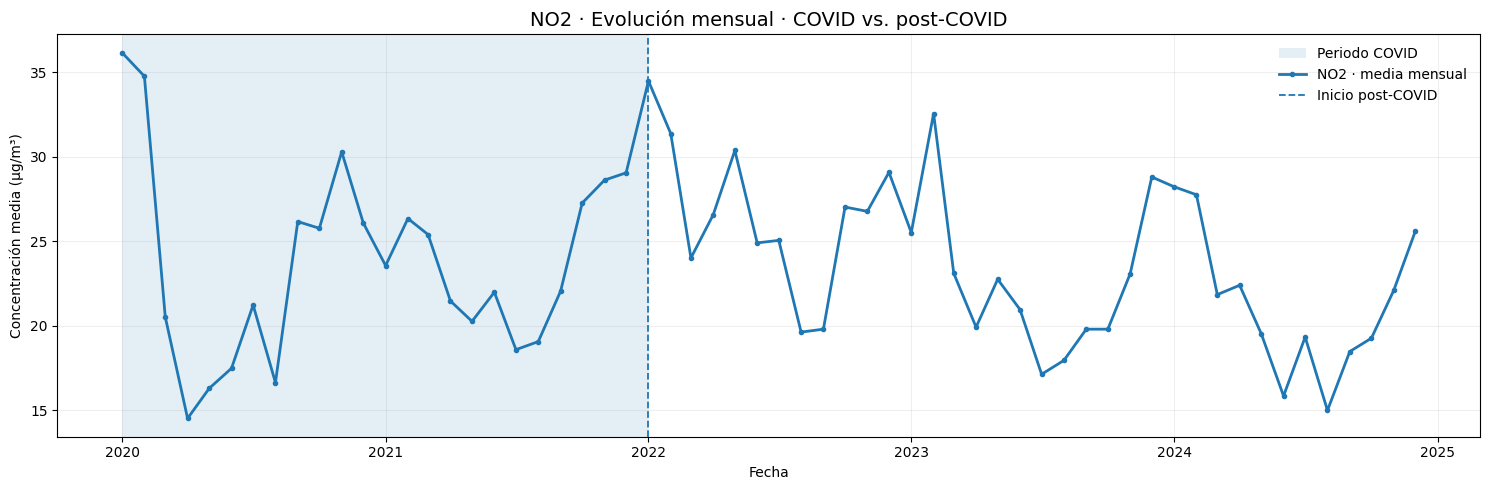

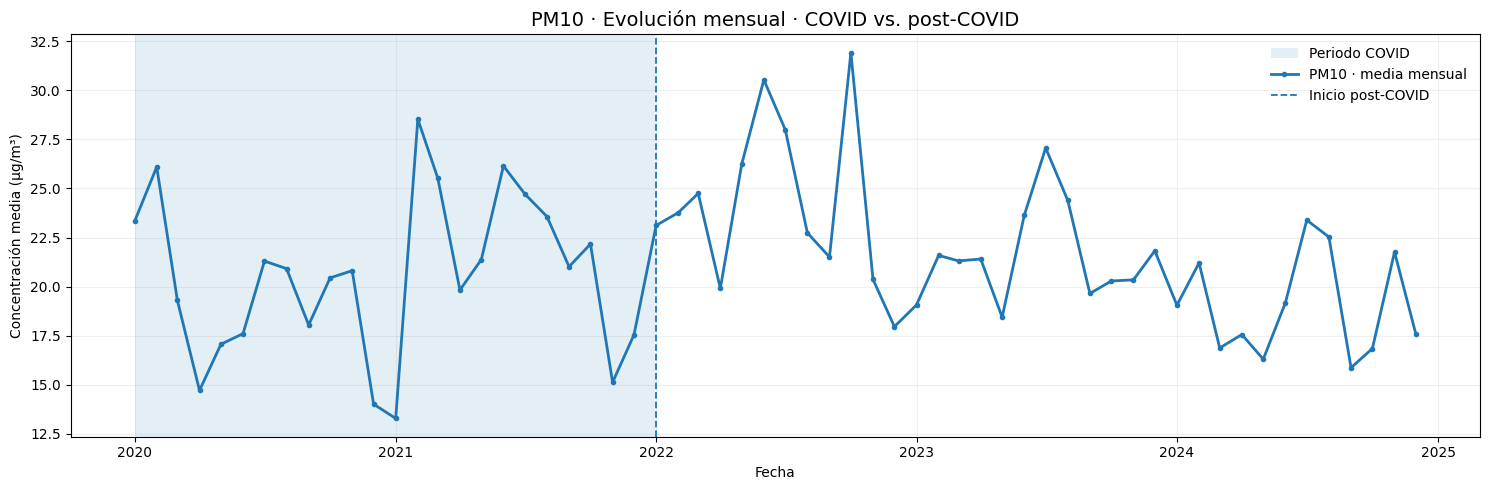

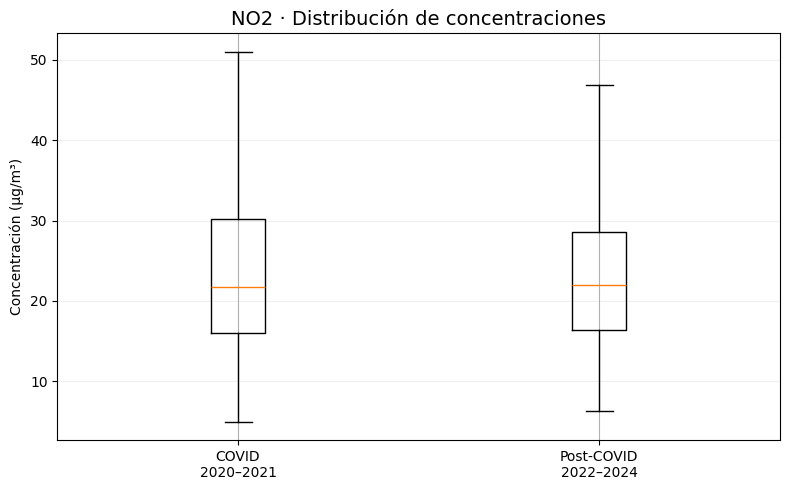

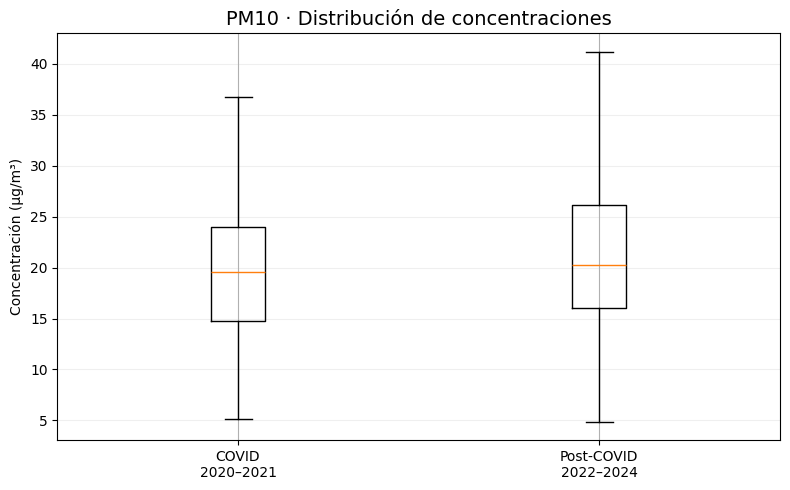


RESUMEN · COVID VS POST-COVID

NO2: reducción de la concentración media del 0.81% en post-COVID respecto a COVID.

PM10: aumento de la concentración media del 5.41% en post-COVID respecto a COVID.


In [ ]:
# ============================================================
# 20. ANÁLISIS COVID VS POST-COVID
# ============================================================

CONTAMINANTES_COVID = [
    "NO2",
    "PM10"
]

PERIODOS_COVID = {
    "COVID 2020-2021": (
        "2020-01-01",
        "2021-12-31"
    ),
    "Post-COVID 2022-2024": (
        "2022-01-01",
        "2024-12-31"
    )
}


# ============================================================
# 20.1 ESTADÍSTICOS DESCRIPTIVOS
# ============================================================

resultados_covid = []


for contaminante in CONTAMINANTES_COVID:

    serie = (
        series_modelado[
            contaminante
        ]
        .copy()
    )

    for periodo, (inicio, fin) in PERIODOS_COVID.items():

        datos = (
            serie
            .loc[inicio:fin]
            .dropna()
        )

        resultados_covid.append({

            "contaminante":
                contaminante,

            "periodo":
                periodo,

            "n":
                len(datos),

            "media":
                datos.mean(),

            "mediana":
                datos.median(),

            "std":
                datos.std(),

            "p25":
                datos.quantile(0.25),

            "p75":
                datos.quantile(0.75)
        })


resultados_covid = pd.DataFrame(
    resultados_covid
)


print("=" * 90)
print("COVID VS POST-COVID · ESTADÍSTICOS DESCRIPTIVOS")
print("=" * 90)

print(
    resultados_covid
    .round({
        "media": 2,
        "mediana": 2,
        "std": 2,
        "p25": 2,
        "p75": 2
    })
    .to_string(
        index=False
    )
)


# ============================================================
# 20.2 CAMBIO PORCENTUAL COVID → POST-COVID
# ============================================================

cambios_covid = []


for contaminante in CONTAMINANTES_COVID:

    tabla_cont = (
        resultados_covid[
            resultados_covid[
                "contaminante"
            ] == contaminante
        ]
        .set_index(
            "periodo"
        )
    )


    media_covid = tabla_cont.loc[
        "COVID 2020-2021",
        "media"
    ]

    media_post = tabla_cont.loc[
        "Post-COVID 2022-2024",
        "media"
    ]


    mediana_covid = tabla_cont.loc[
        "COVID 2020-2021",
        "mediana"
    ]

    mediana_post = tabla_cont.loc[
        "Post-COVID 2022-2024",
        "mediana"
    ]


    cambio_media = (
        100
        * (
            media_post
            - media_covid
        )
        / media_covid
    )


    cambio_mediana = (
        100
        * (
            mediana_post
            - mediana_covid
        )
        / mediana_covid
    )


    cambios_covid.append({

        "contaminante":
            contaminante,

        "media_COVID":
            media_covid,

        "media_postCOVID":
            media_post,

        "cambio_media_pct":
            cambio_media,

        "mediana_COVID":
            mediana_covid,

        "mediana_postCOVID":
            mediana_post,

        "cambio_mediana_pct":
            cambio_mediana
    })


cambios_covid = pd.DataFrame(
    cambios_covid
)


print("\n" + "=" * 90)
print("CAMBIO RELATIVO · COVID → POST-COVID")
print("=" * 90)

print(
    cambios_covid
    .round({
        "media_COVID": 2,
        "media_postCOVID": 2,
        "cambio_media_pct": 2,
        "mediana_COVID": 2,
        "mediana_postCOVID": 2,
        "cambio_mediana_pct": 2
    })
    .to_string(
        index=False
    )
)


# ============================================================
# 20.3 EVOLUCIÓN MENSUAL
# ============================================================

series_mensuales_covid = {}


for contaminante in CONTAMINANTES_COVID:

    serie = (
        series_modelado[
            contaminante
        ]
        .loc[
            "2020-01-01":
            "2024-12-31"
        ]
        .copy()
    )


    mensual = (
        serie
        .resample("MS")
        .mean()
    )


    series_mensuales_covid[
        contaminante
    ] = mensual


# ============================================================
# 20.4 GRÁFICO TEMPORAL
# ============================================================

for contaminante in CONTAMINANTES_COVID:

    mensual = (
        series_mensuales_covid[
            contaminante
        ]
    )


    fig, ax = plt.subplots(
        figsize=(15, 5)
    )


    # --------------------------------------------------------
    # Periodo COVID
    # --------------------------------------------------------

    ax.axvspan(
        pd.Timestamp("2020-01-01"),
        pd.Timestamp("2021-12-31"),
        alpha=0.12,
        label="Periodo COVID"
    )


    # --------------------------------------------------------
    # Concentración mensual
    # --------------------------------------------------------

    ax.plot(
        mensual.index,
        mensual.values,
        linewidth=2.0,
        marker="o",
        markersize=3,
        label=f"{contaminante} · media mensual"
    )


    # --------------------------------------------------------
    # Separación COVID / post-COVID
    # --------------------------------------------------------

    ax.axvline(
        pd.Timestamp("2022-01-01"),
        linestyle="--",
        linewidth=1.3,
        label="Inicio post-COVID"
    )


    ax.set_title(
        f"{contaminante} · Evolución mensual · "
        "COVID vs. post-COVID",
        fontsize=14
    )

    ax.set_xlabel(
        "Fecha"
    )

    ax.set_ylabel(
        "Concentración media (µg/m³)"
    )

    ax.legend(
        frameon=False
    )

    ax.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 20.5 COMPARACIÓN DIRECTA DE DISTRIBUCIONES
# ============================================================

for contaminante in CONTAMINANTES_COVID:

    serie = (
        series_modelado[
            contaminante
        ]
        .copy()
    )


    covid = (
        serie
        .loc[
            "2020-01-01":
            "2021-12-31"
        ]
        .dropna()
    )


    post = (
        serie
        .loc[
            "2022-01-01":
            "2024-12-31"
        ]
        .dropna()
    )


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )


    ax.boxplot(
        [
            covid.values,
            post.values
        ],
        tick_labels=[
            "COVID\n2020–2021",
            "Post-COVID\n2022–2024"
        ],
        showfliers=False
    )


    ax.set_title(
        f"{contaminante} · Distribución de concentraciones",
        fontsize=14
    )

    ax.set_ylabel(
        "Concentración (µg/m³)"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 20.6 RESUMEN
# ============================================================

print("\n" + "=" * 90)
print("RESUMEN · COVID VS POST-COVID")
print("=" * 90)


for _, fila in cambios_covid.iterrows():

    contaminante = fila[
        "contaminante"
    ]

    cambio = fila[
        "cambio_media_pct"
    ]


    if cambio > 0:

        direccion = "aumento"

    elif cambio < 0:

        direccion = "reducción"

    else:

        direccion = "sin cambio"


    print(
        f"\n{contaminante}: "
        f"{direccion} de la concentración media "
        f"del {abs(cambio):.2f}% "
        f"en post-COVID respecto a COVID."
    )

### Resultado · Comparación COVID y post-COVID

La comparación entre el periodo COVID (2020–2021) y el periodo post-COVID (2022–2024) muestra comportamientos diferenciados para NO₂ y PM10.

#### NO₂

La concentración media de NO₂ durante el periodo COVID fue de **23,65 µg/m³**, frente a **23,46 µg/m³** en el periodo post-COVID, lo que representa una variación de apenas **−0,81 %**.

Las medianas presentan un comportamiento igualmente estable, pasando de **21,70 a 21,93 µg/m³** (+1,06 %). Por tanto, al considerar conjuntamente ambos periodos, no se observa una diferencia sustancial en el nivel central de las concentraciones de NO₂.

Sin embargo, la evolución mensual aporta información que queda parcialmente oculta en los estadísticos agregados. Durante los primeros meses de 2020 se observa una **caída muy pronunciada de las concentraciones**, seguida posteriormente por una recuperación progresiva. Además, el periodo COVID presenta una mayor dispersión (σ = **10,16 µg/m³**) que el periodo posterior (σ = **9,30 µg/m³**).

Por tanto, el principal rasgo observado para NO₂ no es una reducción uniforme durante todo 2020–2021, sino una **alteración temporal intensa y transitoria de su dinámica**, especialmente visible durante 2020.

#### PM10

PM10 presenta un comportamiento diferente. La concentración media aumenta de **20,50 µg/m³** durante 2020–2021 a **21,61 µg/m³** durante 2022–2024, equivalente a un incremento del **5,41 %**.

La mediana aumenta igualmente de **19,61 a 20,21 µg/m³** (+3,08 %), mientras que el rango intercuartílico se desplaza hacia concentraciones ligeramente superiores durante el periodo post-COVID.

La evolución mensual muestra, no obstante, una elevada variabilidad durante ambos periodos y episodios de concentraciones elevadas tanto durante como después de la pandemia. PM10 no reproduce, por tanto, el patrón temporal observado en NO₂.

#### PM2.5

PM2.5 no se incorpora a la comparación COVID/post-COVID debido a su cobertura temporal. La serie disponible comienza en **noviembre de 2021**, por lo que no existe información suficiente para caracterizar de forma representativa el periodo COVID 2020–2021.

Comparar las últimas semanas de 2021 con el periodo completo 2022–2024 introduciría una fuerte asimetría temporal y podría generar conclusiones poco robustas. Por este motivo, PM2.5 se mantiene en el resto de la modelización temporal, pero se excluye específicamente de este análisis comparativo.

#### Interpretación conjunta

Los resultados muestran que la alteración temporal observada durante el periodo COVID **no fue homogénea entre contaminantes**.

El **NO₂** presenta una caída especialmente visible durante los primeros meses de 2020 y una recuperación posterior, de manera que este episodio queda parcialmente diluido cuando se comparan las medias agregadas de 2020–2021 y 2022–2024.

Por el contrario, **PM10 presenta concentraciones medias ligeramente superiores en el periodo post-COVID**, evidenciando una dinámica diferente y compatible con la influencia de fuentes y procesos más diversos.

Estos resultados ponen de manifiesto la importancia de analizar la **evolución temporal completa y no únicamente las medias de periodos amplios**, ya que una perturbación intensa pero transitoria puede quedar oculta al agregar varios años.

Finalmente, esta comparación debe interpretarse como un **análisis descriptivo temporal y no causal**. Las diferencias observadas pueden estar condicionadas simultáneamente por cambios en movilidad, meteorología, estacionalidad y otras fuentes de emisión, por lo que no pueden atribuirse exclusivamente a las restricciones asociadas a la pandemia.

## 21 · Exportación de resultados

Una vez completada la modelización y el análisis temporal, se exportan los principales resultados del notebook para su reutilización en las siguientes fases del proyecto.

El objetivo es desacoplar la fase de modelización de la capa de visualización, de modo que el dashboard **Breathe Barcelona** pueda consumir directamente resultados previamente calculados sin necesidad de volver a ajustar los modelos.

Se exportan los siguientes conjuntos de información:

1. **Métricas finales de validación rolling**, con la comparación homogénea entre Naive t−1, SARIMA y SARIMAX.
2. **Predicciones correspondientes a 2024**, incluyendo valores observados y estimaciones de los diferentes modelos.
3. **Diagnóstico de residuos** de los modelos SARIMAX seleccionados.
4. **Resultados de las pruebas de Ljung–Box** aplicadas a los residuos.
5. **Comparación COVID/post-COVID**, con los estadísticos descriptivos y cambios relativos obtenidos para NO₂ y PM10.

Los archivos se almacenan en el directorio `13_Modelos_Series_Temporales`, que constituye la salida persistente de este notebook y servirá posteriormente como fuente de datos para las visualizaciones y el dashboard.

In [ ]:
# ============================================================
# 21. EXPORTACIÓN DE RESULTADOS
# ============================================================

# ------------------------------------------------------------
# 21.1 Directorio de salida
# ------------------------------------------------------------

RUTA_SALIDA = Path(
    "/content/drive/MyDrive/TFM/13_Modelos_Series_Temporales"
)

RUTA_SALIDA.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 90)
print("EXPORTACIÓN DE RESULTADOS")
print("=" * 90)

print(
    f"\nDirectorio de salida:\n{RUTA_SALIDA}"
)


# ============================================================
# 21.2 MÉTRICAS FINALES · ROLLING ONE-STEP-AHEAD
# ============================================================

metricas_export = resultados_comunes.copy()

MAPA_MODELOS = {
    ("NO2", "Baseline"): "Naive t-1",
    ("NO2", "SARIMA"): "SARIMA_AR1_SAR1",
    ("NO2", "SARIMAX"): "SARIMAX_Trafico",

    ("PM10", "Baseline"): "Naive t-1",
    ("PM10", "SARIMA"): "ARMA11",
    ("PM10", "SARIMAX"): "SARIMAX_Meteo_Trafico",

    ("PM2.5", "Baseline"): "Naive t-1",
    ("PM2.5", "SARIMA"): "SARIMA_ARMA_SAR",
    ("PM2.5", "SARIMAX"): "SARIMAX_Meteorologia"
}

metricas_export["modelo"] = [
    MAPA_MODELOS[
        (fila["contaminante"], fila["familia"])
    ]
    for _, fila in metricas_export.iterrows()
]

metricas_export = metricas_export[
    [
        "contaminante",
        "familia",
        "modelo",
        "n_test",
        "MAE",
        "RMSE",
        "R2",
        "mejora_MAE_vs_naive_pct",
        "mejora_RMSE_vs_naive_pct"
    ]
]

ruta_metricas = (
    RUTA_SALIDA
    / "LF04_metricas_modelos_rolling.csv"
)

metricas_export.to_csv(
    ruta_metricas,
    index=False
)


# ============================================================
# 21.3 PREDICCIONES · 2024
# ============================================================

lista_predicciones = []

for contaminante in CONTAMINANTES:

    y_real = (
        train_test[
            contaminante
        ]["test"]
        .copy()
    )

    pred_naive = (
        predicciones_rolling[
            contaminante
        ]["Naive t-1"]
        .copy()
    )

    pred_sarima = (
        predicciones_rolling[
            contaminante
        ]["SARIMA"]
        .copy()
    )

    pred_sarimax = (
        predicciones_rolling[
            contaminante
        ]["SARIMAX"]
        .copy()
    )

    df_pred = pd.DataFrame({

        "fecha":
            y_real.index,

        "contaminante":
            contaminante,

        "observado":
            y_real.values,

        "naive_t1":
            pred_naive
            .reindex(y_real.index)
            .values,

        "sarima":
            pred_sarima
            .reindex(y_real.index)
            .values,

        "sarimax":
            pred_sarimax
            .reindex(y_real.index)
            .values
    })

    # Indicador explícito de disponibilidad
    # del valor observado.
    df_pred[
        "dato_observado_disponible"
    ] = (
        df_pred[
            "observado"
        ]
        .notna()
    )

    lista_predicciones.append(
        df_pred
    )


predicciones_export = pd.concat(
    lista_predicciones,
    ignore_index=True
)

ruta_predicciones = (
    RUTA_SALIDA
    / "LF04_predicciones_rolling_2024.csv"
)

predicciones_export.to_csv(
    ruta_predicciones,
    index=False
)


# ============================================================
# 21.4 DIAGNÓSTICO DE RESIDUOS
# ============================================================

residuos_export = (
    resultados_residuos
    .copy()
)

ruta_residuos = (
    RUTA_SALIDA
    / "LF04_diagnostico_residuos.csv"
)

residuos_export.to_csv(
    ruta_residuos,
    index=False
)


# ============================================================
# 21.5 PRUEBAS LJUNG-BOX
# ============================================================

ljungbox_export = (
    resultados_ljungbox
    .copy()
)

ruta_ljungbox = (
    RUTA_SALIDA
    / "LF04_ljungbox_residuos.csv"
)

ljungbox_export.to_csv(
    ruta_ljungbox,
    index=False
)


# ============================================================
# 21.6 RESULTADOS COVID VS POST-COVID
# ============================================================

covid_estadisticos_export = (
    resultados_covid
    .copy()
)

ruta_covid_estadisticos = (
    RUTA_SALIDA
    / "LF04_covid_postcovid_estadisticos.csv"
)

covid_estadisticos_export.to_csv(
    ruta_covid_estadisticos,
    index=False
)


covid_cambios_export = (
    cambios_covid
    .copy()
)

ruta_covid_cambios = (
    RUTA_SALIDA
    / "LF04_covid_postcovid_cambios.csv"
)

covid_cambios_export.to_csv(
    ruta_covid_cambios,
    index=False
)


# ============================================================
# 21.7 RESUMEN DE ARCHIVOS GENERADOS
# ============================================================

archivos_exportados = pd.DataFrame({

    "archivo": [
        ruta_metricas.name,
        ruta_predicciones.name,
        ruta_residuos.name,
        ruta_ljungbox.name,
        ruta_covid_estadisticos.name,
        ruta_covid_cambios.name
    ],

    "descripcion": [
        "Métricas finales Naive / SARIMA / SARIMAX",
        "Observado y predicciones rolling de 2024",
        "Estadísticos de residuos SARIMAX",
        "Pruebas Ljung-Box de residuos SARIMAX",
        "Estadísticos descriptivos COVID / post-COVID",
        "Cambios relativos COVID / post-COVID"
    ],

    "ruta": [
        str(ruta_metricas),
        str(ruta_predicciones),
        str(ruta_residuos),
        str(ruta_ljungbox),
        str(ruta_covid_estadisticos),
        str(ruta_covid_cambios)
    ]
})


print("\nArchivos generados:")

print(
    archivos_exportados[
        [
            "archivo",
            "descripcion"
        ]
    ]
    .to_string(
        index=False
    )
)


# ============================================================
# 21.8 CONTROL DE EXPORTACIÓN
# ============================================================

print("\n" + "=" * 90)
print("CONTROL DE EXPORTACIÓN")
print("=" * 90)


rutas_exportadas = [
    ruta_metricas,
    ruta_predicciones,
    ruta_residuos,
    ruta_ljungbox,
    ruta_covid_estadisticos,
    ruta_covid_cambios
]


for ruta in rutas_exportadas:

    existe = ruta.exists()

    tamaño_kb = (
        ruta.stat().st_size / 1024
        if existe
        else np.nan
    )

    print(
        f"{ruta.name:<50} "
        f"{'OK' if existe else 'ERROR':<8} "
        f"{tamaño_kb:>10.2f} KB"
    )


print(
    "\nExportación completada."
)

EXPORTACIÓN DE RESULTADOS

Directorio de salida:
/content/drive/MyDrive/TFM/13_Modelos_Series_Temporales

Archivos generados:
                              archivo                                  descripcion
    LF04_metricas_modelos_rolling.csv    Métricas finales Naive / SARIMA / SARIMAX
   LF04_predicciones_rolling_2024.csv     Observado y predicciones rolling de 2024
        LF04_diagnostico_residuos.csv             Estadísticos de residuos SARIMAX
           LF04_ljungbox_residuos.csv        Pruebas Ljung-Box de residuos SARIMAX
LF04_covid_postcovid_estadisticos.csv Estadísticos descriptivos COVID / post-COVID
     LF04_covid_postcovid_cambios.csv         Cambios relativos COVID / post-COVID

CONTROL DE EXPORTACIÓN
LF04_metricas_modelos_rolling.csv                  OK             1.09 KB
LF04_predicciones_rolling_2024.csv                 OK            96.20 KB
LF04_diagnostico_residuos.csv                      OK             0.38 KB
LF04_ljungbox_residuos.csv                     

### Resultado · Exportación de resultados

La exportación se completó correctamente, generándose los **seis archivos previstos** en el directorio `13_Modelos_Series_Temporales`.

Las salidas almacenadas recogen los principales resultados necesarios para la fase posterior de visualización:

- métricas finales de comparación entre Naive, SARIMA y SARIMAX;
- predicciones *rolling one-step-ahead* correspondientes a 2024;
- diagnóstico estadístico de los residuos de los modelos SARIMAX seleccionados;
- resultados de las pruebas de Ljung–Box;
- estadísticos descriptivos de la comparación COVID/post-COVID;
- cambios relativos observados entre ambos periodos.

La persistencia de estos resultados permite desacoplar la modelización de la capa de presentación, de forma que las visualizaciones y el dashboard puedan construirse directamente a partir de resultados previamente calculados, sin necesidad de volver a ajustar los modelos.

El control final confirma la creación satisfactoria de todos los archivos, por lo que la fase de modelización y análisis temporal queda preparada para su integración posterior en **Breathe Barcelona**.

## 22 · Conclusiones finales

Este notebook completa la modelización temporal de la calidad del aire mediante técnicas específicas de **series temporales**, complementando el enfoque de Machine Learning desarrollado previamente. El análisis se ha realizado sobre **NO₂, PM10 y PM2.5**, adaptando en cada caso el periodo y la estrategia de modelización a la disponibilidad y calidad de los datos.

### Caracterización de las series

El análisis exploratorio permitió identificar una estructura temporal clara en los contaminantes estudiados. NO₂ y PM10 presentan una cobertura suficientemente consistente desde 2020, mientras que PM2.5 dispone de una serie más corta y espacialmente más limitada, por lo que se utilizó **Palau Reial como estación de referencia** para garantizar una serie temporal coherente.

Las concentraciones muestran patrones estacionales y semanales diferenciados. NO₂ presenta concentraciones superiores durante los meses fríos y una reducción durante el verano, además de un marcado descenso durante el fin de semana. PM10 muestra una dinámica estacional diferente, mientras que PM2.5 presenta una menor diferenciación semanal.

Las pruebas ADF permitieron rechazar la hipótesis de raíz unitaria para los tres contaminantes, por lo que se trabajó con las series en niveles (**d = 0**). El análisis ACF/PACF mostró una dependencia temporal importante a corto plazo y evidencias de estructura semanal, justificando la evaluación de componentes estacionales con periodicidad de siete días.

### Comparación de modelos

Como referencia inicial se utilizó un modelo de **persistencia Naive t−1**, frente al que se evaluaron distintas especificaciones SARIMA y SARIMAX.

Una primera evaluación mediante predicción recursiva de todo el año 2024 mostró las dificultades de los modelos estadísticos para mantener precisión en horizontes largos sin actualización mediante nuevas observaciones. Este escenario se utilizó principalmente como prueba de comportamiento a largo plazo y puso de manifiesto la importancia del esquema de validación utilizado.

La comparación final se realizó mediante una estrategia **rolling one-step-ahead**, actualizando secuencialmente el estado de los modelos y evaluando todas las alternativas sobre las mismas fechas observadas. Bajo este escenario, **SARIMAX obtuvo el mejor comportamiento para los tres contaminantes**.

Los modelos finalmente seleccionados fueron:

| Contaminante | Modelo final | Covariables | RMSE | R² | Mejora RMSE vs. Naive |
|---|---|---|---:|---:|---:|
| NO₂ | SARIMAX | Tráfico | 6,843 | 0,396 | 12,46 % |
| PM10 | SARIMAX | Meteorología + tráfico | 6,501 | 0,282 | 14,06 % |
| PM2.5 | SARIMAX | Meteorología | 3,465 | 0,537 | 12,78 % |

Los resultados muestran que la incorporación de información exógena mejora de forma consistente la capacidad predictiva respecto al modelo de persistencia y a las especificaciones SARIMA evaluadas. Al mismo tiempo, las covariables seleccionadas no son idénticas para todos los contaminantes, reflejando la existencia de dinámicas diferenciadas.

### Diagnóstico de residuos y limitaciones

El diagnóstico de los residuos muestra errores medios próximos a cero, aunque con una ligera tendencia global a la sobreestimación. Las pruebas de Ljung–Box indican que permanece cierta estructura temporal sin explicar en NO₂ y, de forma más limitada, en PM10. En PM2.5 no se detecta evidencia significativa de autocorrelación residual en los retardos analizados.

Las representaciones temporales muestran además que los modelos reproducen adecuadamente la dinámica general de las series, aunque tienden a **suavizar los episodios extremos**, especialmente en PM10.

En PM2.5 existe adicionalmente un intervalo prolongado sin observaciones durante 2024. Este periodo se ha mantenido explícitamente como ausencia de información y se ha excluido de la evaluación, evitando introducir observaciones artificiales en las métricas finales.

La validación rolling de SARIMAX debe interpretarse como una **predicción condicional one-step-ahead con las covariables del día disponibles**. Por tanto, una eventual utilización estrictamente predictiva con antelación requeriría disponer también de estimaciones futuras de las variables meteorológicas y de tráfico utilizadas como entradas.

### COVID y recuperación posterior

La comparación descriptiva entre el periodo COVID (2020–2021) y post-COVID (2022–2024) evidencia comportamientos diferentes entre contaminantes.

En NO₂, las concentraciones medias de ambos periodos son prácticamente equivalentes (−0,81 % en post-COVID), aunque la evolución mensual revela una fuerte perturbación durante los primeros meses de 2020 seguida de una recuperación progresiva. La agregación de dos años completos oculta parcialmente, por tanto, la intensidad de este episodio.

PM10 presenta un comportamiento diferente, con una concentración media un **5,41 % superior** durante 2022–2024 respecto a 2020–2021.

PM2.5 no se incluyó en esta comparación debido a que su serie disponible comienza en noviembre de 2021, lo que impide disponer de un periodo COVID suficientemente representativo.

Estos resultados deben interpretarse de forma descriptiva y no causal, ya que las diferencias observadas pueden estar condicionadas simultáneamente por movilidad, meteorología, estacionalidad y otras fuentes de emisión.

### Integración con la modelización temporal previa

Los resultados obtenidos complementan la aproximación de Machine Learning desarrollada previamente. Mientras que el modelo de clasificación aborda la **categoría de calidad del aire asociada al NO₂**, los modelos de series temporales estudian directamente la **evolución y predicción de las concentraciones continuas** de NO₂, PM10 y PM2.5.

Ambos enfoques responden, por tanto, a preguntas diferentes y complementarias y permiten abordar el problema temporal desde dos perspectivas: clasificación mediante Machine Learning y modelización explícita de la dependencia temporal mediante SARIMA/SARIMAX.

### Cierre

La modelización realizada muestra que la calidad del aire presenta una dependencia temporal significativa y que la incorporación de variables meteorológicas y de movilidad puede mejorar la predicción respecto a modelos basados exclusivamente en persistencia o en la propia historia de la serie.

Los resultados finales, predicciones, métricas y diagnósticos han sido exportados como archivos independientes para su integración posterior en **Breathe Barcelona**, donde la componente temporal se combinará con el análisis geoespacial para proporcionar una lectura conjunta de **cuándo, dónde y bajo qué condiciones se producen los principales patrones de contaminación atmosférica en Barcelona**.